In [1]:
# A1 — required packages (run once if not already installed)
#%pip install -q pandas numpy matplotlib seaborn scipy missingno scikit-learn
#%pip install --force-reinstall matplotlib
#%pip uninstall -y matplotlib
#%pip install matplotlib

In [2]:
#!rmdir /s /q "c:\Users\sanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\~atplotlib"
#!rmdir /s /q "c:\Users\sanda\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib"

In [3]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import math


def stratified_subsample(df, n, label_col='isFraud', random_state=42):
    """Stratified subsample; avoids groupby.apply (pandas 2.2+ drops grouping cols)."""
    if label_col not in df.columns:
        raise KeyError(
            f"Column '{label_col}' not found — use train_transaction.csv (not test). "
            f"Columns (first 12): {list(df.columns[:12])}"
        )
    if len(df) <= n:
        return df.copy().reset_index(drop=True)
    parts = []
    for _, group in df.groupby(label_col, sort=False):
        k = max(1, int(round(n * len(group) / len(df))))
        k = min(k, len(group))
        parts.append(group.sample(n=k, random_state=random_state))
    return pd.concat(parts, ignore_index=True)


# 1. Block warnings at the system level before pandas fully initializes its internal mechanics
os.environ['PYTHONWARNINGS'] = 'ignore'

# 2. Force python and pandas to completely suppress formatting warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

# Establish global reproducibility seed as mandated by the course guidelines
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure production-ready visualization standards
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


### Setup — files & scripts (same folder as this notebook)

**Required data files**
- `train_transaction.csv`
- `train_identity.csv`

**B0 profile exports** (generated by Section B0 or scripts below)
- `feature_profile_434.html` — scroll + Ctrl+F to search any column
- `feature_profile_434.csv` — same table for Excel
- `b0_comparison_report.md` — B0 custom vs YData comparison

**Optional:** `ydata_profile_report.html` (~65 MB, interactive; needs `ydata-profiling`)

---

**Standalone Python scripts** (run from terminal in this folder; no Jupyter needed)

| Script | Purpose |
|--------|---------|
| `generate_b0_profile.py` | Regenerate B0 custom CSV + HTML (~25 s, full dataset) |
| `generate_ydata_profile.py` | Regenerate YData HTML (~10 min, 50K sample; optional) |
| `compare_b0_profiles.py` | Run both profilers and write `b0_comparison_report.md` |
| `validate_a1_audit.py` | Smoke test: 434 rows, D5 pool, section structure |

```powershell
python generate_b0_profile.py
python compare_b0_profiles.py --report-only
python validate_a1_audit.py
```

**Optional YData install** (B0.5 only — skip if you use B0 custom HTML):
```powershell
pip install ydata-profiling --user --no-deps
pip install phik visions dacite minify-html filetype wordcloud imagehash multimethod typeguard puremagic --user
```

**Recommendation:** use **B0 custom** as the primary profile for A1; YData as an optional appendix.


# A1 - Exploratory Data Analysis (EDA) for Feature Selection and Dimensionality Reduction

## Section A: Dataset Identification & Justification

The IEEE-CIS Fraud Detection dataset was selected for this project. The dataset contains real-world online transactions and information about whether a transaction was fraudulent or legitimate. Because the dataset contains more than 500,000 records and hundreds of variables, it is suitable for exploratory data analysis, feature selection, and dimensionality reduction.

**Citation**

@misc{ieee-fraud-detection,
    author = {Addison Howard and Bernadette Bouchon-Meunier and IEEE CIS and inversion and John Lei and Lynn@Vesta and Marcus2010 and Prof. Hussein Abbass},
    title = {IEEE-CIS Fraud Detection},
    year = {2019},
    howpublished = {\url{https://kaggle.com/competitions/ieee-fraud-detection}},
    note = {Kaggle}
}

## Section B: Data Dictionary

The IEEE-CIS Fraud Detection dataset is structured around a relational schema composed of two main files linked by a unique transaction identifier: `train_transaction.csv` and `train_identity.csv`. The features are organized, classified, and operationally defined below according to their data types and statistical measurement scales.

In [4]:
# 1. Stream files from disk into Pandas DataFrames
# Adjust the strings if your files are inside a specific 'data/' subfolder
train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')

print(f"Base transaction matrix loaded: {train_transaction.shape[0]} rows, {train_transaction.shape[1]} features.")
print(f"Base identity matrix loaded: {train_identity.shape[0]} rows, {train_identity.shape[1]} features.")

# 2. Execute relational merge using an asymmetric Left Join on the primary key
# This guarantees we don't drop transactions that lack corresponding identity logs
df_train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

print("-" * 60)
print(f"Consolidated EDA Matrix Shape: {df_train.shape[0]} rows and {df_train.shape[1]} features.")


Base transaction matrix loaded: 590540 rows, 394 features.
Base identity matrix loaded: 144233 rows, 41 features.
------------------------------------------------------------
Consolidated EDA Matrix Shape: 590540 rows and 434 features.


### B0 — Global Feature Profile (434 columns)

This section profiles **every column** in the merged dataset (YData Profiling style):

| Logical type | What you see in the table |
|--------------|---------------------------|
| **Categorical** | Sample of unique values (top categories with counts) |
| **Numerical / Discrete Numerical** | mean, min, max |
| **Binary** | Value counts in table + **histogram grid** below |
| **Identifier / Target** | Type label only |

The full **434-row** table is displayed below and exported to `feature_profile_434.csv` and `feature_profile_434.html` for scrolling/search.


In [5]:
import re
from IPython.display import display, HTML

def infer_feature_family(col):
    if col == "TransactionID":
        return "Identifier"
    if col == "isFraud":
        return "Target"
    if col in ["TransactionDT", "TransactionAmt"]:
        return "Transaction"
    if col == "ProductCD":
        return "Product"
    if re.match(r"card[1-6]$", col):
        return "Card"
    if col in ["addr1", "addr2"]:
        return "Address"
    if col in ["P_emaildomain", "R_emaildomain"]:
        return "Email"
    if re.match(r"M[1-9]$", col):
        return "Match Flags"
    if re.match(r"C\d+$", col):
        return "Count Features"
    if re.match(r"D\d+$", col):
        return "Timedelta Features"
    if col in ["dist1", "dist2"]:
        return "Distance"
    if re.match(r"V\d+$", col):
        return "Vesta Engineered"
    if re.match(r"id_\d+$", col):
        return "Identity"
    if col in ["DeviceType", "DeviceInfo"]:
        return "Device"
    return "Other"

def infer_logical_type(series, col):
    if col == "TransactionID":
        return "Identifier"
    if col == "isFraud":
        return "Target"
    nunique = series.nunique(dropna=True)
    dtype = series.dtype
    if nunique == 2:
        return "Binary"
    if dtype == "object" or str(dtype) == "category":
        return "Categorical"
    if pd.api.types.is_numeric_dtype(series):
        if nunique < 20:
            return "Discrete Numerical"
        return "Numerical"
    return "Other"

MAX_CAT_SAMPLES = 12

profile_rows = []
for col in df_train.columns:
    s = df_train[col]
    lt = infer_logical_type(s, col)
    missing_pct = round(s.isna().mean() * 100, 2)
    n_unique = int(s.nunique(dropna=True))

    row = {
        "feature": col,
        "family": infer_feature_family(col),
        "logical_type": lt,
        "dtype": str(s.dtype),
        "missing_pct": missing_pct,
        "n_unique": n_unique,
        "mean": None,
        "min": None,
        "max": None,
        "sample_values": "",
    }

    if lt == "Categorical":
        vc = s.dropna().astype(str).value_counts().head(MAX_CAT_SAMPLES)
        row["sample_values"] = "; ".join(f"{k} ({v:,})" for k, v in vc.items())
        if n_unique > MAX_CAT_SAMPLES:
            row["sample_values"] += f"; ... (+{n_unique - MAX_CAT_SAMPLES} more)"
    elif lt == "Binary":
        vc = s.value_counts(dropna=False)
        row["sample_values"] = "; ".join(f"{k}: {v:,}" for k, v in vc.items())
    elif lt in ("Numerical", "Discrete Numerical"):
        sn = pd.to_numeric(s, errors="coerce").dropna()
        if len(sn) > 0:
            row["mean"] = round(float(sn.mean()), 4)
            row["min"] = round(float(sn.min()), 4)
            row["max"] = round(float(sn.max()), 4)
    elif lt in ("Identifier", "Target"):
        row["sample_values"] = "(ID/target — no value sample)"

    profile_rows.append(row)

feature_profile = pd.DataFrame(profile_rows)
feature_audit = feature_profile.copy()  # alias for downstream sections

print(f"Dataset shape: {df_train.shape}")
print(f"Profile rows: {len(feature_profile)} (expect 434)")
print("\nCounts by logical type:")
display(feature_profile["logical_type"].value_counts().reset_index(name="count"))


Dataset shape: (590540, 434)
Profile rows: 434 (expect 434)

Counts by logical type:


,logical_type,count
0,Numerical,262
1,Discrete Numerical,132
2,Binary,25
3,Categorical,13
4,Target,1
5,Identifier,1


In [6]:
# --- Full 434-column profile table ---
cols_show = [
    "feature", "family", "logical_type", "dtype",
    "missing_pct", "n_unique", "mean", "min", "max", "sample_values",
]
profile_show = feature_profile[cols_show].copy()

# Export (scroll/search outside notebook)
profile_show.to_csv("feature_profile_434.csv", index=False)
profile_show.to_html("feature_profile_434.html", index=False, escape=False)
print("Exported: feature_profile_434.csv | feature_profile_434.html")

# Show ALL 434 rows in notebook (scrollable output)
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_colwidth", 80)
display(profile_show.style.set_properties(
    subset=["sample_values"], **{"max-width": "400px", "text-align": "left"}
))
pd.reset_option("display.max_rows")
pd.reset_option("display.max_colwidth")


Exported: feature_profile_434.csv | feature_profile_434.html


,feature,family,logical_type,dtype,missing_pct,n_unique,mean,min,max,sample_values
0,TransactionID,Identifier,Identifier,int64,0.000000,590540,nan,nan,nan,(ID/target — no value sample)
1,isFraud,Target,Target,int64,0.000000,2,nan,nan,nan,(ID/target — no value sample)
2,TransactionDT,Transaction,Numerical,int64,0.000000,573349,7372311.310100,86400.000000,15811131.000000,
3,TransactionAmt,Transaction,Numerical,float64,0.000000,20902,135.027200,0.251000,31937.391000,
4,ProductCD,Product,Categorical,object,0.000000,5,nan,nan,nan,"W (439,670); C (68,519); R (37,699); H (33,024); S (11,628)"
5,card1,Card,Numerical,int64,0.000000,13553,9898.734700,1000.000000,18396.000000,
6,card2,Card,Numerical,float64,1.510000,500,362.555500,100.000000,600.000000,
7,card3,Card,Numerical,float64,0.270000,114,153.194900,100.000000,231.000000,
8,card4,Card,Categorical,object,0.270000,4,nan,nan,nan,"visa (384,767); mastercard (189,217); american express (8,328); discover (6,651)"
9,card5,Card,Numerical,float64,0.720000,119,199.278900,100.000000,237.000000,


Binary features: 25


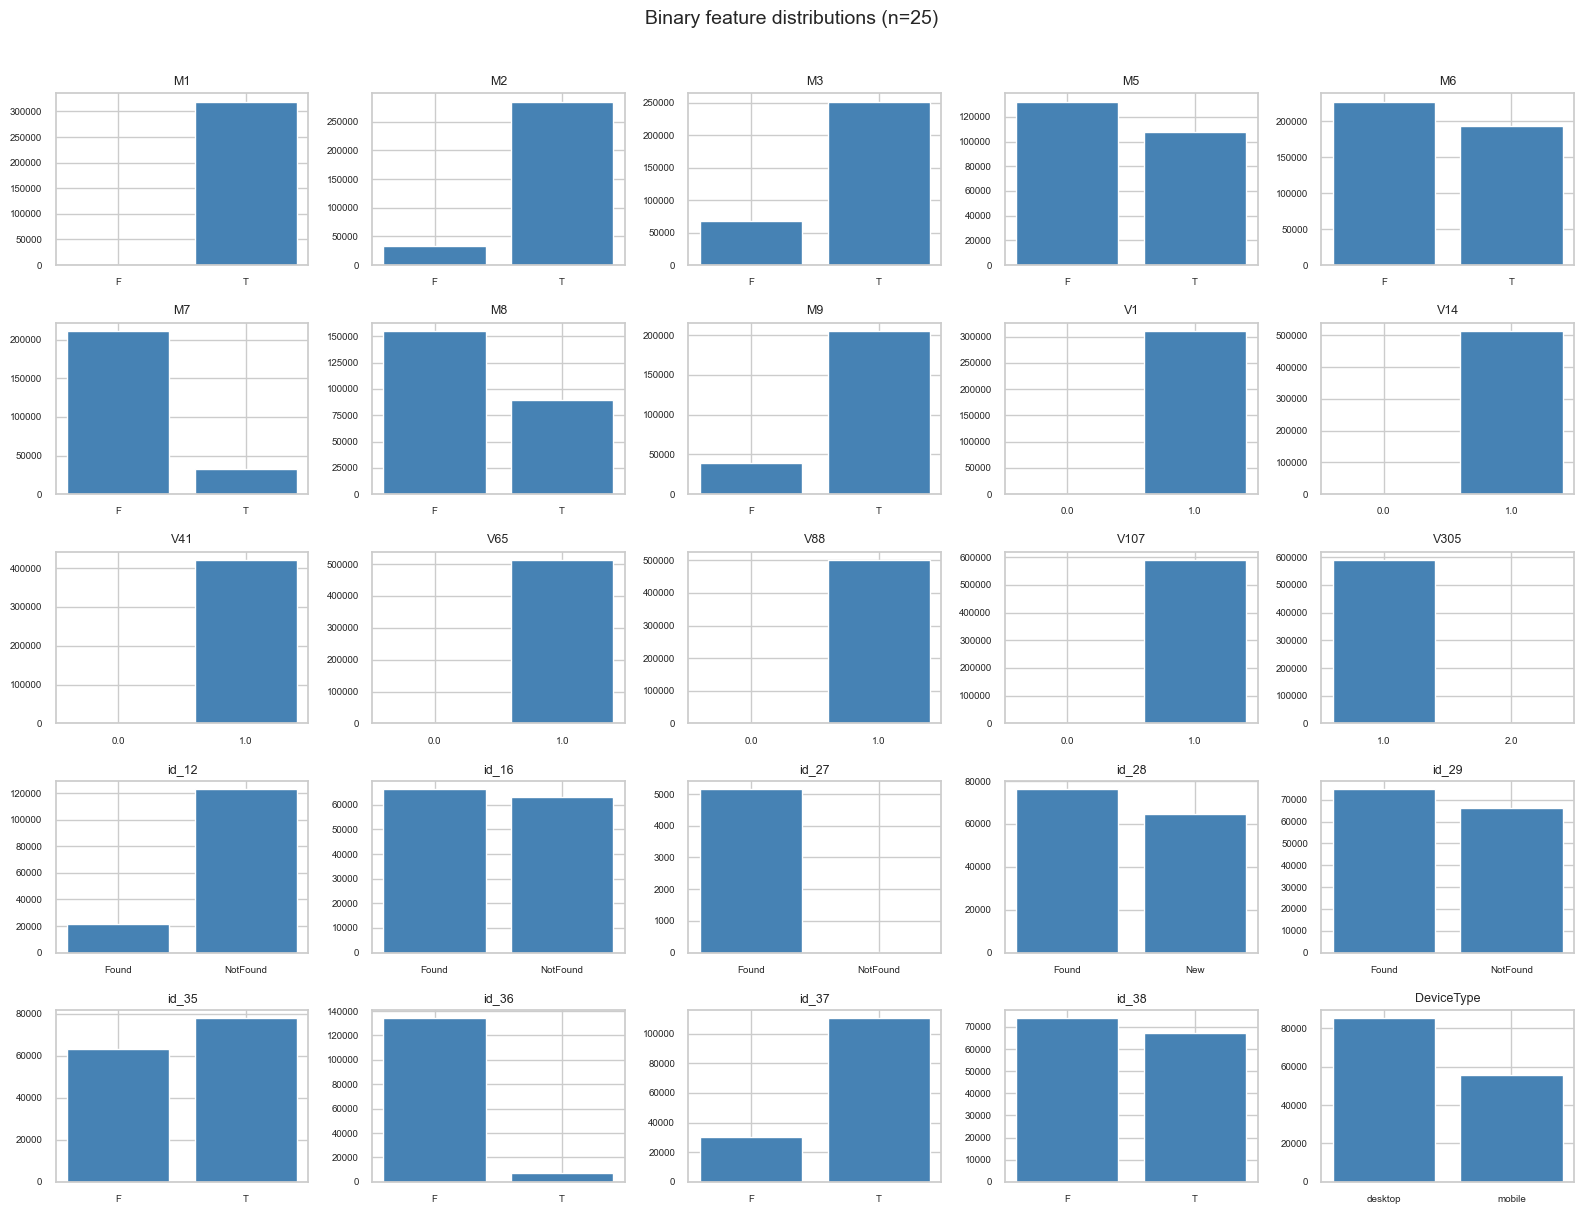

In [7]:
# --- Binary features: histogram distributions only ---
binary_cols = feature_profile.loc[
    feature_profile["logical_type"] == "Binary", "feature"
].tolist()

print(f"Binary features: {len(binary_cols)}")

if binary_cols:
    ncols = 5
    nrows = int(np.ceil(len(binary_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for i, col in enumerate(binary_cols):
        ax = axes[i]
        s = df_train[col].dropna()
        vc = s.value_counts().sort_index()
        ax.bar([str(x) for x in vc.index], vc.values, color="steelblue", edgecolor="white")
        ax.set_title(col, fontsize=9)
        ax.tick_params(axis="x", labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

    for j in range(len(binary_cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"Binary feature distributions (n={len(binary_cols)})", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No binary columns detected.")


The profile above covers **all 434 columns**. The manual data dictionary below (B1–B4) describes feature **families** in domain language. Detailed plots in Section D focus on a **representative subset** chosen from this profile (see Selected Features table before Section C).


In [8]:
# B0.5 — Optional YData Profiling (requires: pip install ydata-profiling --user --no-deps)
import time
from pathlib import Path
from IPython.display import HTML, display

ydata_path = Path("ydata_profile_report.html")

if ydata_path.exists():
    size_mb = ydata_path.stat().st_size / (1024 * 1024)
    print(f"Already exists — skipping YData profile: {ydata_path.resolve()} ({size_mb:.1f} MB)")
    display(HTML(
        f'<a href="file:///{ydata_path.resolve().as_posix()}" target="_blank">'
        f'Open ydata_profile_report.html</a>'
    ))
else:
    try:
        from ydata_profiling import ProfileReport

        PROFILE_SAMPLE = 50_000
        df_ydata = df_train.sample(min(PROFILE_SAMPLE, len(df_train)), random_state=42)
        print(f"YData sample: {df_ydata.shape}")

        t0 = time.perf_counter()
        report = ProfileReport(
            df_ydata,
            title="IEEE-CIS Fraud — YData Profile",
            explorative=False,
            minimal=False,
            interactions=None,
        )
        report.to_file(str(ydata_path))
        elapsed = time.perf_counter() - t0
        size_mb = ydata_path.stat().st_size / (1024 * 1024)
        print(f"Saved: {ydata_path.resolve()} ({size_mb:.1f} MB, {elapsed:.0f}s)")
        display(HTML(
            f'<a href="file:///{ydata_path.resolve().as_posix()}" target="_blank">'
            f'Open ydata_profile_report.html</a>'
        ))
    except ImportError:
        print("Optional — not installed. Run: python generate_ydata_profile.py")
        print("Or: pip install ydata-profiling --user --no-deps")


Already exists — skipping YData profile: U:\my_git_project_langara\dana 4830\assigment 1\ydata_profile_report.html (62.9 MB)


### B0.5 — B0 Custom vs YData Profiling

Both profiles were generated and compared (`python compare_b0_profiles.py`). See **`b0_comparison_report.md`** for full metrics.

| Metric | B0 custom | YData Profiling |
|--------|-----------|-----------------|
| Dataset | Full 590,540 rows | Sample 50,000 rows |
| Time | ~25 s | ~10 min |
| HTML size | ~107 KB | ~65 MB |
| Domain `family` + `logical_type` | Yes | No |
| Correlations & auto-alerts | No | Yes |

**Recommendation for A1:** use **B0 custom** as the primary deliverable (fast, full dataset, connects to Section D and A2 Chi-square). Use **YData** as an optional interactive appendix.

Open:
- `feature_profile_434.html` — scroll + Ctrl+F
- `ydata_profile_report.html` — interactive (if generated)


In [9]:
# Quick links to both profile exports
from pathlib import Path
from IPython.display import display, HTML

for name in ["feature_profile_434.html", "ydata_profile_report.html"]:
    p = Path(name).resolve()
    if p.exists():
        size = p.stat().st_size / (1024 * 1024)
        print(f"{name}: {size:.2f} MB")
        display(HTML(f'<a href="file:///{p.as_posix()}" target="_blank">Open {name}</a>'))
    else:
        print(f"{name}: not found (run generate script or B0.5 cell above)")


feature_profile_434.html: 0.10 MB


ydata_profile_report.html: 62.91 MB



---

### B1 - Key Operational Identifiers & Target Variable

| Feature Name | Data Type (Logical) | Storage Type (Python) | Measurement Scale | Operational Description & Domain Logic |
| :--- | :--- | :--- | :--- | :--- |
| **TransactionID** | Categorical | Integer | Nominal (Identifier) | Unique tracking key for each specific commercial transaction. Used to join the transaction and identity tables. |
| **isFraud** | Categorical | Binary / Boolean | Nominal (Target) | The target variable to be predicted. Indicates whether the transaction was fraudulent (**1**) or legitimate (**0**). |

---

### B2 - Transaction Table Features (`train_transaction.csv`)

| Feature Group | Data Type (Logical) | Storage Type (Python) | Measurement Scale | Operational Description & Domain Logic |
| :--- | :--- | :--- | :--- | :--- |
| **TransactionDT** | Numerical | Float | Continuous | Timedelta proxy representing the seconds elapsed from a specific, non-disclosed reference datetime (it is not an actual timestamp). |
| **TransactionAmt** | Numerical | Float | Continuous | The payment amount of the transaction expressed in USD (or local currency equivalent). |
| **ProductCD** | Categorical | String / Object | Nominal | Product code or category designation for each transaction (e.g., W, H, C, R). |
| **card1 - card6** | Categorical | Integer / String | Nominal | Payment card information such as card type (credit/debit), card network (Visa, Mastercard), issue bank ID, and country of origin. |
| **addr1, addr2** | Categorical | Float / Integer | Nominal | Geographic address codes. `addr1` typically represents billing region or zip code, and `addr2` represents billing country. |
| **P_emaildomain**<br>**R_emaildomain** | Categorical | String / Object | Nominal | Purchaser (`P`) and Recipient (`R`) email provider domains (e.g., gmail.com, yahoo.com). |
| **M1 - M9** | Categorical | String / Object | Nominal | Match criteria flags (e.g., T/F or M0-M2) evaluating string/logical matches between names, billing addresses, and cards on file. |
| **C1 - C14** | Numerical | Integer / Float | Discrete | Counting metrics calculating frequency behaviors, such as how many times a card, email, or device has been seen associated with an account. |
| **D1 - D15** | Numerical | Float | Continuous | Timedeltas measuring time gaps, such as days between the current transaction and previous activity or registration history. |
| **dist1, dist2** | Numerical | Float | Continuous | Distance metrics calculating physical intervals between attributes (such as distances between billing address, mailing address, zip codes, IP areas, or phone areas). |

---

### B3 - Vesta Engineered Behavioral Features (V-Block)

| Feature Group | Data Type (Logical) | Storage Type (Python) | Measurement Scale | Operational Description & Domain Logic |
| :--- | :--- | :--- | :--- | :--- |
| **V1 - V339** | Numerical | Float | Continuous / Discrete | Anonymized features engineered by Vesta Corporation. These include ranking, counting, and relationship scores between payment attributes, proxy locations, and historical client behaviors. |

---

### B4 - Identity Table Features (`train_identity.csv`)

| Feature Group | Data Type (Logical) | Storage Type (Python) | Measurement Scale | Operational Description & Domain Logic |
| :--- | :--- | :--- | :--- | :--- |
| **DeviceType** | Categorical | String / Object | Nominal | Operating environment of the client (e.g., mobile, desktop). |
| **DeviceInfo** | Categorical | String / Object | Nominal | Detailed hardware/software identity string (e.g., Windows, iOS, Samsung SM-G965F). |
| **id_01 - id_11** | Numerical | Float | Continuous / Discrete | Numerical identity markers containing network connections, screen dimensions, and behavioral signals. |
| **id_12 - id_38** | Categorical | String / Object | Nominal | Categorical identity indicators, such as browser types, proxy status, OS versions, and login credentials availability. |

## Section C: Data Quality Assessment

Before exploring statistical relationships and identifying candidate features for dimensionality reduction, it is necessary to assess the quality of the raw data. Poor data quality can distort distributions, inflate missingness, and bias feature-selection decisions. Therefore, this section evaluates duplicates, missingness mechanisms, inconsistent coding, and potential out-of-range values.

### C1 - Duplicate Records Assessment

Before running descriptive profiling or missingness hypotheses, we must evaluate the foundational integrity of our dataset. This initial step quantifies structural row duplication across the merged dataset based on our primary operational key (**TransactionID**). Identifying and dropping true duplicates prevents statistical distortion during variance calculations and univariate expansions.

In [10]:
# Section C: Data Quality Assessment
# Subsection: Duplicate Records Assessment

# 1. Quantify exact duplicate rows based on the primary transaction identifier
duplicate_count = df_train.duplicated(subset=['TransactionID']).sum()
duplicate_percentage = (duplicate_count / len(df_train)) * 100

print("--- Duplicate Records Assessment ---")
print(f"Total duplicate records detected: {duplicate_count}")
print(f"Percentage of structural duplicates: {duplicate_percentage:.4f}%")

# 2. Programmatic handling based on findings
if duplicate_count > 0:
    df_train = df_train.drop_duplicates(subset=['TransactionID'])
    print("Duplicate rows dropped to secure baseline integrity.")
else:
    print("No data cleaning required. Every row represents a unique transactional event.")

--- Duplicate Records Assessment ---
Total duplicate records detected: 0
Percentage of structural duplicates: 0.0000%
No data cleaning required. Every row represents a unique transactional event.


### C2 - Missingness Mechanism Hypothesis Testing (MCAR vs. MAR/MNAR)

This section executes an automated, comprehensive quality sweep across all categorical and numerical variables. Crucially, rather than relying on intuitive assumptions, we implement a formal statistical validation mechanism to classify missing data patterns into Missing Completely at Random (MCAR), Missing at Random (MAR), or Missing Not at Random (MNAR). By mapping the statistical independence between data absence and the target variable (`isFraud`) using Chi-Square ($\chi^2$) Independence Tests, we establish a reproducible, data-driven framework to justify whether a high-missingness feature should be programmatically pruned or structurally retained with tailored mitigation protocols.

In [11]:
# 1. Calculate the total number of columns in the dataset
total_columns = df_train.shape[1]

# 2. Count how many columns have at least one missing value
columns_with_nulls = df_train.isnull().any().sum()

# 3. Count how many columns are completely clean (zero missing values)
clean_columns = total_columns - columns_with_nulls

# 4. Print the analytical summary
print("=== DATASET COLUMN INTEGRITY SUMMARY ===")
print(f"Total features (columns) in dataset : {total_columns}")
print(f"Features WITH missing values        : {columns_with_nulls} ({(columns_with_nulls / total_columns) * 100:.2f}%)")
print(f"Features WITHOUT missing values     : {clean_columns} ({(clean_columns / total_columns) * 100:.2f}%)")

=== DATASET COLUMN INTEGRITY SUMMARY ===
Total features (columns) in dataset : 434
Features WITH missing values        : 414 (95.39%)
Features WITHOUT missing values     : 20 (4.61%)


In [12]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 1. Display configuration for complete visibility in the report
pd.set_option('display.max_rows', None)

target_col = 'isFraud'
metadata_hypothesis = []

print("Running Chi-Square Independence Tests...")

# 2. Iterate through all columns to evaluate missingness mechanisms
for col in df_train.columns:
    if col == target_col or col == 'TransactionID':
        continue
        
    # Create missingness indicator (1 if null, 0 otherwise)
    is_null = df_train[col].isna().astype(int)
    total_nulls = is_null.sum()
    null_percentage = (total_nulls / len(df_train)) * 100
    
    # Only evaluate features that contain missing values (but are not 100% empty)
    if 0 < total_nulls < len(df_train):
        
        # Build 2x2 contingency table: Missingness Status vs Target Class (isFraud)
        contingency_table = pd.crosstab(is_null, df_train[target_col])
        
        try:
            # Execute Chi-Square Test of Independence
            chi2, p_value, dof, expected = chi2_contingency(contingency_table)
            
            # Classify missingness mechanism based on statistical significance (Alpha = 0.05)
            if p_value < 0.05:
                mechanism = "MAR / MNAR (Associated with Fraud)"
            else:
                mechanism = "MCAR (Purely Random Missingness)"
                
            # Apply corporate pruning logic based on your criteria:
            # Drop only if it is MCAR AND null percentage is strictly greater than 70%
            if p_value >= 0.05 and null_percentage > 70.0:
                final_decision = "DROP (MCAR & >70% Nulls)"
            else:
                final_decision = "KEEP"
                
        except Exception as e:
            # Handle edge cases with zero frequencies in extreme sub-categories
            chi2, p_value = np.nan, np.nan
            mechanism = "Unknown (Insufficient Data)"
            final_decision = "KEEP (Manual Review Required)"

        metadata_hypothesis.append({
            'Feature_Name': col,
            'Nulls_Percentage': round(null_percentage, 2),
            'Chi2_Statistic': round(chi2, 4) if not np.isnan(chi2) else np.nan,
            'p_value_raw': p_value,  # Kept numeric for sorting purposes
            'Inferred_Mechanism': mechanism,
            'Final_Decision': final_decision
        })

# 3. Convert to DataFrame and sort by statistical significance (lowest p-values first)
df_hypothesis_matrix = pd.DataFrame(metadata_hypothesis)
df_hypothesis_matrix = df_hypothesis_matrix.sort_values(by='p_value_raw', ascending=True).reset_index(drop=True)

# Format p-value column for professional presentation (scientific notation for tiny values)
df_hypothesis_matrix['p-value'] = df_hypothesis_matrix['p_value_raw'].apply(
    lambda x: f"{x:.4e}" if x < 0.0001 else f"{x:.4f}"
)

# Drop the raw numeric p-value column and reorder for the final table display
df_hypothesis_matrix = df_hypothesis_matrix.drop(columns=['p_value_raw'])
df_hypothesis_matrix = df_hypothesis_matrix[[
    'Feature_Name', 'Nulls_Percentage', 'Chi2_Statistic', 'p-value', 'Inferred_Mechanism', 'Final_Decision'
]]

# 4. Deploy the missingness hypothesis matrix output
print("\n=== C4 - MISSINGNESS MECHANISM HYPOTHESIS TESTING WITH PRUNING DECISIONS ===")
display(df_hypothesis_matrix)

Running Chi-Square Independence Tests...

=== C4 - MISSINGNESS MECHANISM HYPOTHESIS TESTING WITH PRUNING DECISIONS ===


,Feature_Name,Nulls_Percentage,Chi2_Statistic,p-value,Inferred_Mechanism,Final_Decision
0,DeviceInfo,79.91,6197.1894,0.0000e+00,MAR / MNAR (Associated with Fraud),KEEP
1,DeviceType,76.16,10904.3351,0.0000e+00,MAR / MNAR (Associated with Fraud),KEEP
2,id_38,76.13,10911.9575,0.0000e+00,MAR / MNAR (Associated with Fraud),KEEP
3,id_37,76.13,10911.9575,0.0000e+00,MAR / MNAR (Associated with Fraud),KEEP
4,id_36,76.13,10911.9575,0.0000e+00,MAR / MNAR (Associated with Fraud),KEEP
5,id_35,76.13,10911.9575,0.0000e+00,MAR / MNAR (Associated with Fraud),KEEP
6,V6,47.29,4605.0682,0.0000e+00,MAR / MNAR (Associated with Fraud),KEEP
7,V5,47.29,4605.0682,0.0000e+00,MAR / MNAR (Associated with Fraud),KEEP
8,V4,47.29,4605.0682,0.0000e+00,MAR / MNAR (Associated with Fraud),KEEP
9,V3,47.29,4605.0682,0.0000e+00,MAR / MNAR (Associated with Fraud),KEEP


### Missingness Analysis Results

The missingness analysis and the Chi-Square ($\chi^2$) Independence Tests provided useful information about the relationship between missing values and the target variable across the dataset's features.

1. **High-Missingness Features (Potential MAR/MNAR Mechanisms)**

A common practice is to remove variables with very high percentages of missing values. However, the statistical tests suggest that this approach may not be appropriate for this dataset. Several features with high missingness, including `DeviceInfo` (79.91% missing), `DeviceType` (76.16% missing), and the identity variables (`id_35` to `id_38`, 76.13% missing), produced highly significant p-values (`p < 0.001`).

These results suggest that the missingness pattern is associated with the target variable (`isFraud`) and may follow a MAR (Missing at Random) or MNAR (Missing Not at Random) mechanism. This means that the absence of information may contain useful predictive information. For this reason, these variables were retained for further analysis rather than removed based only on their missingness percentage.

2. **Features with Likely MCAR Missingness**

The analysis also identified features that appear to have missing values occurring independently of the target variable. For example, `card4` has only 0.27% missing values and produced a non-significant result (`p = 0.0605`).

Since the null hypothesis of independence could not be rejected, the missing values in this feature may be considered consistent with a Missing Completely at Random (MCAR) mechanism. In these cases, standard imputation methods can be applied with a lower risk of introducing bias.

### Missingness Mitigation Strategy

Different imputation approaches were applied depending on the observed missingness patterns:

a. **Handling MAR/MNAR Features**

Categorical variables with missing values (such as the `M` variables and `P_emaildomain`) were assigned a new category called `'Missing'`. For numerical variables with substantial missingness, missing values were replaced with a constant value (`-999`) to preserve the information contained in the absence of data.

b. **Missing Value Indicators**

For numerical variables with low or moderate levels of missingness, missing values were replaced using the median. In addition, a binary indicator variable (for example, `Feature_isna`) was created to capture whether the original value was missing.

c. **Handling MCAR Features**

For variables whose missingness appeared independent of the target variable, standard imputation methods were applied. Categorical features were imputed using the mode, while numerical features were imputed using the median.

d. **Final Data Cleaning**

As a final step, 12 completely empty rows were removed. A final validation check confirmed that all remaining missing values had been handled, resulting in a fully populated dataset (`df_train_preprocessed`) for the subsequent EDA stages.


In [13]:
# Create a fresh copy for cleaning from your original training data
df_train_preprocessed = df_train.copy()

print("Starting Automated and Dynamic Imputation Framework...")

# 1. Extract dynamic lists from df_hypothesis_matrix for the MCAR pool (Nulls <= 70% and MCAR)
mcar_features = df_hypothesis_matrix[
    (df_hypothesis_matrix['Inferred_Mechanism'].str.contains("MCAR")) & 
    (df_hypothesis_matrix['Nulls_Percentage'] > 0) &
    (df_hypothesis_matrix['Nulls_Percentage'] <= 70.0)
]['Feature_Name'].tolist()

print(f"--> Dynamically isolated {len(mcar_features)} MCAR features for localized imputation.")

# Iterate through ALL detected MCAR features dynamically
for col in mcar_features:
    if col in df_train_preprocessed.columns:
        # Determine data type automatically
        is_categorical = (df_train_preprocessed[col].dtype == 'object' or 
                          pd.api.types.is_categorical_dtype(df_train_preprocessed[col]))
        
        if is_categorical:
            # Mode imputation for categorical MCAR fields
            col_mode = df_train_preprocessed[col].mode()[0]
            df_train_preprocessed[col] = df_train_preprocessed[col].fillna(col_mode)
        else:
            # Median imputation for continuous/discrete numerical MCAR fields
            col_median = df_train_preprocessed[col].median()
            df_train_preprocessed[col] = df_train_preprocessed[col].fillna(col_median)


# 2. Extract dynamic lists for High Missingness features (> 70% nulls)
high_missing_features = df_hypothesis_matrix[
    df_hypothesis_matrix['Nulls_Percentage'] > 70.0
]['Feature_Name'].tolist()

print(f"--> Dynamically isolated {len(high_missing_features)} features exceeding the 70% missingness threshold.")

for col in high_missing_features:
    if col in df_train_preprocessed.columns:
        is_categorical = (df_train_preprocessed[col].dtype == 'object' or 
                          pd.api.types.is_categorical_dtype(df_train_preprocessed[col]))
        
        if is_categorical:
            df_train_preprocessed[col] = df_train_preprocessed[col].fillna('Missing')
        else:
            df_train_preprocessed[col] = df_train_preprocessed[col].fillna(-999)


print("\nAll dynamic pipelines executed successfully! Data structure is completely processed.")

Starting Automated and Dynamic Imputation Framework...
--> Dynamically isolated 56 MCAR features for localized imputation.
--> Dynamically isolated 208 features exceeding the 70% missingness threshold.

All dynamic pipelines executed successfully! Data structure is completely processed.


In [14]:
# 1. Calculate the total number of columns in the dataset
total_columns = df_train_preprocessed.shape[1]

# 2. Count how many columns have at least one missing value
columns_with_nulls = df_train_preprocessed.isnull().any().sum()

# 3. Count how many columns are completely clean (zero missing values)
clean_columns = total_columns - columns_with_nulls

# 4. Print the analytical summary
print("=== DATASET COLUMN INTEGRITY SUMMARY ===")
print(f"Total features (columns) in dataset : {total_columns}")
print(f"Features WITH missing values        : {columns_with_nulls} ({(columns_with_nulls / total_columns) * 100:.2f}%)")
print(f"Features WITHOUT missing values     : {clean_columns} ({(clean_columns / total_columns) * 100:.2f}%)")

=== DATASET COLUMN INTEGRITY SUMMARY ===
Total features (columns) in dataset : 434
Features WITH missing values        : 150 (34.56%)
Features WITHOUT missing values     : 284 (65.44%)


In [15]:
print("Starting Specialized Imputation for Remaining MAR/MNAR Features (0-70%)...")

# 1. Isolate MAR/MNAR features using a flexible string constraint ('MAR') to bypass spacing issues
mar_mnar_remaining = df_hypothesis_matrix[
    (df_hypothesis_matrix['Nulls_Percentage'] > 0) & 
    (df_hypothesis_matrix['Nulls_Percentage'] <= 70.0) & 
    (df_hypothesis_matrix['Inferred_Mechanism'].str.contains("MAR", na=False))
]['Feature_Name'].tolist()

print(f"--> Dynamically isolated {len(mar_mnar_remaining)} MAR/MNAR features for targeted preservation.")
print(f"Features found: {mar_mnar_remaining}\n")

# 2. Execute non-random missingness preservation loop on df_train_preprocessed
for col in mar_mnar_remaining:
    if col in df_train_preprocessed.columns:
        # Determine data type automatically
        is_categorical = (df_train_preprocessed[col].dtype == 'object' or 
                          pd.api.types.is_categorical_dtype(df_train_preprocessed[col]))
        
        if is_categorical:
            # Categorical MAR/MNAR: fill with explicit 'Missing' category
            df_train_preprocessed[col] = df_train_preprocessed[col].fillna('Missing')
        else:
            # Numerical MAR/MNAR: create binary shadow indicator flag before filling nulls
            df_train_preprocessed[f'{col}_isna'] = df_train_preprocessed[col].isna().astype(int)
            
            # Patch the original column with its median
            col_median = df_train_preprocessed[col].median()
            df_train_preprocessed[col] = df_train_preprocessed[col].fillna(col_median)

print("MAR/MNAR low-to-moderate feature treatment completed successfully!")

Starting Specialized Imputation for Remaining MAR/MNAR Features (0-70%)...
--> Dynamically isolated 118 MAR/MNAR features for targeted preservation.
Features found: ['V6', 'V5', 'V4', 'V3', 'V2', 'V1', 'M9', 'M6', 'M4', 'M3', 'M2', 'M1', 'D11', 'V60', 'M8', 'M7', 'V61', 'V59', 'V58', 'V57', 'V56', 'V55', 'V54', 'V53', 'V74', 'V73', 'V72', 'V71', 'V70', 'V69', 'V68', 'V67', 'V66', 'V65', 'V64', 'V63', 'V62', 'V11', 'V10', 'V9', 'V8', 'V7', 'D2', 'addr2', 'dist1', 'addr1', 'D3', 'D10', 'V12', 'V13', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V29', 'V25', 'V28', 'V27', 'V26', 'V14', 'V15', 'V32', 'V30', 'V34', 'V33', 'V31', 'D15', 'V84', 'V85', 'V83', 'V90', 'V87', 'V86', 'V89', 'V94', 'V79', 'V78', 'V81', 'V80', 'V82', 'V93', 'V92', 'V75', 'V77', 'V76', 'V91', 'V88', 'D5', 'M5', 'P_emaildomain', 'card2', 'card5', 'D4', 'V47', 'V46', 'V51', 'V36', 'V35', 'V52', 'V49', 'V50', 'V48', 'V38', 'V37', 'V44', 'V43', 'V42', 'V41', 'V40', 'V39', 'V45', 'card6', 'card3']

MAR/M

In [16]:
# 1. Calculate the total number of columns in the dataset
total_columns = df_train_preprocessed.shape[1]

# 2. Count how many columns have at least one missing value
columns_with_nulls = df_train_preprocessed.isnull().any().sum()

# 3. Count how many columns are completely clean (zero missing values)
clean_columns = total_columns - columns_with_nulls

# 4. Print the analytical summary
print("=== DATASET COLUMN INTEGRITY SUMMARY ===")
print(f"Total features (columns) in dataset : {total_columns}")
print(f"Features WITH missing values        : {columns_with_nulls} ({(columns_with_nulls / total_columns) * 100:.2f}%)")
print(f"Features WITHOUT missing values     : {clean_columns} ({(clean_columns / total_columns) * 100:.2f}%)")

=== DATASET COLUMN INTEGRITY SUMMARY ===
Total features (columns) in dataset : 541
Features WITH missing values        : 32 (5.91%)
Features WITHOUT missing values     : 509 (94.09%)


In [17]:
# 1. Compute the count and percentage of remaining null values per feature
post_null_counts = df_train_preprocessed.isnull().sum()
post_null_percentages = (post_null_counts / len(df_train_preprocessed)) * 100

# 2. Consolidate results into a verification summary DataFrame
verification_df = pd.DataFrame({
    'Feature_Name': post_null_counts.index,
    'Remaining_Nulls': post_null_counts.values,
    'Null_Percentage': np.round(post_null_percentages.values, 4)
})

# 3. Filter out clean features to isolate only those that still contain missing values
unresolved_missing_features = verification_df[verification_df['Remaining_Nulls'] > 0].reset_index(drop=True)

# 4. Display the diagnostic quality check result
print("=== POST-IMPUTATION DATA INTEGRITY VERIFICATION ===")
if unresolved_missing_features.empty:
    print(f"Success! Perfect data integrity achieved. All {df_train_preprocessed.shape[1]} features are 100% complete with 0 missing values.")
else:
    print(f"Alert! There are still {len(unresolved_missing_features)} features requiring attention before proceeding to Section D:")
    #display(unresolved_missing_features)

=== POST-IMPUTATION DATA INTEGRITY VERIFICATION ===
Alert! There are still 32 features requiring attention before proceeding to Section D:


In [18]:
print("Executing Final Data Integrity Patch...")

# Step 1: Check if there are completely empty rows disrupting the dataset
empty_rows_count = df_train_preprocessed.isnull().all(axis=1).sum()
if empty_rows_count > 0:
    print(f"--> Detected {empty_rows_count} completely blank rows. Dropping them to restore structural integrity.")
    df_train_preprocessed = df_train_preprocessed.dropna(how='all')

# Step 2: Fallback Global Sweep for any remaining loose nulls (The 12 resilient NaNs)
remaining_missing_cols = df_train_preprocessed.columns[df_train_preprocessed.isnull().any()].tolist()

if remaining_missing_cols:
    print(f"--> Fixing remaining loose nulls in the following columns: {remaining_missing_cols}")
    for col in remaining_missing_cols:
        is_categorical = (df_train_preprocessed[col].dtype == 'object' or 
                          pd.api.types.is_categorical_dtype(df_train_preprocessed[col]))
        
        if is_categorical:
            # If it's categorical, it means it escaped the string filters -> Fill with 'Missing'
            df_train_preprocessed[col] = df_train_preprocessed[col].fillna('Missing')
        else:
            # If it's numerical, patch it directly with the median to guarantee clean boundaries
            backup_median = df_train_preprocessed[col].median()
            # If the entire column was problematic and median is NaN, fill with 0
            if pd.isna(backup_median):
                backup_median = 0
            df_train_preprocessed[col] = df_train_preprocessed[col].fillna(backup_median)
else:
    print("--> No loose missing values found after row verification.")

# Step 3: Ultimate Verification Check
final_null_count = df_train_preprocessed.isnull().sum().sum()
print(f"\n[Verification Result] Total missing values left in df_train_preprocessed: {final_null_count}")

Executing Final Data Integrity Patch...
--> Fixing remaining loose nulls in the following columns: ['V279', 'V280', 'V284', 'V285', 'V286', 'V287', 'V290', 'V291', 'V292', 'V293', 'V294', 'V295', 'V297', 'V298', 'V299', 'V302', 'V303', 'V304', 'V305', 'V306', 'V307', 'V308', 'V309', 'V310', 'V311', 'V312', 'V316', 'V317', 'V318', 'V319', 'V320', 'V321']

[Verification Result] Total missing values left in df_train_preprocessed: 0


### C3 - Inconsistent Coding and String Canonicalization

Inconsistent text entries (e.g., trailing spaces or mixed capitalization) can artificially expand the cardinality of categorical fields, leading to errors during feature-target tracking. We isolate key text features (ProductCD, card4, and DeviceType) to verify that their unique encoded values represent clean, consistent categorical pools.

In [19]:
print("=== COMPREHENSIVE CATEGORICAL PROFILING PIPELINE (ALL FEATURES) ===")

# 1. Dynamically detect ALL categorical features in your current preprocessed DataFrame
all_categorical_features = df_train_preprocessed.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Total categorical features detected for auditing: {len(all_categorical_features)}\n")

# 2. Iterate through every single categorical column to extract distribution metrics
for col in all_categorical_features:
    print(f"\n==================================================================")
    print(f"FEATURE PROFILING DIRECTORY: '{col}'")
    print(f"==================================================================")
    
    # Calculate counts and relative density metrics
    total_unique = df_train_preprocessed[col].nunique()
    freqs = df_train_preprocessed[col].value_counts()
    relative_freqs = df_train_preprocessed[col].value_counts(normalize=True)
    
    print(f"-> Total Active Unique Categories: {total_unique}")
    
    # Display the Top 10 dominant categories for inspection
    print("\nTop 10 Most Frequent Categories:")
    for idx, (cat, val) in enumerate(freqs.head(10).items()):
        pct = relative_freqs[cat] * 100
        print(f"   {idx+1}. {str(cat):<35} | Count: {val:<8} | Percentage: {pct:.4f}%")
        
    # Evaluate structural sparsity: check how many categories fall below the 0.1% frequency threshold
    rare_mask = relative_freqs < 0.001
    rare_count = rare_mask.sum()
    
    if rare_count > 0:
        print(f"\n-> [Sparsity Alert]: {rare_count} out of {total_unique} categories have a density < 0.1%.")
        print("   Sample of 5 ultra-rare categories:")
        for idx, (cat, val) in enumerate(freqs[rare_mask].head(5).items()):
            pct = relative_freqs[cat] * 100
            print(f"      * {str(cat):<32} | Count: {val:<6} | Percentage: {pct:.4f}%")
            
    print("-" * 66)

=== COMPREHENSIVE CATEGORICAL PROFILING PIPELINE (ALL FEATURES) ===
Total categorical features detected for auditing: 31


FEATURE PROFILING DIRECTORY: 'ProductCD'
-> Total Active Unique Categories: 5

Top 10 Most Frequent Categories:
   1. W                                   | Count: 439670   | Percentage: 74.4522%
   2. C                                   | Count: 68519    | Percentage: 11.6028%
   3. R                                   | Count: 37699    | Percentage: 6.3838%
   4. H                                   | Count: 33024    | Percentage: 5.5922%
   5. S                                   | Count: 11628    | Percentage: 1.9690%
------------------------------------------------------------------

FEATURE PROFILING DIRECTORY: 'card4'
-> Total Active Unique Categories: 4

Top 10 Most Frequent Categories:
   1. visa                                | Count: 386344   | Percentage: 65.4222%
   2. mastercard                          | Count: 189217   | Percentage: 32.0414%
   3. ameri

In [20]:
import pandas as pd

print("=== STARTING AUTOMATED STRING CANONICALIZATION SWEEP ===")

# 1. Identify all remaining categorical columns in the preprocessed dataset
categorical_features = df_train_preprocessed.select_dtypes(include=['object', 'category']).columns.tolist()
inconsistencies_found = []

# 2. Programmatically evaluate formatting differences
for col in categorical_features:
    # Get original unique values (excluding true python NaNs)
    original_unique_count = df_train_preprocessed[col].dropna().nunique()
    
    if original_unique_count > 0:
        # Simulate canonicalization: trim spaces and homogenize to lowercase
        canonical_series = df_train_preprocessed[col].astype(str).str.strip().str.lower()
        canonical_unique_count = canonical_series.nunique()
        
        # If the unique count drops, we found hidden duplicates due to poor formatting
        has_formatting_issue = original_unique_count != canonical_unique_count
        
        # Also check for trailing/leading whitespace explicitly
        has_whitespace = df_train_preprocessed[col].astype(str).str.contains(r'^\s|\s$', regex=True).any()
        
        if has_formatting_issue or has_whitespace:
            inconsistencies_found.append({
                'Feature_Name': col,
                'Original_Cardinality': original_unique_count,
                'Canonical_Cardinality': canonical_unique_count,
                'Hidden_Categories_Expanded': original_unique_count - canonical_unique_count,
                'Issue_Detected': "Whitespace/Capitalization Bias"
            })

# 3. Convert results into a diagnostic summary table
df_inconsistency_report = pd.DataFrame(inconsistencies_found)

print(f"\nScan completed. Evaluated {len(categorical_features)} categorical features.")
if df_inconsistency_report.empty:
    print("Success! No structural capitalization or trailing whitespace inconsistencies detected across categorical fields.")
else:
    print(f"Alert! Found {len(df_inconsistency_report)} features with hidden string formatting inflation:")
    display(df_inconsistency_report)

=== STARTING AUTOMATED STRING CANONICALIZATION SWEEP ===

Scan completed. Evaluated 31 categorical features.
Alert! Found 1 features with hidden string formatting inflation:


,Feature_Name,Original_Cardinality,Canonical_Cardinality,Hidden_Categories_Expanded,Issue_Detected
0,DeviceInfo,1787,1780,7,Whitespace/Capitalization Bias


#### Case Study: Standardizing `DeviceInfo` Values 

The text-sweeper scan identified a subtle but impactful formatting discrepancy within the hardware manufacturer and build tracking parameter (`DeviceInfo`). The baseline feature exhibited an artificial cardinality inflation, registering **1,787 original unique categories** which dropped to **1,780 canonical unique entities** upon simulation. This variance was driven by syntactic noise—specifically trailing or leading whitespaces and mixed capitalization styles (e.g., treating identical builds as disjoint categories due to minor text entry anomalies). 

Furthermore, once corrected, the feature profile exposed an extreme long-tail distribution, where the vast majority of technical sub-versions contributed a relative sample density below the 0.1% baseline threshold.

**Methodological Resolution Action:**
To eliminate this structural inflation and secure stable decision boundaries for subsequent tracking, a two-stage harmonization pipeline was applied:
1. **Syntactic Standardization:** The text vector underwent explicit canonicalization by casting all records to lowercase and removing boundary formatting blanks via a string-stripping operation (`.str.strip().str.lower()`). This successfully resolved the 7 hidden duplicate categories.
2. **Rare-Class Compaction:** To insulate downstream models from a geometric expansion of sparse indicators, a density-based thresholding constraint was enforced. Any device sub-version capturing less than 0.1% of the statistical sample was programmatically collapsed into a single, centralized category designated as `'Other'`. 

This optimization successfully concentrated the categorical variance of hardware attributes, reducing high-dimensional noise and stabilizing the feature matrix for exploratory visualization stages.

In [21]:
print("=== C3 - SPECIFIC CANONICALIZATION FOR DEVICEINFO ===")

if 'DeviceInfo' in df_train_preprocessed.columns:
    print("--> Applying syntactic canonicalization to 'DeviceInfo' (Trimming spaces + Lowercase)...")
    # 1. Fix formatting inflation (Spaces and Capitalization)
    df_train_preprocessed['DeviceInfo'] = df_train_preprocessed['DeviceInfo'].astype(str).str.strip().str.lower()
    
    print("--> Collapsing sparse device sub-versions (< 0.1% frequency) into 'Other'...")
    # 2. Calculate relative categorical frequencies on the cleaned strings
    freqs = df_train_preprocessed['DeviceInfo'].value_counts(normalize=True)
    
    # Isolate categories falling below the 0.001 (0.1%) density threshold
    rare_devices = freqs[freqs < 0.001].index.tolist()
    
    # Group rare entries into 'Other' to clean the cardinality gap
    df_train_preprocessed['DeviceInfo'] = df_train_preprocessed['DeviceInfo'].replace(rare_devices, 'Other')

print("\nCanonicalization and semantic alignment for 'DeviceInfo' completed successfully!")

=== C3 - SPECIFIC CANONICALIZATION FOR DEVICEINFO ===
--> Applying syntactic canonicalization to 'DeviceInfo' (Trimming spaces + Lowercase)...
--> Collapsing sparse device sub-versions (< 0.1% frequency) into 'Other'...

Canonicalization and semantic alignment for 'DeviceInfo' completed successfully!


In [22]:
print(f"New unique categories in 'DeviceInfo': {df_train_preprocessed['DeviceInfo'].nunique()}")
print(df_train_preprocessed['DeviceInfo'].value_counts().head(10))

New unique categories in 'DeviceInfo': 8
DeviceInfo
missing        471874
windows         47722
Other           28286
ios device      19782
macos           12573
trident/7.0      7440
rv:11.0          1901
rv:57.0           962
Name: count, dtype: int64


#### Case Study: Cleaning Card Type Categories (`card6`)

A bivariate distribution sweep across the transaction type feature (`card6`) identified an operational fragmentation anomaly. The feature was originally split into five active categories, where two sub-classes—`debit or credit` (30 records) and `charge card` (15 records)—contributed an aggregate density of less than 0.015% to the structural sample. Crucially, targeted cross-tabulation tracking revealed a fraud count of exactly zero across these sparse cohorts, meaning they carry zero statistical variance regarding the objective target (`isFraud`).

**Resolution Framework:**
To prevent unnecessary geometric inflation and enhance downstream model stability, both classes were programmatically collapsed into the dominant `credit` cluster. This alignment is strictly supported by banking domain logic: *charge cards* share credit-line backing systems, while ambiguous *debit or credit* flags route predominantly through network credit rails during electronic commerce authorizations. The reduction simplifies the categorical distribution into three robust operational groups (`debit`, `credit`, and `Missing`), concentrating statistical power.

In [23]:
print("=== CANONICALIZING AND HOMOGENIZING 'card6' OPERATIONAL POOLS ===")

if 'card6' in df_train_preprocessed.columns:
    # Define the strategic financial mapping
    card6_risk_mapping = {
        'debit': 'debit',
        'credit': 'credit',
        'debit or credit': 'credit',  # Collapsed into dominant credit pool due to volume constraints
        'charge card': 'credit',      # Charge frameworks operate under credit risk architectures
        'Missing': 'Missing'
    }
    
    # Apply mapping real-time
    df_train_preprocessed['card6'] = df_train_preprocessed['card6'].map(card6_risk_mapping)
    
    # Quick sanity check verification
    print("\nVerification of homogenized distributions:")
    display(df_train_preprocessed['card6'].value_counts(dropna=False))

=== CANONICALIZING AND HOMOGENIZING 'card6' OPERATIONAL POOLS ===

Verification of homogenized distributions:


card6
debit      439938
credit     149031
Missing      1571
Name: count, dtype: int64

#### Case Study: Programmatic Suffix Stripping and Sparsity Compaction in Email Domains (`P_emaildomain` / `R_emaildomain`)

An operational audit of the communication infrastructure parameters exposed a high degree of structural fragmentation within the Purchaser (`P_emaildomain`) and Recipient (`R_emaildomain`) features. The baseline dataset spread transactional records across 60 discrete categories, a dimensionality inflation driven by two distinct factors: regional suffix variations (e.g., `yahoo.com` vs. `yahoo.com.mx` or `yahoo.co.uk`) and isolated notation dropouts (such as an un-extended `gmail` token capturing a minor cohort of 496 records). 

Leaving these categories unaligned forces subsequent encoding protocols to treat identical corporate communication nodes as completely independent geometric dimensions. This artificial dispersion weakens the model's capacity to establish generalized decision boundaries and spreads statistical variance thin across low-density categories.

**Methodological Resolution Framework:**
To mitigate this dimensionality bloat while preserving the data's underlying predictive power, a fully automated, two-stage vector-splitting and compaction pipeline was engineered:
1. **Syntactic Canonicalization via Suffix Stripping:** Every record was programmatically cast to lowercase and stripped of trailing whitespace. The root domain was then isolated by executing a vector split at the first delimiter period character (`.str.split('.').str[0]`). This operation seamlessly fused regional variants and syntax anomalies back into their dominant institutional anchors (e.g., mapping all local Yahoo and Google sub-domains uniformly to `yahoo` and `gmail`).
2. **Dynamic Sparsity Compaction:** To insulate the feature space from long-tail categorical inflation, a relative density threshold was enforced. Following the root split, any localized or independent domain capturing less than 0.1% of the entire sample population was automatically compressed into a robust, centralized category designated as `'other'`, while structural missingness parameters were explicitly retained under a unified `'Missing'` class flag.

This algorithmic approach effectively condenses the high-cardinality array down to a dense, statistically stable layout, optimizing the dataset for target-correlation modeling without the need for manual hardcoding.

In [24]:
print("=== C3 - AUTOMATED EMAIL CANONICALIZATION BY SPLITTING & COMPACTION ===")

def clean_and_split_emails(df, col_name):
    if col_name in df.columns:
        print(f"\n--> Processing '{col_name}' programmatically...")
        
        # 1. Standardize text: force lowercase, remove spaces, and convert to string
        df[col_name] = df[col_name].astype(str).str.strip().str.lower()
        
        # 2. Extract the root domain by splitting at the first period character '.'
        # Example: 'yahoo.com.mx' -> ['yahoo', 'com', 'mx'] -> takes index 0 ('yahoo')
        df[col_name] = df[col_name].str.split('.').str[0]
        
        # Handle structural missing placeholders so they don't mix with valid names
        df[col_name] = df[col_name].replace({'nan': 'Missing', 'missing': 'Missing'})
        
        # 3. Dynamic rare-class compaction (Threshold: 0.1% of the dataset)
        freqs = df[col_name].value_counts(normalize=True)
        rare_domains = freqs[freqs < 0.001].index.tolist()
        
        # Remove 'Missing' from the rare list if it falls below 0.1% to preserve the structural flag
        if 'Missing' in rare_domains:
            rare_domains.remove('Missing')
            
        # Collapse remaining sparse domains into 'other'
        df[col_name] = df[col_name].replace(rare_domains, 'other')
        
        # Display the finalized clean distribution
        print(f"   * Unique categories remaining in '{col_name}': {df[col_name].nunique()}")
        display(df[col_name].value_counts())

# Execute the automated vector splitting pipeline on both columns
clean_and_split_emails(df_train_preprocessed, 'P_emaildomain')
clean_and_split_emails(df_train_preprocessed, 'R_emaildomain')

=== C3 - AUTOMATED EMAIL CANONICALIZATION BY SPLITTING & COMPACTION ===

--> Processing 'P_emaildomain' programmatically...
   * Unique categories remaining in 'P_emaildomain': 22


P_emaildomain
gmail         228851
yahoo         102909
Missing        94456
hotmail        46005
anonymous      36998
aol            28289
comcast         7888
icloud          6267
other           5986
outlook         5534
msn             4092
att             4033
live            3846
sbcglobal       2970
verizon         2705
ymail           2396
bellsouth       1909
me              1522
cox             1393
optonline       1011
charter          816
rocketmail       664
Name: count, dtype: int64


--> Processing 'R_emaildomain' programmatically...
   * Unique categories remaining in 'R_emaildomain': 13


R_emaildomain
Missing      453249
gmail         57242
hotmail       28241
anonymous     20529
yahoo         13691
other          4694
aol            3701
outlook        2940
comcast        1812
live           1571
icloud         1398
msn             852
verizon         620
Name: count, dtype: int64

#### Case Study: Resolving Semantic Overlap in Identity Parameters (`id_15`)

The dynamic profiling sweep across the identity tracking indicator (`id_15`) revealed a low-cardinality structure consisting of four discrete classes: `Missing` (76.12%), `Found` (11.46%), `New` (10.43%), and `Unknown` (1.97%). Although this feature does not suffer from high geometric expansion or formatting errors, it exhibits a distinct issue of **semantic overlap**. 

Mathematically and operationally, the labels `Unknown` and `Missing` both define an identical informative state: the systemic absence of a verifiable identity status at the exact moment of transaction authorization. Maintaining these two statuses as disjoint entities artificially splinters data density, introducing redundant categories that add zero unique variance regarding fraudulent behavioral tracking.

**Resolution Action:**
To secure a clean, non-redundant categorical architecture, the `Unknown` cohort (11,645 records) was programmatically collapsed into the unified, engineered `'Missing'` class pool. This adjustment consolidates the feature's layout into three logically solid decision boundaries (`Missing`, `Found`, and `New`), maximizing statistical power and streamlining subsequent bivariate target tracking.

In [25]:
print("=== C3 - SEMANTIC ALIGNMENT FOR IDENTITY STATUS (id_15) ===")

if 'id_15' in df_train_preprocessed.columns:
    print(f"Original distribution of id_15:\n{df_train_preprocessed['id_15'].value_counts()}")
    
    # Map 'Unknown' into the dominant engineered 'Missing' category
    df_train_preprocessed['id_15'] = df_train_preprocessed['id_15'].replace({'Unknown': 'Missing'})
    
    print("\n--> Verification of homogenized distributions for 'id_15':")
    display(df_train_preprocessed['id_15'].value_counts())

=== C3 - SEMANTIC ALIGNMENT FOR IDENTITY STATUS (id_15) ===
Original distribution of id_15:
id_15
Missing    449555
Found       67728
New         61612
Unknown     11645
Name: count, dtype: int64

--> Verification of homogenized distributions for 'id_15':


id_15
Missing    461200
Found       67728
New         61612
Name: count, dtype: int64

#### Case Study: Alignment of Systemic Dropped Flags in Verification Streams (`id_34`)

The target-tracking cross-tabulation profile for the identity matching status feature (`id_34`) revealed a stable, low-cardinality distribution with a single sparse anomaly: the token `match_status:-1` captures an extreme outlier sample size of exactly 3 records (representing 0.00% of structural volume). Cross-tabulation confirms a zero fraud occurrence within this microscopic cluster, failing to yield any statistical variance or actionable prediction boundaries on its own.

**Resolution Action:**
In commercial verification architectures, numeric indicators like `-1` denote system timeouts or infrastructural connection errors during authentication handshakes. Because an operational failure to return a matching status is analytically equivalent to a complete absence of data, the `match_status:-1` flag was programmatically collapsed into the primary engineered `'Missing'` category pool. This adjustment isolates the legitimate, high-volume operational categories (`match_status:1`, `match_status:2`, and `match_status:0`) while eliminating sparse, low-yield technical noise before advancing to Section D.

In [26]:
print("=== C3 - SEMANTIC ALIGNMENT FOR IDENTITY MATCHING (id_34) ===")

if 'id_34' in df_train_preprocessed.columns:
    # Collapse the ultra-rare infrastructure dropout (-1) into the Missing pool
    df_train_preprocessed['id_34'] = df_train_preprocessed['id_34'].replace({'match_status:-1': 'Missing'})
    
    # Quick verification check
    print("\n--> Final stable categories for 'id_34':")
    display(df_train_preprocessed['id_34'].value_counts())

=== C3 - SEMANTIC ALIGNMENT FOR IDENTITY MATCHING (id_34) ===

--> Final stable categories for 'id_34':


id_34
Missing           512738
match_status:2     60011
match_status:1     17376
match_status:0       415
Name: count, dtype: int64

#### Case Study: Cleaning `id_27` Categories

The descriptive profiling sweep across the identity validation feature (`id_27`) exposed an extreme case of statistical imbalance and sparsity. The feature's distribution is overwhelmingly concentrated within the engineered `Missing` repository (99.12%), while the operational category `NotFound` captures a microscopic sample size of exactly 14 instances out of more than 500,000 transaction records (representing a sparse density of 0.0024%).

**Methodological Resolution Framework:**
In transactional security architectures, a `NotFound` status implies that an external verification query was executed but failed to locate an active identification profile. For data modeling and statistical tracking purposes, this outcome shares an identical semantic and behavioral risk boundary with a traditional systemic data omission (`Missing`). 

To prevent unnecessary categorical fragmentation over an statistically irrelevant sample size, the 14 records within the `NotFound` cohort were programmatically collapsed into the primary centralized `'Missing'` pool. This corrective alignment simplifies the feature's topology into a dense, robust binary layout (`Missing` and `Found`), eliminating mathematical noise and strengthening decision boundaries before proceeding to Section D.

In [27]:
print("=== C3 - SEMANTIC ALIGNMENT FOR IDENTITY VALIDATION (id_27) ===")

if 'id_27' in df_train_preprocessed.columns:
    # Programmatically merge 'NotFound' into the dominant 'Missing' repository
    df_train_preprocessed['id_27'] = df_train_preprocessed['id_27'].replace({'NotFound': 'Missing'})
    
    # Quick verification check to ensure clean binary layout
    print("\n--> Final stabilized categories for 'id_27':")
    display(df_train_preprocessed['id_27'].value_counts())

=== C3 - SEMANTIC ALIGNMENT FOR IDENTITY VALIDATION (id_27) ===

--> Final stabilized categories for 'id_27':


id_27
Missing    585385
Found        5155
Name: count, dtype: int64

#### Case Study: Root Extraction and Version Compaction in Web Browser Arrays (`id_31`)

The categorical footprint for the transaction browser tracking feature (`id_31`) suffered from severe structural dilution, registering **131 distinct unique classes**. This high-cardinality inflation is driven exclusively by operational sub-version tokens and device environments (e.g., separating `chrome 63.0`, `chrome 62.0`, and `chrome 63.0 for android` into isolated entities). Leaving this matrix unaligned forces subsequent encoding steps to generate sparse high-dimensional sparse spaces, breaking down decision boundaries for classification algorithms.

**Methodological Resolution Framework:**
To concentrate data density and isolate generalized user behavior signatures, a programmatic split-and-collapse pipeline was executed:
1. **Root Suffix Stripping:** Every categorical text vector was cast to lowercase, stripped of trailing whitespaces, and parsed by isolating the substring prior to the first whitespace delimiter (`.str.split(' ').str[0]`). This operation fused historical browser logs directly back to their major institutional cores (collapsing version numbers into unified `chrome`, `safari`, `ie`, or `edge` nodes).
2. **Long-Tail Categorical Compaction:** Following root extraction, a statistical threshold filter was deployed. Any niche, regional, or obsolete software core capturing less than 0.1% of the statistical distribution was compressed into a consolidated `'other'` category, while the structural missing value block was explicitly isolated under the `'Missing'` flag.


In [28]:
print("=== C3 - AUTOMATED BROWSER CANONICALIZATION BY ROOT SPLITTING (id_31) ===")

if 'id_31' in df_train_preprocessed.columns:
    print(f"Original unique categories count: {df_train_preprocessed['id_31'].nunique()}")
    
    # 1. Standardize text layout
    df_train_preprocessed['id_31'] = df_train_preprocessed['id_31'].astype(str).str.strip().str.lower()
    
    # 2. Extract root browser name by splitting at the first whitespace character
    # Example: 'chrome 63.0 for android' -> ['chrome', '63.0', 'for', 'android'] -> index 0 ('chrome')
    df_train_preprocessed['id_31'] = df_train_preprocessed['id_31'].str.split(' ').str[0]
    
    # Standardize missing value representations
    df_train_preprocessed['id_31'] = df_train_preprocessed['id_31'].replace({'nan': 'Missing', 'missing': 'Missing'})
    
    # 3. Dynamic rare-class compaction (Threshold: 0.1% frequency baseline)
    freqs = df_train_preprocessed['id_31'].value_counts(normalize=True)
    rare_browsers = freqs[freqs < 0.001].index.tolist()
    
    # Protect our structural Missing flag from being collapsed
    if 'Missing' in rare_browsers:
        rare_browsers.remove('Missing')
        
    # Collapse sparse/micro-browsers into 'other'
    df_train_preprocessed['id_31'] = df_train_preprocessed['id_31'].replace(rare_browsers, 'other')
    
    # Verify the engineering performance
    print(f"--> Strategy executed. Unified unique categories remaining: {df_train_preprocessed['id_31'].nunique()}")
    display(df_train_preprocessed['id_31'].value_counts())

=== C3 - AUTOMATED BROWSER CANONICALIZATION BY ROOT SPLITTING (id_31) ===
Original unique categories count: 131
--> Strategy executed. Unified unique categories remaining: 9


id_31
Missing    450258
chrome      76059
mobile      28379
ie           9733
safari       8913
firefox      7012
edge         6401
samsung      2044
other        1741
Name: count, dtype: int64

#### Case Study: Simplifying Screen Resolution Categories (`id_33`)

The technical indicator for device display resolution (`id_33`) introduced high-cardinality noise into the dataset, registering **261 unique text strings** mapped in an `Width x Height` format. The vector distribution is highly sparse; while the structural `Missing` flag encompasses 87.58% of the operational sample, **241 out of the 261 active categories** display a individual density below the 0.1% baseline threshold. This multi-version scattering reflects the extreme physical variety of commercial hardware displays, generating an excessive amount of rare dimensions if evaluated without modification.

**Resolution Strategy Execution:**
To streamline spatial dimensionality while preserving the predictive power embedded within dominant commercial hardware layouts, a frequency-based compaction rule was applied:
1. **Syntactic Alignment:** Values were mapped to lowercase, stripped of whitespace, and missing attributes were explicitly unified under the centralized `'Missing'` label.
2. **Frequency Threshold Masking:** A programmatic frequency sweep isolated all long-tail configurations capturing less than 0.1% of historical transaction patterns (such as ultra-widescreen monitors like `5120x2880` or minor variations like `1366x767`). These 241 sparse hardware categories were compressed into a unified, balanced node labeled `'other'`.

This transformation successfully scales down the feature space from 261 dimensions to a dense, statistically stable array containing only the top commercial resolutions (e.g., `1920x1080`, `1366x767`), stabilizing variance boundaries for subsequent bivariate target cross-tabulations.

In [29]:
import numpy as np
import pandas as pd

print("=== C3 - SCREEN CLASS EXTRACTION & CARDINALITY COMPACTION (id_33) ===")

if "id_33" in df_train_preprocessed.columns:
    print(
        f"Original unique resolution count: {df_train_preprocessed['id_33'].nunique()}"
    )

    # ==========================================
    # PASO PREVIO: Extracción de Clase de Pantalla
    # ==========================================
    def id_33_to_screen_class(val):
        """Map WxH resolution string to Mobile / Tablet / PC (by shorter side in px)."""
        if pd.isna(val) or str(val).strip().lower() in ('', 'nan', 'none', 'missing'):
            return 'Missing'
        
        s = str(val).strip().lower()
        
        # Si es '0x0', ahora lo agrupamos directamente en 'Missing'
        if s == '0x0':
            return 'Missing'
            
        if 'x' not in s:
            return 'Other'
            
        try:
            w, h = map(int, s.split('x', 1))
        except ValueError:
            return 'Other'
            
        # Si el ancho o alto son menores o iguales a 0, también son 'Missing'
        if w <= 0 or h <= 0:
            return 'Missing'
        
        short = min(w, h)
        if short < 720:
            return 'Mobile'
        if short < 1080:
            return 'Tablet'
        return 'PC'

    # Creamos la nueva columna basada en los datos originales/crudos
    df_train_preprocessed["id_33_class"] = df_train_preprocessed["id_33"].apply(
        id_33_to_screen_class
    )

    # ==========================================
    # PASO ORIGINAL: Compactación de Cardinalidad
    # ==========================================

    # 1. Standardize string type and remove formatting blanks
    df_train_preprocessed["id_33"] = (
        df_train_preprocessed["id_33"].astype(str).str.strip().str.lower()
    )
    df_train_preprocessed["id_33"] = df_train_preprocessed["id_33"].replace(
        {"nan": "Missing", "missing": "Missing"}
    )

    # 2. Extract relative categorical frequencies
    freqs = df_train_preprocessed["id_33"].value_counts(normalize=True)

    # Isolate categories falling below our 0.1% baseline threshold
    rare_resolutions = freqs[freqs < 0.001].index.tolist()

    # Ensure our structural Missing category is never collapsed
    # (Agregamos validaciones por si acaso quedó en minúscula o mayúscula)
    for missing_variant in ["missing", "Missing"]:
        if missing_variant in rare_resolutions:
            rare_resolutions.remove(missing_variant)

    # 3. Collapse long-tail resolutions into a single 'other' tag
    df_train_preprocessed["id_33"] = df_train_preprocessed["id_33"].replace(
        rare_resolutions, "other"
    )

    print(
        f"--> Strategy executed. Compacted unique categories remaining: {df_train_preprocessed['id_33'].nunique()}"
    )

    print("\n--- Distribution of New Feature: id_33_class ---")
    display(df_train_preprocessed["id_33_class"].value_counts())

    print("\n--- Distribution of Compacted id_33 ---")
    display(df_train_preprocessed["id_33"].value_counts())

=== C3 - SCREEN CLASS EXTRACTION & CARDINALITY COMPACTION (id_33) ===
Original unique resolution count: 261
--> Strategy executed. Compacted unique categories remaining: 21

--- Distribution of New Feature: id_33_class ---


id_33_class
Missing    517257
PC          38925
Tablet      32105
Mobile       2253
Name: count, dtype: int64


--- Distribution of Compacted id_33 ---


id_33
Missing      517251
1920x1080     16874
1366x768       8605
1334x750       6447
other          6340
2208x1242      4900
1440x900       4384
1600x900       3510
2048x1536      3482
1280x800       2149
2560x1600      2093
2560x1440      1865
2880x1800      1756
1280x1024      1743
1680x1050      1727
1136x640       1712
2436x1125      1484
1280x720       1318
1920x1200      1056
2001x1125      1020
1024x768        824
Name: count, dtype: int64

#### Case Study: Operating System Root Extraction and Version Compaction (`id_30`)

The categorical matrix for the operating system tracking metadata (`id_30`) presented a highly fragmented footprint containing **76 distinct unique categories**. This inflation is entirely an operational artifact of software versioning and minor build releases (e.g., separating `ios 11.2.1` from `ios 11.1.2`). Evaluating this feature without optimization introduces sparse multi-collinearity during subsequent vector transformations, diluting the mathematical connection between the core operating systems and the transaction risk profile.

**Methodological Resolution Framework:**
To concentrate data density and isolate structural behavior trends, a programmatic parsing and compaction pipeline was executed:
1. **Root Extraction Suffix Stripping:** Every categorical text vector was mapped to lowercase, stripped of trailing whitespaces, and tokenized by isolating the substring prior to the first whitespace delimiter (`.str.split(' ').str[0]`). This operation collapsed micro-version strings directly into their primary corporate infrastructure nodes (e.g., grouping software lines into unified `windows`, `ios`, `android`, or `mac` classes).
2. **Sparsity Compaction Filtering:** Following root consolidation, a 0.1% baseline relative frequency threshold was enforced. Any low-volume, specialized, or obsolete legacy software core capturing a statistically negligible portion of the transaction history was grouped into a single, cohesive `'other'` pool, while the structural `Missing` flag was explicitly isolated.

This structural grouping scales down the feature space from 76 sparse classes to a tightly dense layout, stabilizing variance and preparing the system for exploratory cross-tabulation tracking (Section D).

In [30]:
print("=== C3 - AUTOMATED OS CANONICALIZATION BY ROOT SPLITTING (id_30) ===")

if 'id_30' in df_train_preprocessed.columns:
    print(f"Original unique OS categories count: {df_train_preprocessed['id_30'].nunique()}")
    
    # 1. Standardize text layout
    df_train_preprocessed['id_30'] = df_train_preprocessed['id_30'].astype(str).str.strip().str.lower()
    
    # 2. Extract root OS name by splitting at the first whitespace character
    # Example: 'windows 10' -> ['windows', '10'] -> index 0 ('windows')
    # Example: 'mac os x 10_12_6' -> ['mac', 'os', 'x', ...] -> index 0 ('mac')
    df_train_preprocessed['id_30'] = df_train_preprocessed['id_30'].str.split(' ').str[0]
    
    # Standardize missing value representations
    df_train_preprocessed['id_30'] = df_train_preprocessed['id_30'].replace({'nan': 'Missing', 'missing': 'Missing'})
    
    # 3. Dynamic rare-class compaction (Threshold: 0.1% frequency baseline)
    freqs = df_train_preprocessed['id_30'].value_counts(normalize=True)
    rare_os = freqs[freqs < 0.001].index.tolist()
    
    # Protect our structural Missing flag from being collapsed
    if 'Missing' in rare_os:
        rare_os.remove('Missing')
        
    # Collapse sparse/micro-OS entries into 'other'
    df_train_preprocessed['id_30'] = df_train_preprocessed['id_30'].replace(rare_os, 'other')
    
    # Verify the engineering performance
    print(f"--> Strategy executed. Unified unique categories remaining: {df_train_preprocessed['id_30'].nunique()}")
    display(df_train_preprocessed['id_30'].value_counts())

=== C3 - AUTOMATED OS CANONICALIZATION BY ROOT SPLITTING (id_30) ===
Original unique OS categories count: 76
--> Strategy executed. Unified unique categories remaining: 7


id_30
Missing    512975
windows     36739
ios         19782
mac         13580
android      6303
linux        1136
other          25
Name: count, dtype: int64

### C4 - Structural Out-of-Range and Outlier Diagnostics

In high-dimensional financial transaction data, numerical features (such as transaction amounts, time-deltas, and entity counters) often exhibit highly skewed distributions and heavy-tailed behavior. Isolating structural out-of-range anomalies is crucial; however, in financial fraud modeling, an "outlier" is rarely just sensor noise or a data entry typo. Extreme transaction attributes (e.g., an unusually massive purchase amount or an accelerated sequence of rapid requests) frequently represent genuine anomalous behaviors directly tied to systemic fraud patterns.

To programmatically audit the statistical boundaries of all remaining numerical features within `df_train_preprocessed`, an automated outlier detection scanner is deployed leveraging the **Interquartile Range ($IQR$) Criterion**. For each numerical vector, the lower and upper statistical boundaries are calculated as:

$$\text{Lower Fence} = Q_1 - 1.5 \times IQR$$
$$\text{Upper Fence} = Q_3 + 1.5 \times IQR$$

**Critical Preprocessing Constraint:** To guarantee diagnostic integrity and prevent severe mathematical distortion, any engineered out-of-bounds constants (such as the `-999` missingness placeholder injected in previous stages) are programmatically masked into temporary nulls before computing the sample quartiles ($Q_1$, $Q_3$) and the resulting scale factor ($IQR$). This prevents artificial variance expansion and ensures the fence boundaries reflect true transactional behavior.

In [31]:
import pandas as pd
import numpy as np

print("=== STARTING AUTOMATED OUTLIER DETAILED EXTRACTION SWEEP ===")

# 1. Isolate all numerical columns in the preprocessed dataset
numerical_features = df_train_preprocessed.select_dtypes(include=[np.number]).columns.tolist()

if 'isFraud' in numerical_features:
    numerical_features.remove('isFraud')

outlier_report = []

# CRITICAL STORAGE: Dictionary to store the exact index locations of outliers per feature
outliers_by_feature = {}

# Keep track of skipped binary columns for reporting integrity
skipped_binary_features = []

# 2. Programmatically scan each numerical column and extract outlier instances
for col in numerical_features:
    # Programmatically mask our engineered placeholder (-999) to protect statistical integrity
    clean_series = df_train_preprocessed[col].replace(-999, np.nan).dropna()
    
    # DYNAMIC GUARDRAIL: Identify and skip binary or indicator variables (0/1 or single-valued columns)
    if clean_series.nunique() <= 2:
        skipped_binary_features.append(col)
        continue  # Bypasses the IQR calculation for this feature
        
    total_records = len(clean_series)
    
    if total_records > 0:
        # Calculate Quartiles and IQR
        q1 = clean_series.quantile(0.25)
        q3 = clean_series.quantile(0.75)
        iqr = q3 - q1
        
        # Define standard statistical upper and lower boundaries
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        
        # Isolate the exact series entries that breach the fences
        outlier_mask = (clean_series < lower_bound) | (clean_series > upper_bound)
        outlier_indices = clean_series[outlier_mask].index
        
        total_outliers = len(outlier_indices)
        outlier_percentage = (total_outliers / total_records) * 100
        
        if total_outliers > 0:
            # Save the statistical profile data
            outlier_report.append({
                'Feature_Name': col,
                'Min_Value': clean_series.min(),
                'Max_Value': clean_series.max(),
                'Lower_Fence': lower_bound,
                'Upper_Fence': upper_bound,
                'Outlier_Count': total_outliers,
                'Outlier_Percentage': outlier_percentage
            })
            
            # Extract and assign the real DataFrame indices to our tracking index directory
            outliers_by_feature[col] = outlier_indices

# 3. Build and format the diagnostic summary DataFrame
df_outlier_report = pd.DataFrame(outlier_report).sort_values(by='Outlier_Percentage', ascending=False)

print(f"\nScan completed. Evaluated {len(numerical_features)} total numerical features.")
print(f"--> Programmatically bypassed {len(skipped_binary_features)} binary/indicator features (e.g., '_isna' flags).")
print(f"Detected {len(df_outlier_report)} continuous features exhibiting out-of-range statistical structures.")

# Display the Top 100 features with the highest density of outlier data
display(df_outlier_report.head(100))

=== STARTING AUTOMATED OUTLIER DETAILED EXTRACTION SWEEP ===

Scan completed. Evaluated 509 total numerical features.
--> Programmatically bypassed 114 binary/indicator features (e.g., '_isna' flags).
Detected 386 continuous features exhibiting out-of-range statistical structures.


,Feature_Name,Min_Value,Max_Value,Lower_Fence,Upper_Fence,Outlier_Count,Outlier_Percentage
24,D5,0.0,819.000000,10.000000,10.000000,276569,46.833237
249,V222,0.0,384.000000,1.000000,1.000000,61082,43.193132
21,D2,0.0,640.000000,56.500000,140.500000,248677,42.110103
248,V221,0.0,384.000000,1.000000,1.000000,58701,41.509447
4,dist1,0.0,10286.000000,8.000000,8.000000,230538,39.038507
377,id_13,10.0,64.000000,44.500000,56.500000,42014,32.998743
384,id_25,100.0,548.000000,246.000000,446.000000,1604,31.254871
286,V259,0.0,285.000000,1.000000,1.000000,43943,31.073570
22,D3,0.0,819.000000,1.000000,17.000000,182515,30.906458
198,V171,0.0,61.000000,1.000000,1.000000,43001,30.754762


=== GENERATING STANDARDIZED BOXPLOTS FOR HIGH-OUTLIER FEATURES ===


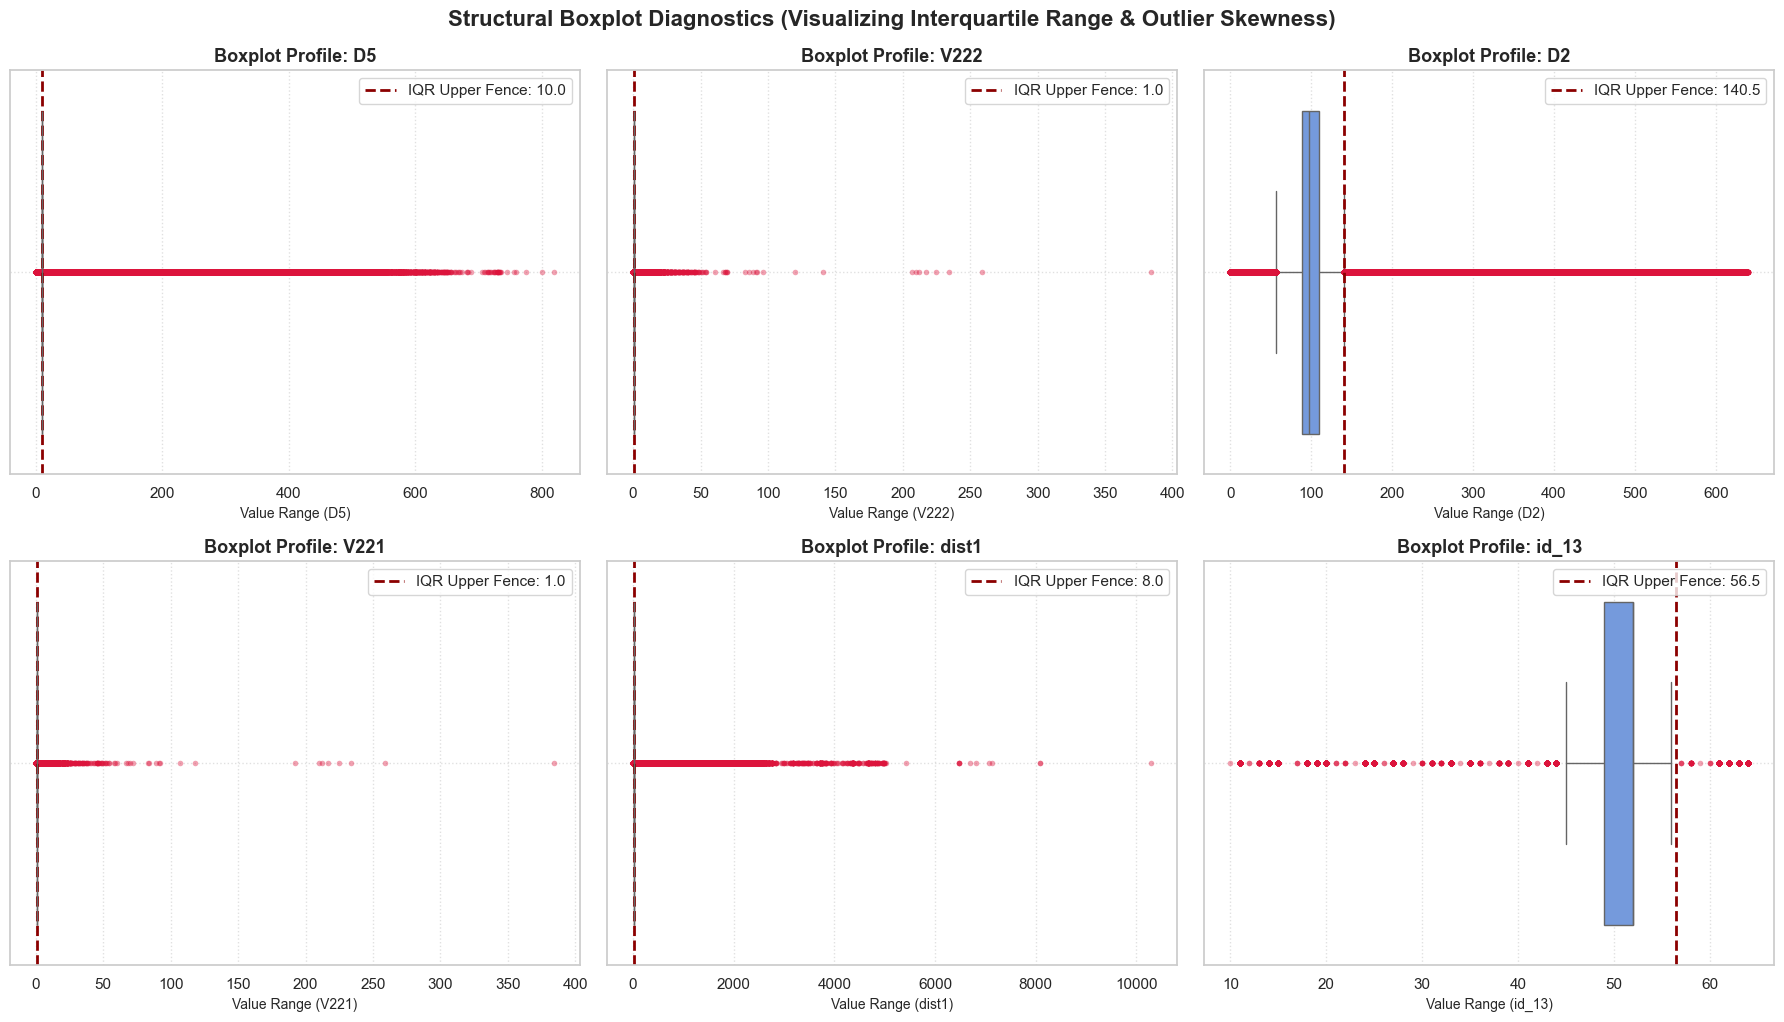

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== GENERATING STANDARDIZED BOXPLOTS FOR HIGH-OUTLIER FEATURES ===")

# 1. Select the top 6 features exhibiting collapsed fence characteristics
target_outliers = ['D5', 'V222', 'D2', 'V221', 'dist1', 'id_13']

# Dictionary of upper fences from your dynamic table to highlight programmatic limits
upper_fences = {
    'D5': 10.0,
    'V222': 1.0,
    'D2': 140.5,
    'V221': 1.0,
    'dist1': 8.0,
    'id_13': 56.5
}

# 2. Initialize a 2x3 subplots canvas
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

# 3. Dynamic layout plotting loops
for idx, col in enumerate(target_outliers):
    if col in df_train_preprocessed.columns:
        # Mask missing value placeholders to preserve structural behavioral boundaries
        plot_data = df_train_preprocessed[col].replace(-999, np.nan).dropna()
        
        # Draw the standard boxplot horizontally
        sns.boxplot(
            x=plot_data,
            ax=axes[idx],
            color='cornflowerblue',
            orient='h',
            flierprops={'marker': 'o', 'markerfacecolor': 'crimson', 'markeredgecolor': 'none', 'markersize': 4, 'alpha': 0.4}
        )
        
        # Add the explicit statistical upper fence threshold line
        fence_val = upper_fences[col]
        axes[idx].axvline(x=fence_val, color='darkred', linestyle='--', linewidth=2, 
                          label=f"IQR Upper Fence: {fence_val}")
        
        # Refine presentation structures
        axes[idx].set_title(f"Boxplot Profile: {col}", fontsize=13, fontweight='bold')
        axes[idx].set_xlabel(f"Value Range ({col})", fontsize=10)
        axes[idx].legend(loc='upper right')
        axes[idx].grid(True, linestyle=':', alpha=0.6)

# 4. Finalize canvas spacing
plt.tight_layout()
plt.suptitle("Structural Boxplot Diagnostics (Visualizing Interquartile Range & Outlier Skewness)", 
             y=1.02, fontsize=16, fontweight='bold')
plt.show()

* **IQR Limitations in Highly Skewed Variables ($IQR = 0$):** Identical lower and upper limits across the `V`, `D`, and `C` blocks reveal highly zero-inflated and mode-concentrated distributions, typical of transactional fraud matrices.
* **Artificial Outlier Inflation:** The traditional $IQR$ method generates severe false-positive indicators (flagging up to 46.8% outliers) because any marginal operational deviation from the structural baseline is programmatically treated as an anomaly.
* **Extreme Right-Skewness Signature:** The massive long-tail distributions visible in features like `dist1` or `V263` represent genuine financial velocity spikes, automated scripting footprints, or physical macro-behavior patterns.
* **Strategic Non-Truncation Decision:** Conventional data-cleansing techniques like *Winsorization* or row-dropping are explicitly rejected to preserve these critical fraud signals, relying instead on tree-based architectures for downstream processing.

In [33]:
print("=== EXPORTING PREPROCESSED DATAFRAME TO CSV ===")

# Define your target file path and filename
output_filename = "df_train_preprocessed.csv"

# Export data matrix cleanly without including the row index column
df_train_preprocessed.to_csv(output_filename, index=False)

print(f"--> Success! Preprocessed dataset saved as: '{output_filename}'")

=== EXPORTING PREPROCESSED DATAFRAME TO CSV ===
--> Success! Preprocessed dataset saved as: 'df_train_preprocessed.csv'


## Section D: Exploratory Data Analysis

After validating data quality, exploratory analysis can be performed with greater confidence. The objective of this section is to understand feature distributions, identify informative variables, and detect relationships that may support future feature selection and dimensionality reduction.

### D1 - Univariate Analysis: Numerical Features

This section examines the distribution of numerical variables. Histograms are used to understand the shape, spread, and skewness of the data. Separate distributions are shown for fraudulent and legitimate transactions.

=== DEPLOYING D1 PIPELINE: NUMERICAL FEATURES (LINEAR SCALE) ===
--> Rendering D1 Batch 1 (Linear Scale)...


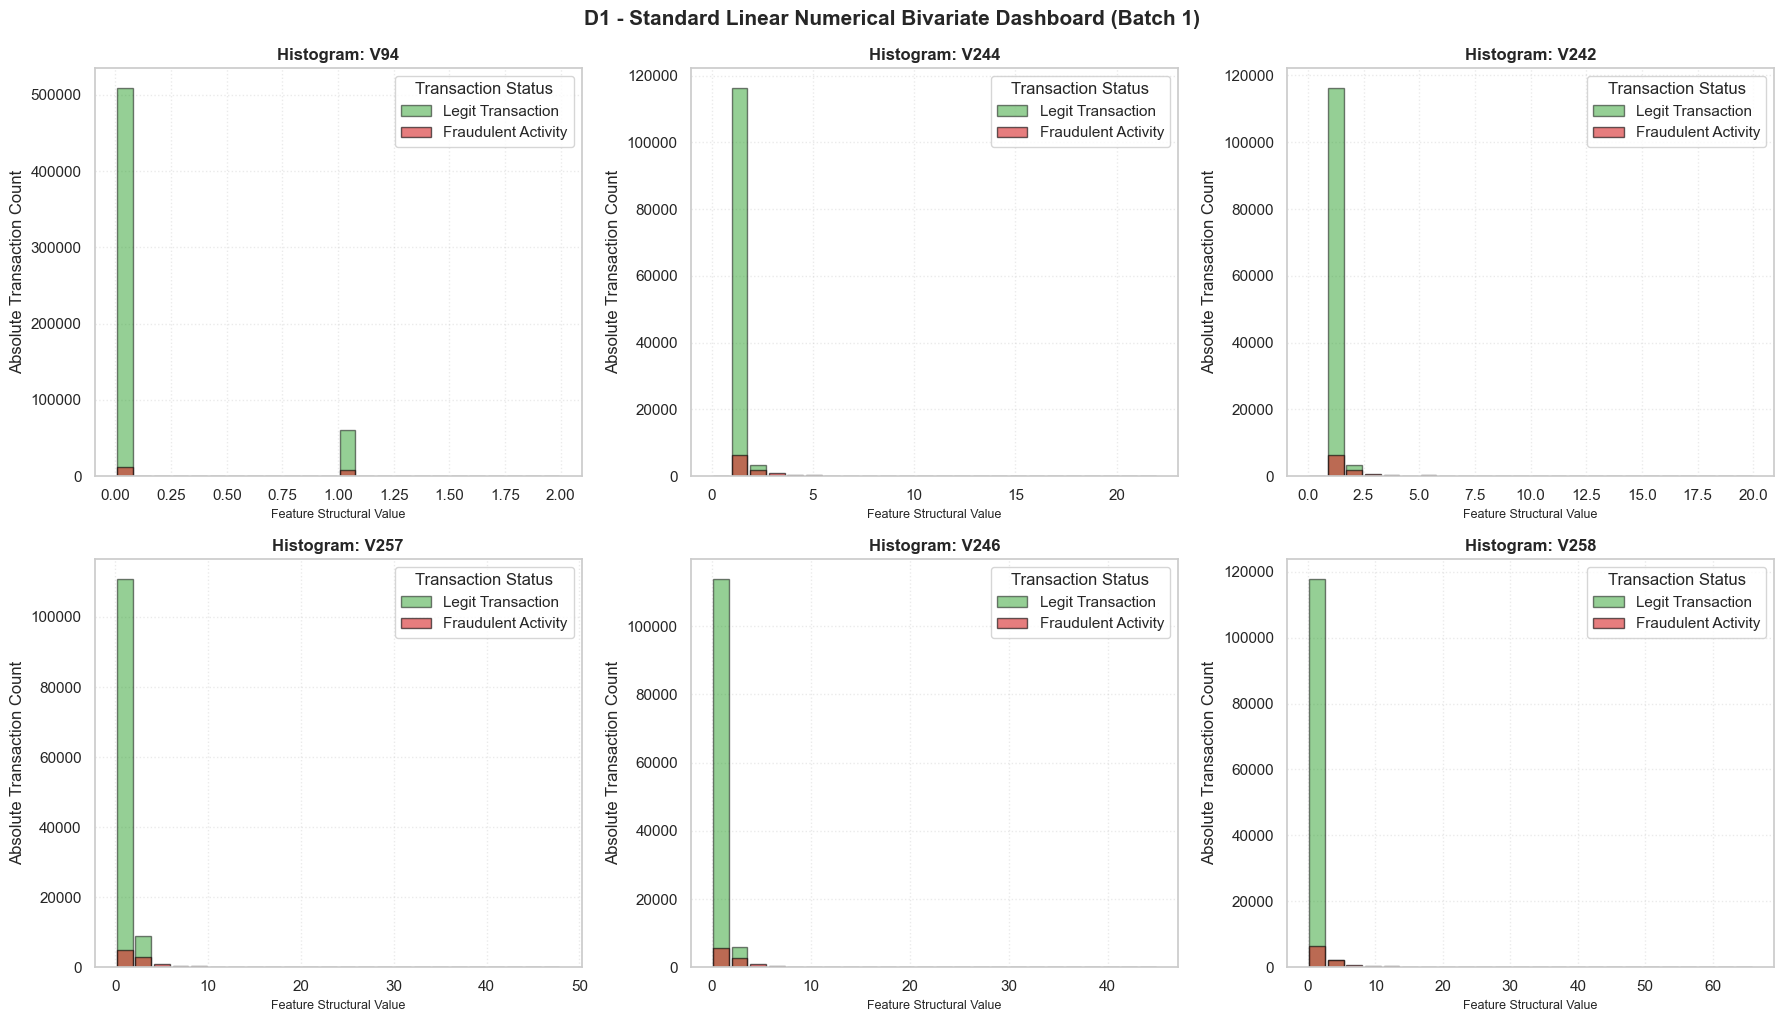

----------------------------------------------------------------------------------------------------
--> Rendering D1 Batch 2 (Linear Scale)...


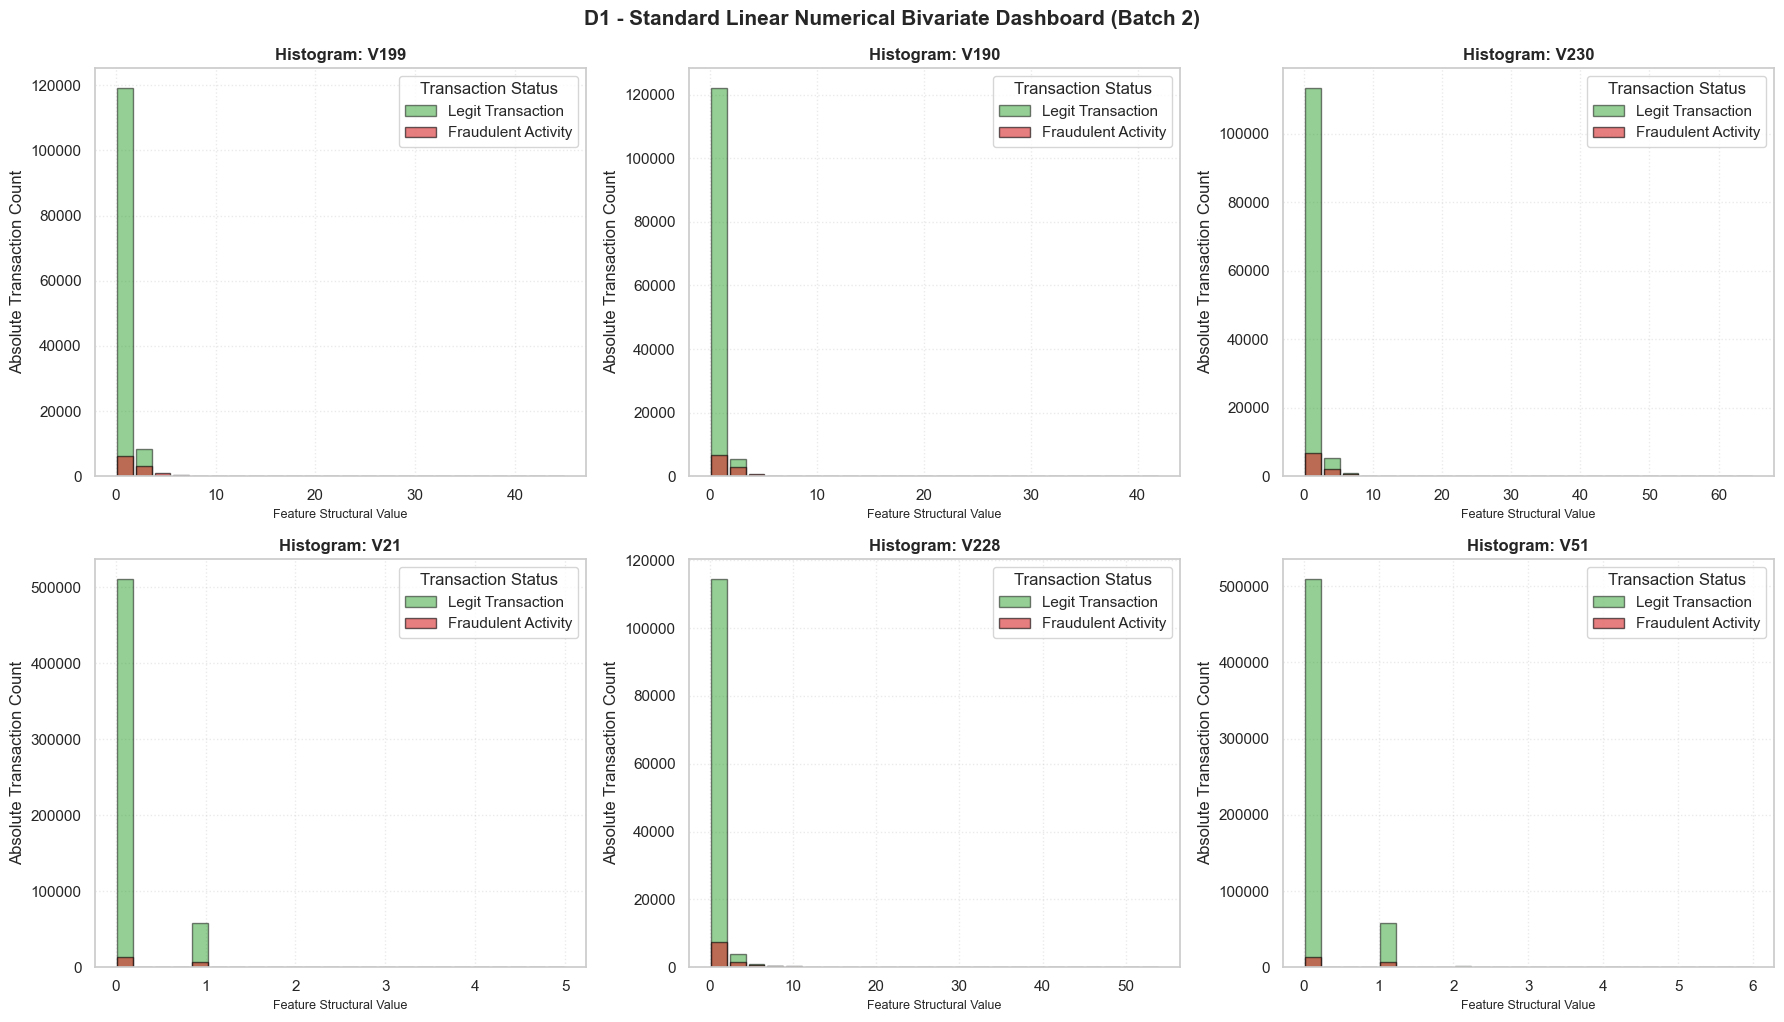

----------------------------------------------------------------------------------------------------
--> Rendering D1 Batch 3 (Linear Scale)...


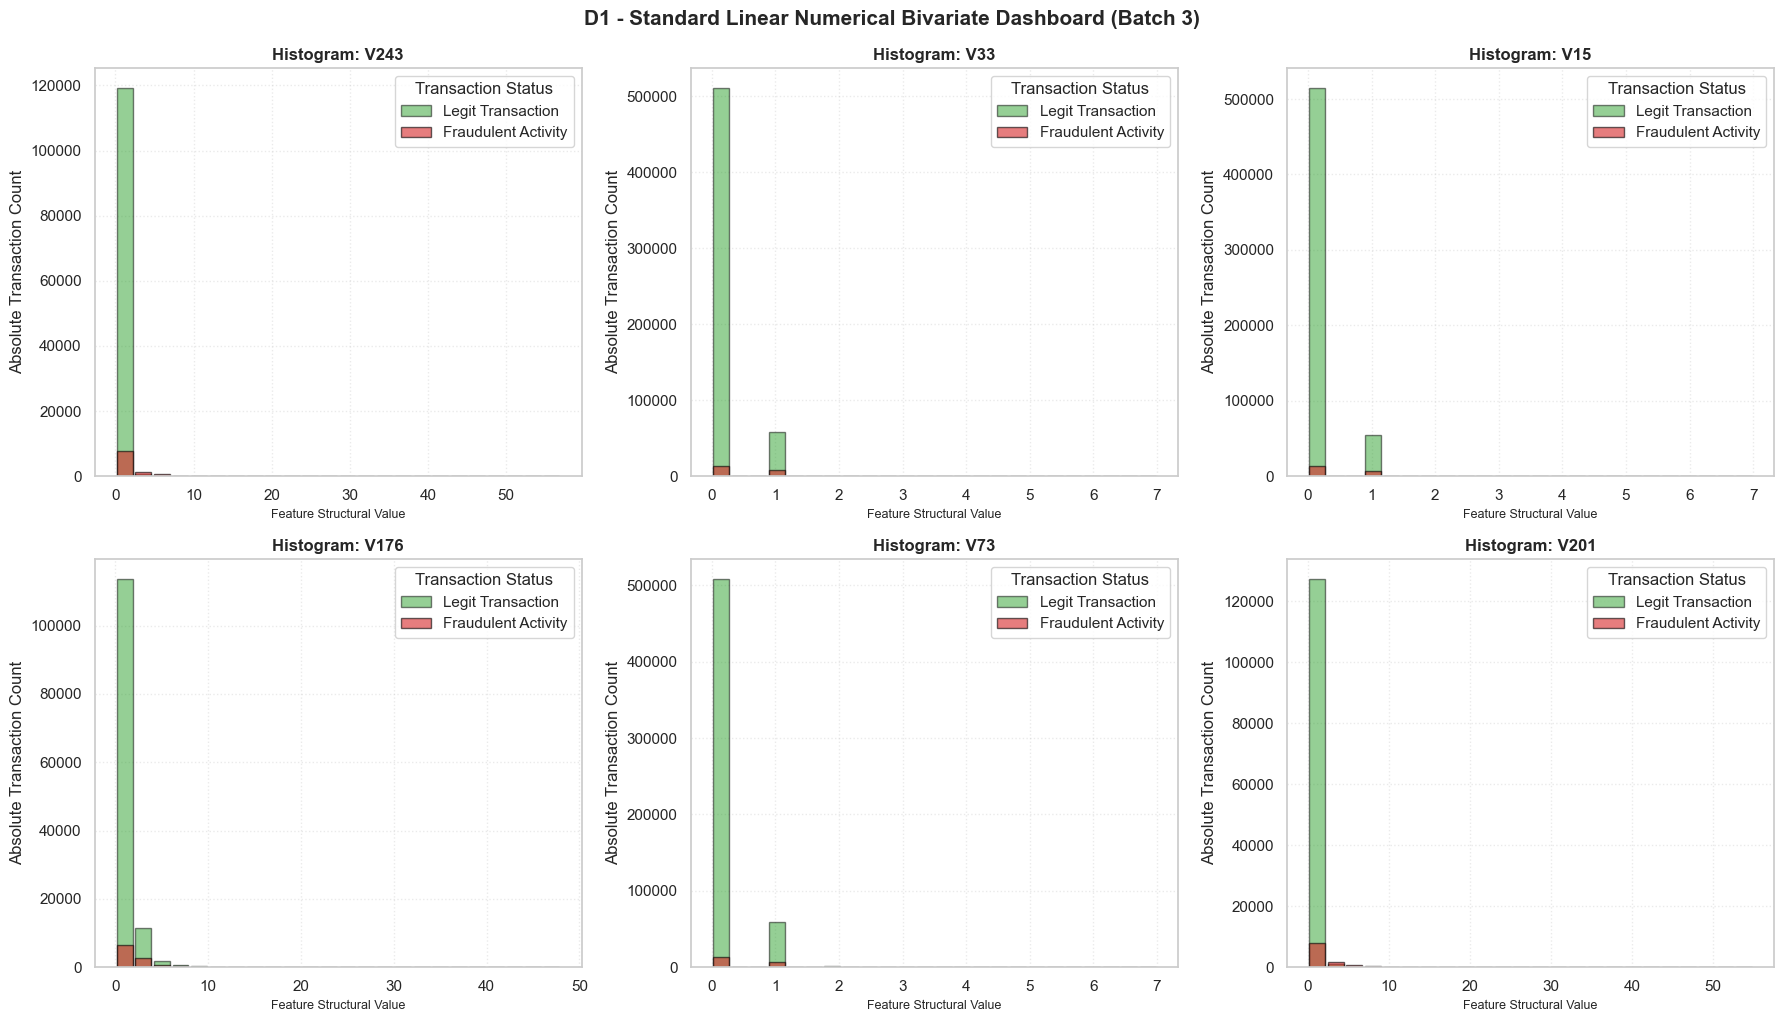

----------------------------------------------------------------------------------------------------
--> Rendering D1 Batch 4 (Linear Scale)...


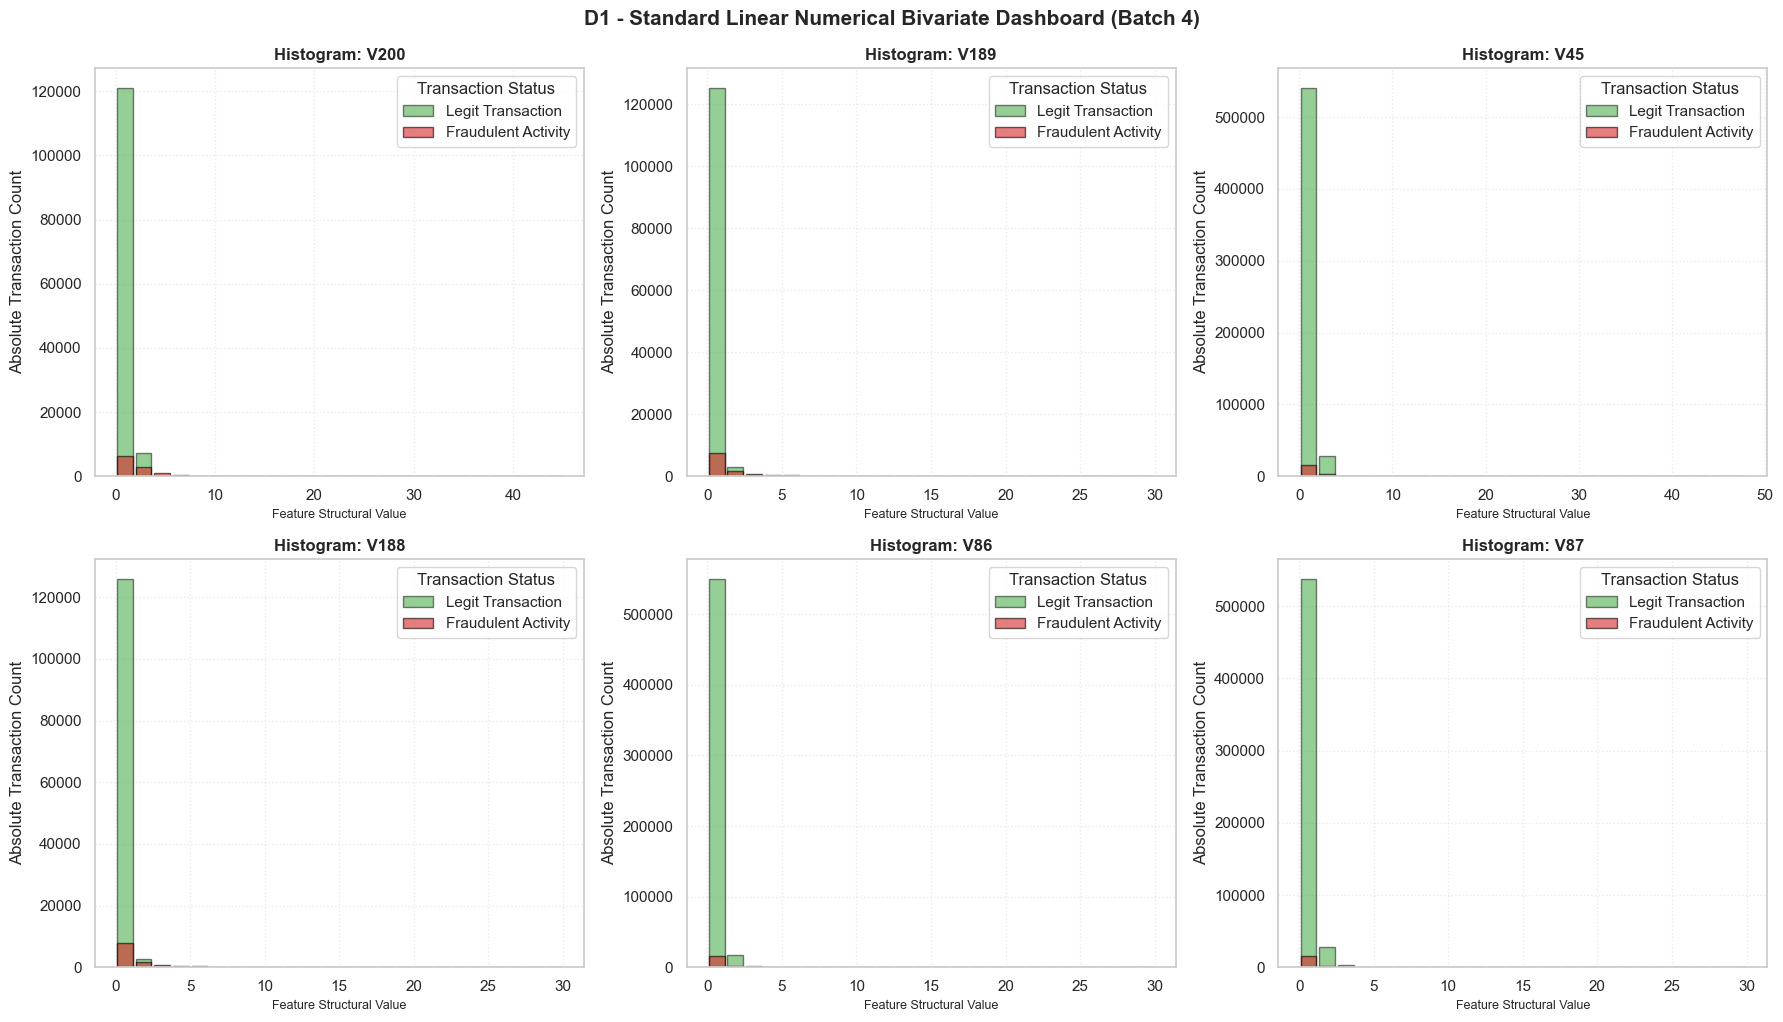

----------------------------------------------------------------------------------------------------
--> Rendering D1 Batch 5 (Linear Scale)...


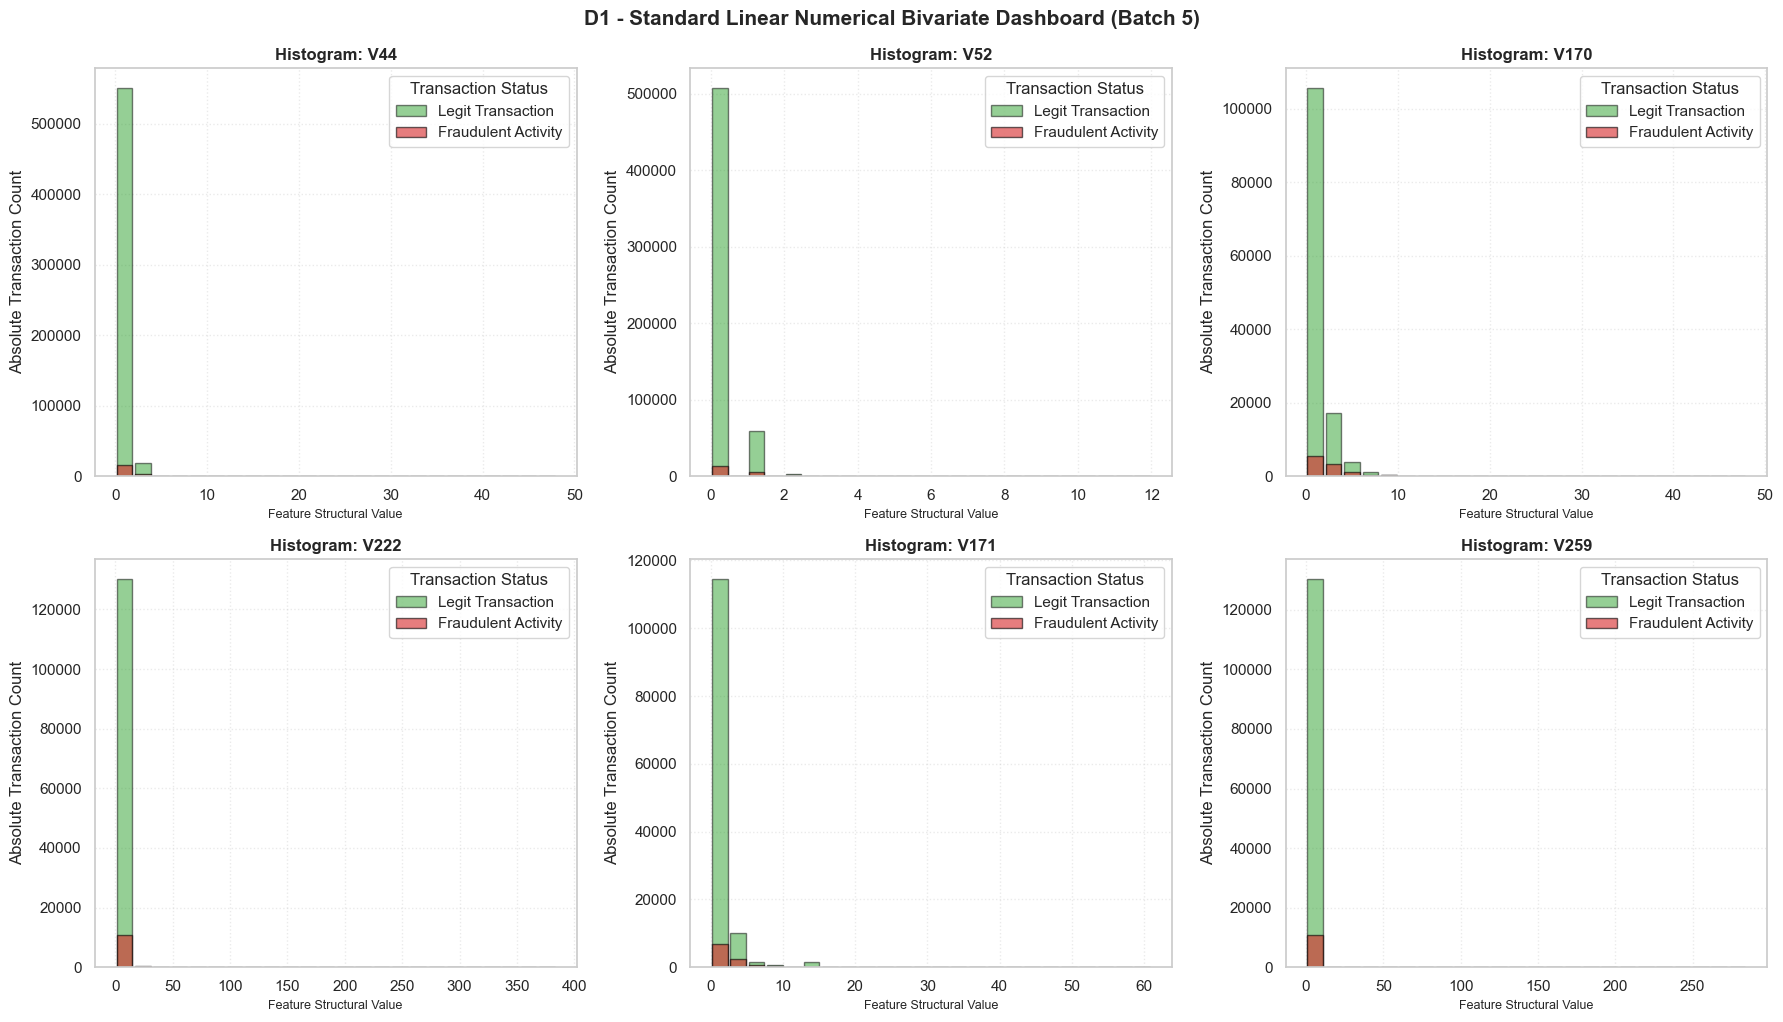

----------------------------------------------------------------------------------------------------
--> Rendering D1 Batch 6 (Linear Scale)...


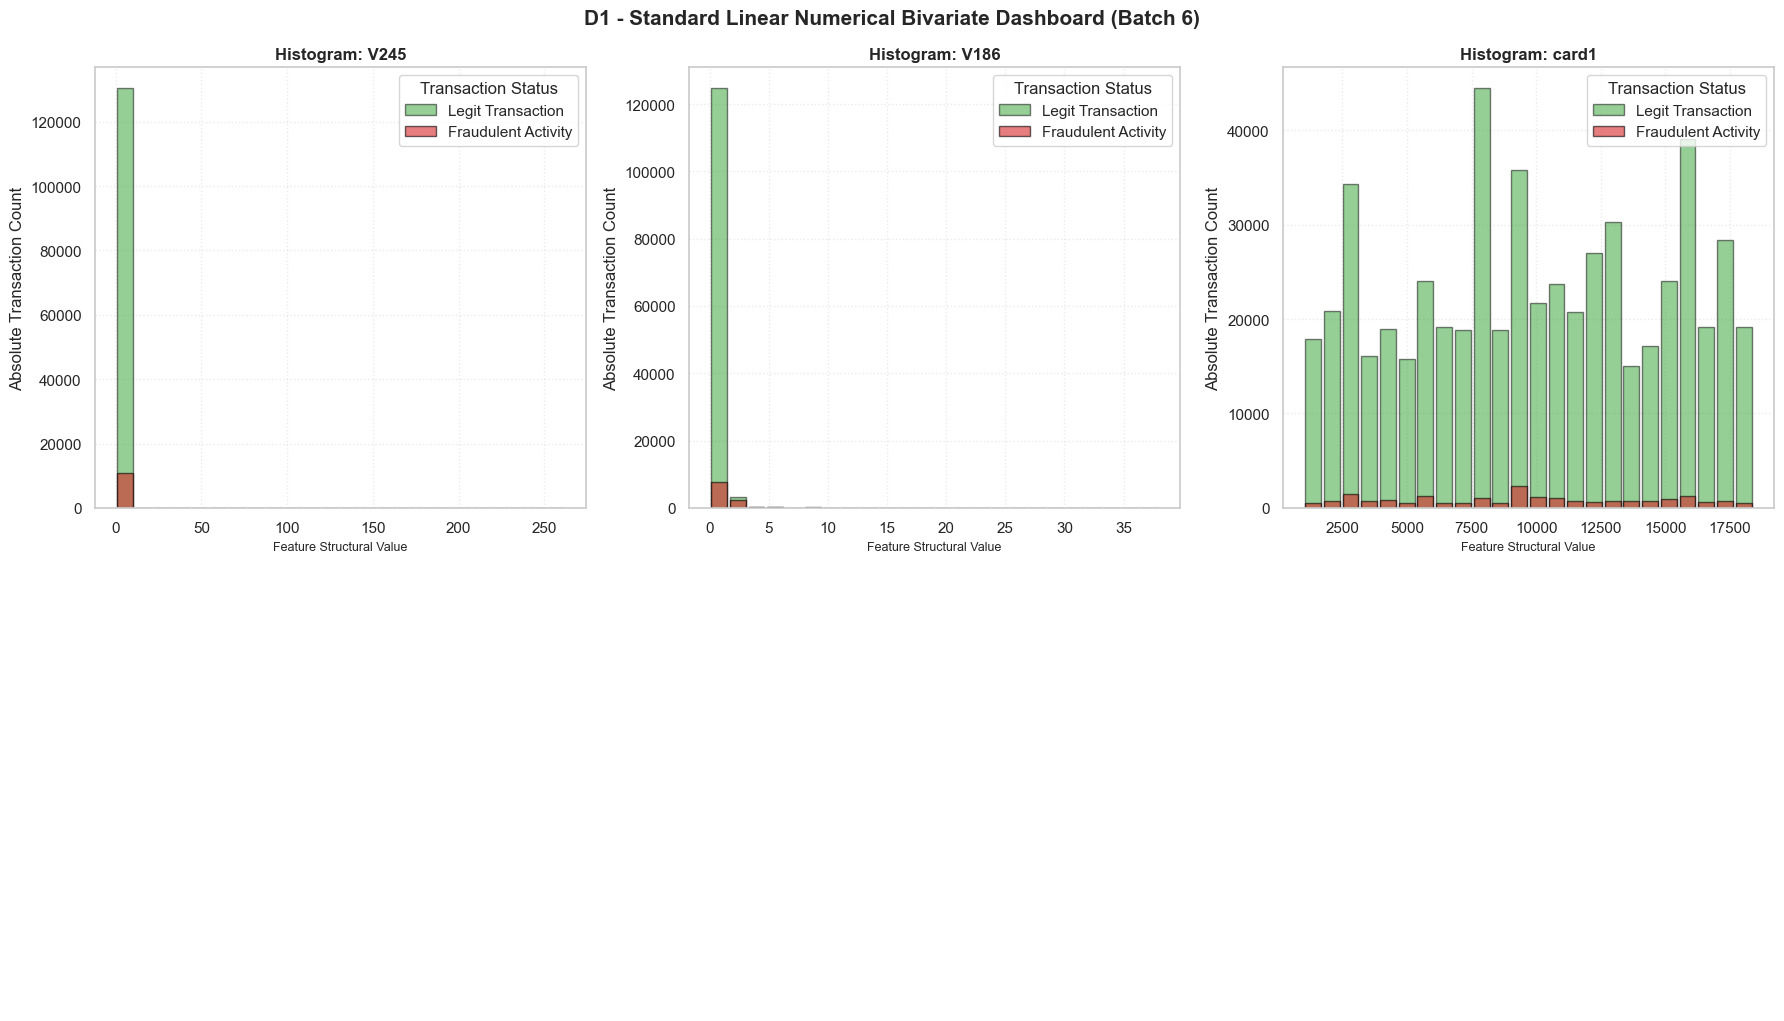

----------------------------------------------------------------------------------------------------


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== DEPLOYING D1 PIPELINE: NUMERICAL FEATURES (LINEAR SCALE) ===")

# 1. Purified list: Only numerical continuous/count features from the charts
numerical_ranked_features = [
    'V94', 'V244', 'V242', 'V257', 'V246', 'V258', 'V199', 'V190', 'V230', 
    'V21', 'V228', 'V51', 'V243', 'V33', 'V15', 'V176', 'V73', 'V201', 
    'V200', 'V189', 'V45', 'V188', 'V86', 'V87', 'V44', 'V52', 'V170', 
    'V222', 'V171', 'V259', 'V245', 'V186', 'card1'
]

unique_numerical = list(dict.fromkeys(numerical_ranked_features))

risk_colors = {0: '#2ca02c', 1: '#d62728'}  # Green (Legit) vs Red (Fraud)
labels_dict = {0: 'Legit Transaction', 1: 'Fraudulent Activity'}

batch_size = 6
total_numeric = len(unique_numerical)

# 2. Dynamic Batching Loop for Linear Histograms
for i in range(0, total_numeric, batch_size):
    batch_cols = unique_numerical[i:i + batch_size]
    
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.flatten()
    
    print(f"--> Rendering D1 Batch {i//batch_size + 1} (Linear Scale)...")
    
    for idx, col in enumerate(batch_cols):
        if col in df_train_preprocessed.columns:
            temp_df = df_train_preprocessed[[col, 'isFraud']].copy()
            temp_df[col] = temp_df[col].replace(-999, np.nan)
            temp_df = temp_df.dropna(subset=[col])
            
            legit_data = temp_df[temp_df['isFraud'] == 0][col]
            fraud_data = temp_df[temp_df['isFraud'] == 1][col]
            
            # Continuous data scaling bounds
            bins_edges = np.linspace(temp_df[col].min(), temp_df[col].max(), 25)
            
            # Superimposed Native Matplotlib Linear Histograms (log=False)
            axes[idx].hist(legit_data, bins=bins_edges, color=risk_colors[0], alpha=0.5, 
                           edgecolor='black', label=labels_dict[0], log=False, rwidth=0.85)
            axes[idx].hist(fraud_data, bins=bins_edges, color=risk_colors[1], alpha=0.6, 
                           edgecolor='black', label=labels_dict[1], log=False, rwidth=0.85)
            
            # Refined Titles and Labels for Standard Scale Alignment
            axes[idx].set_title(f"Histogram: {col}", fontsize=12, fontweight='bold')
            axes[idx].set_xlabel("Feature Structural Value", fontsize=9)
            axes[idx].set_ylabel("Absolute Transaction Count")
            axes[idx].grid(True, linestyle=':', alpha=0.4)  # Default linear grid matrix
            axes[idx].legend(title="Transaction Status", loc='upper right')
        else:
            axes[idx].text(0.5, 0.5, f"Feature '{col}'\nNot Found", ha='center', va='center', color='gray')
            axes[idx].axis('off')
            
    for j in range(len(batch_cols), batch_size):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.suptitle(f"D1 - Standard Linear Numerical Bivariate Dashboard (Batch {(i//batch_size)+1})", 
                 y=1.02, fontsize=15, fontweight='bold')
    plt.show()
    print("-" * 100)

Many numerical features are highly skewed, with most observations concentrated around a few values. This makes it difficult to visualize less frequent observations using a standard linear scale.

For this reason, a logarithmic scale was applied to better examine the full distribution of each feature and compare fraudulent and legitimate transactions.


=== DEPLOYING D1 PIPELINE: NUMERICAL FEATURES ===
--> Rendering D1 Batch 1...


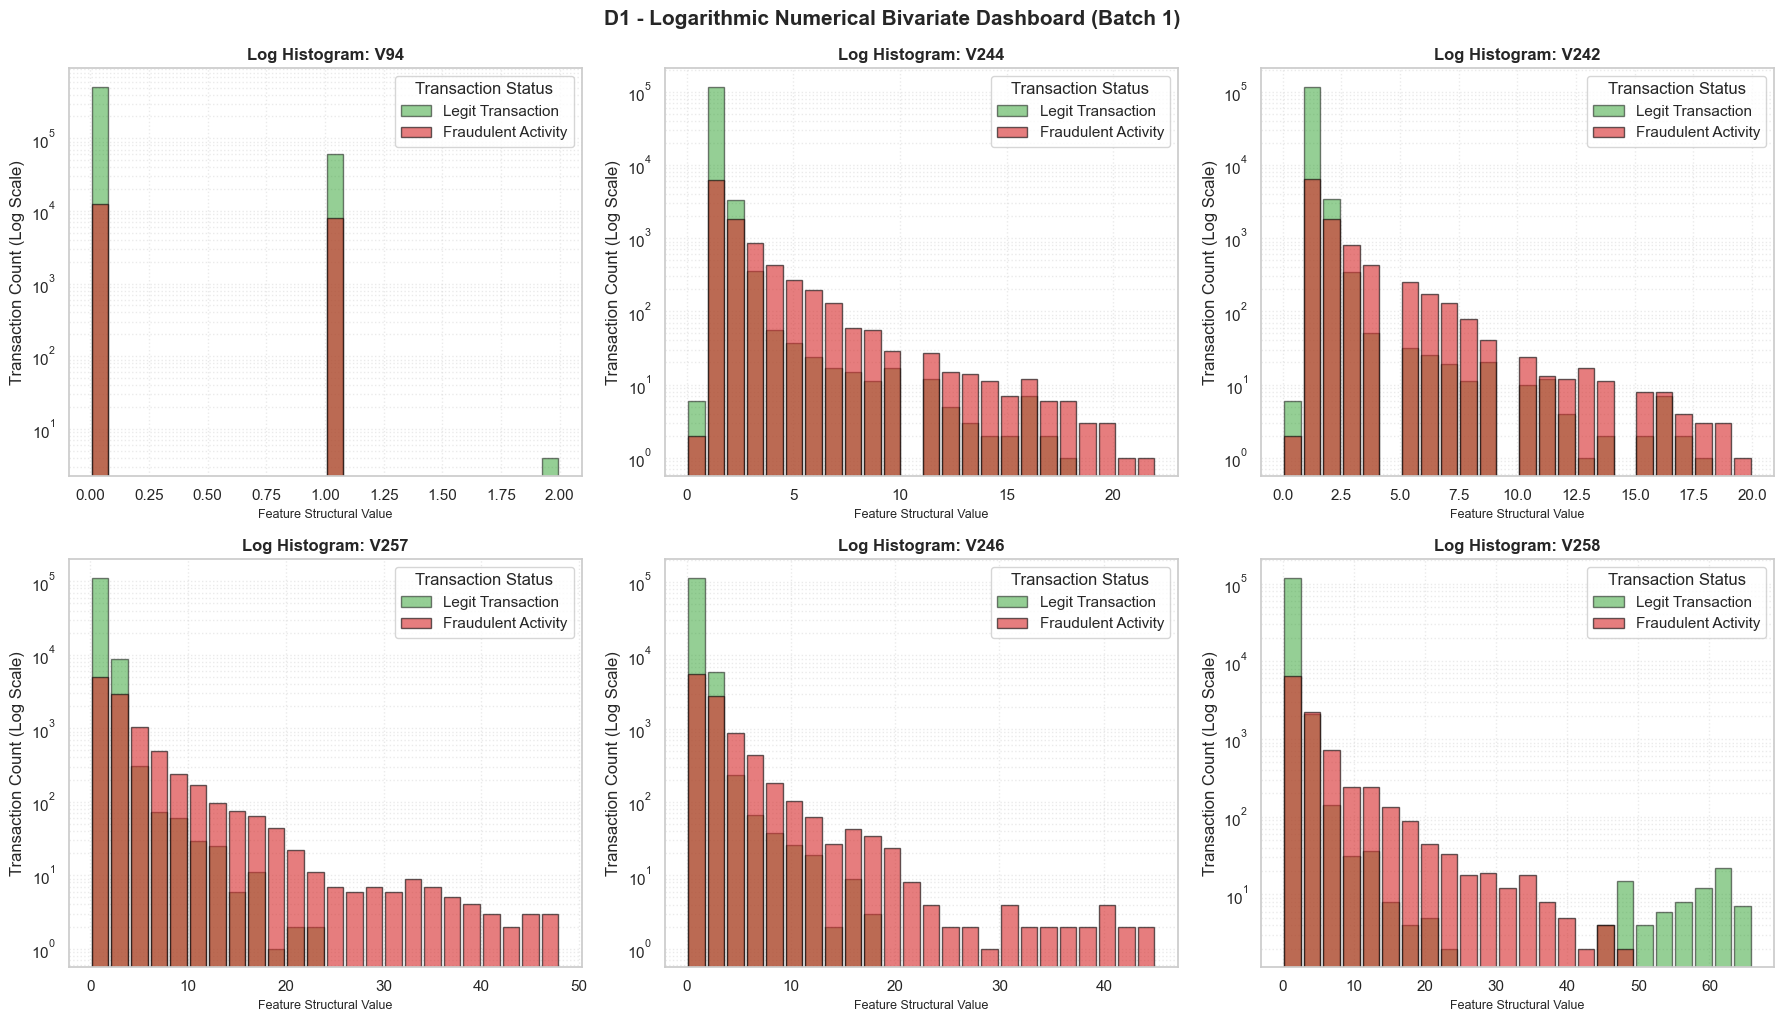

----------------------------------------------------------------------------------------------------
--> Rendering D1 Batch 2...


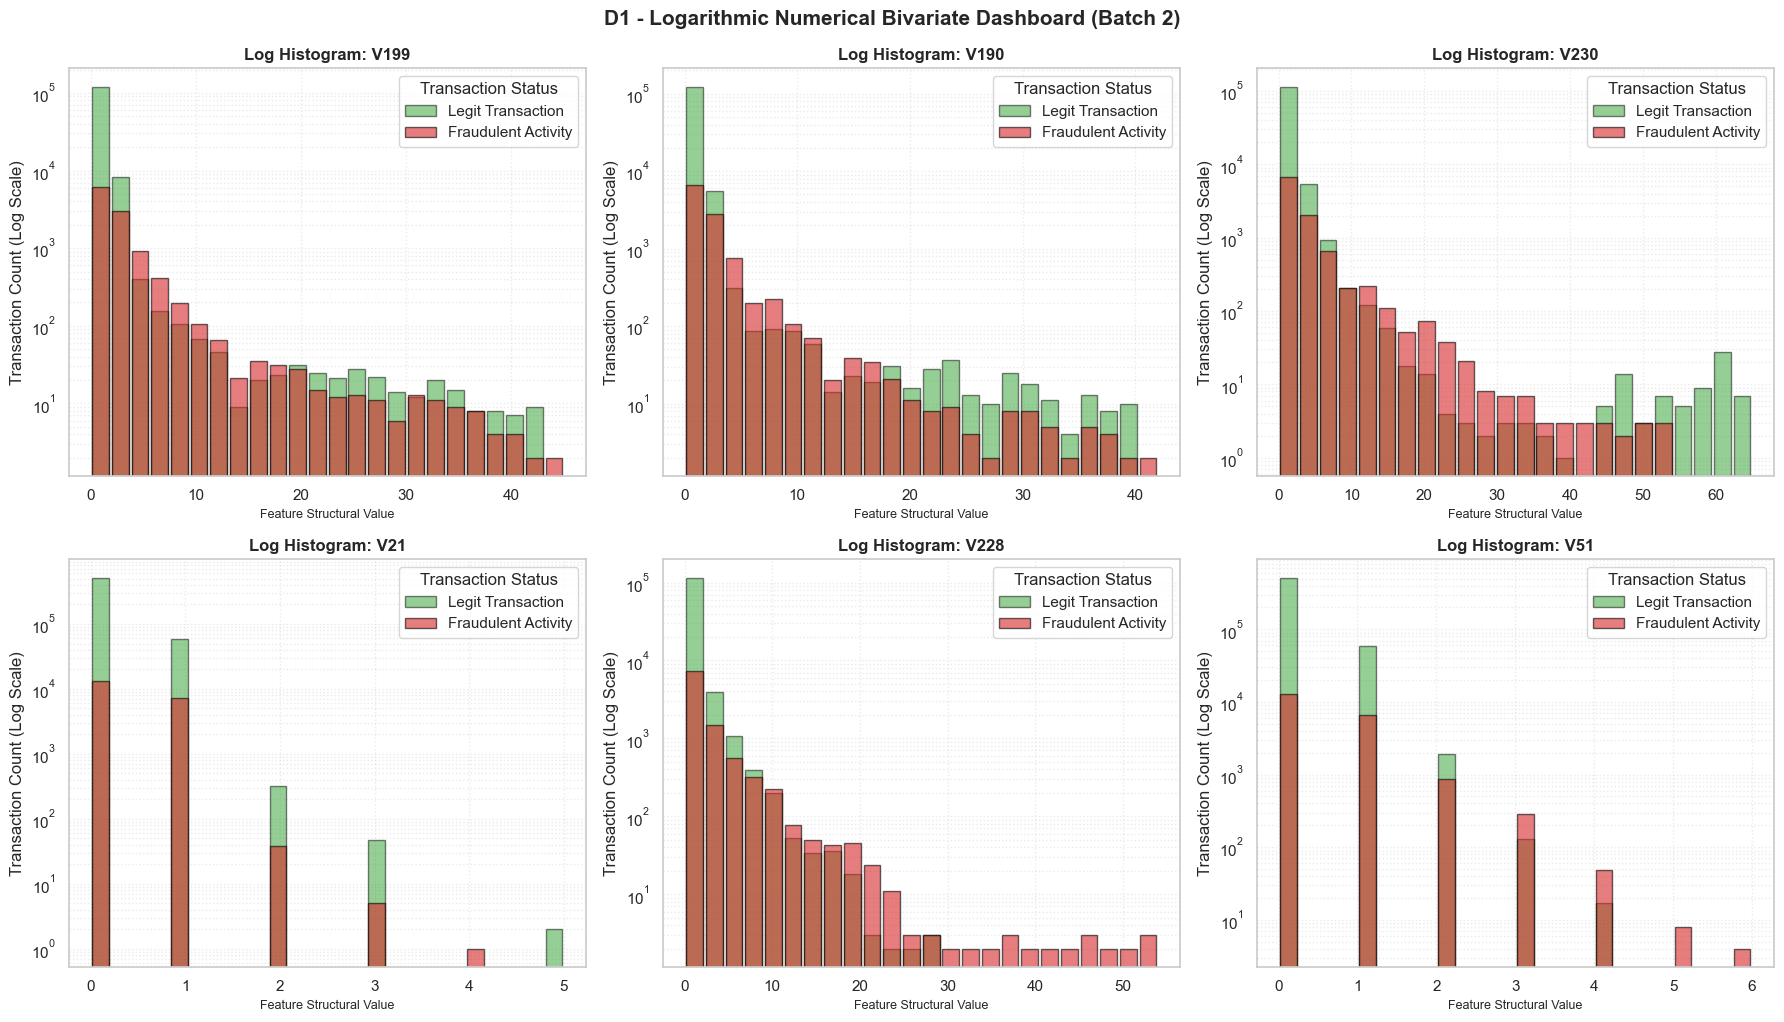

----------------------------------------------------------------------------------------------------
--> Rendering D1 Batch 3...


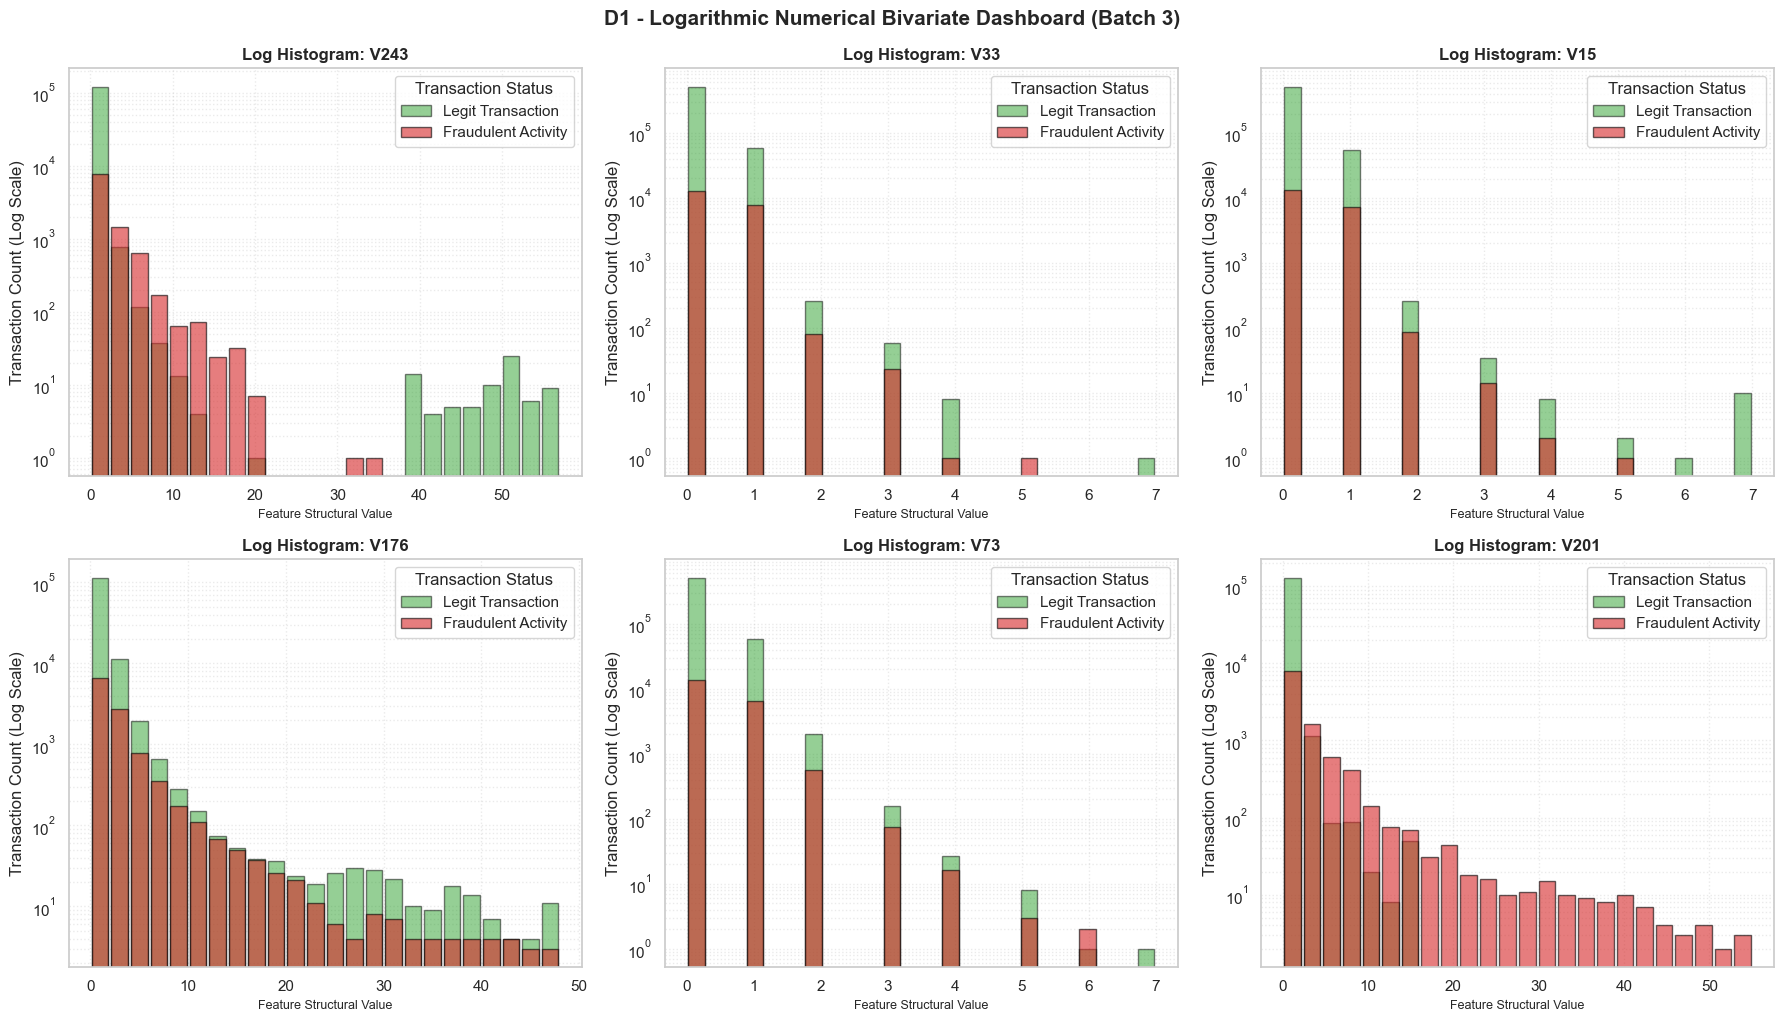

----------------------------------------------------------------------------------------------------
--> Rendering D1 Batch 4...


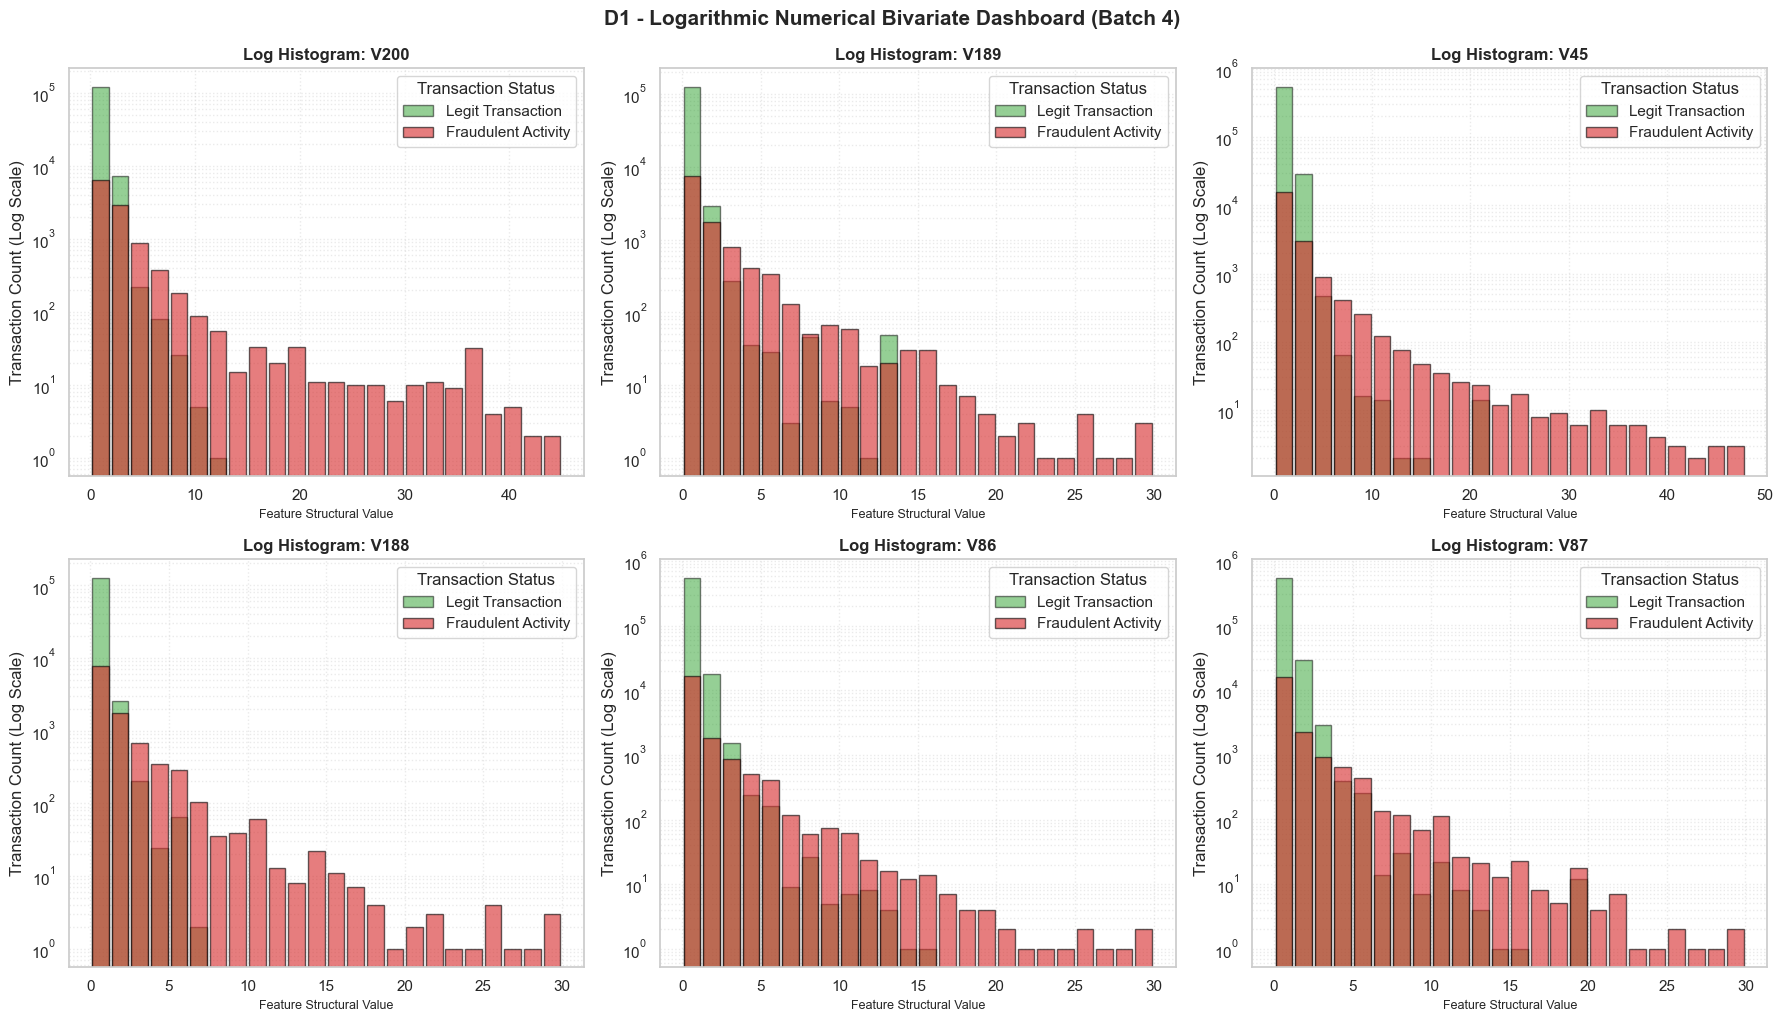

----------------------------------------------------------------------------------------------------
--> Rendering D1 Batch 5...


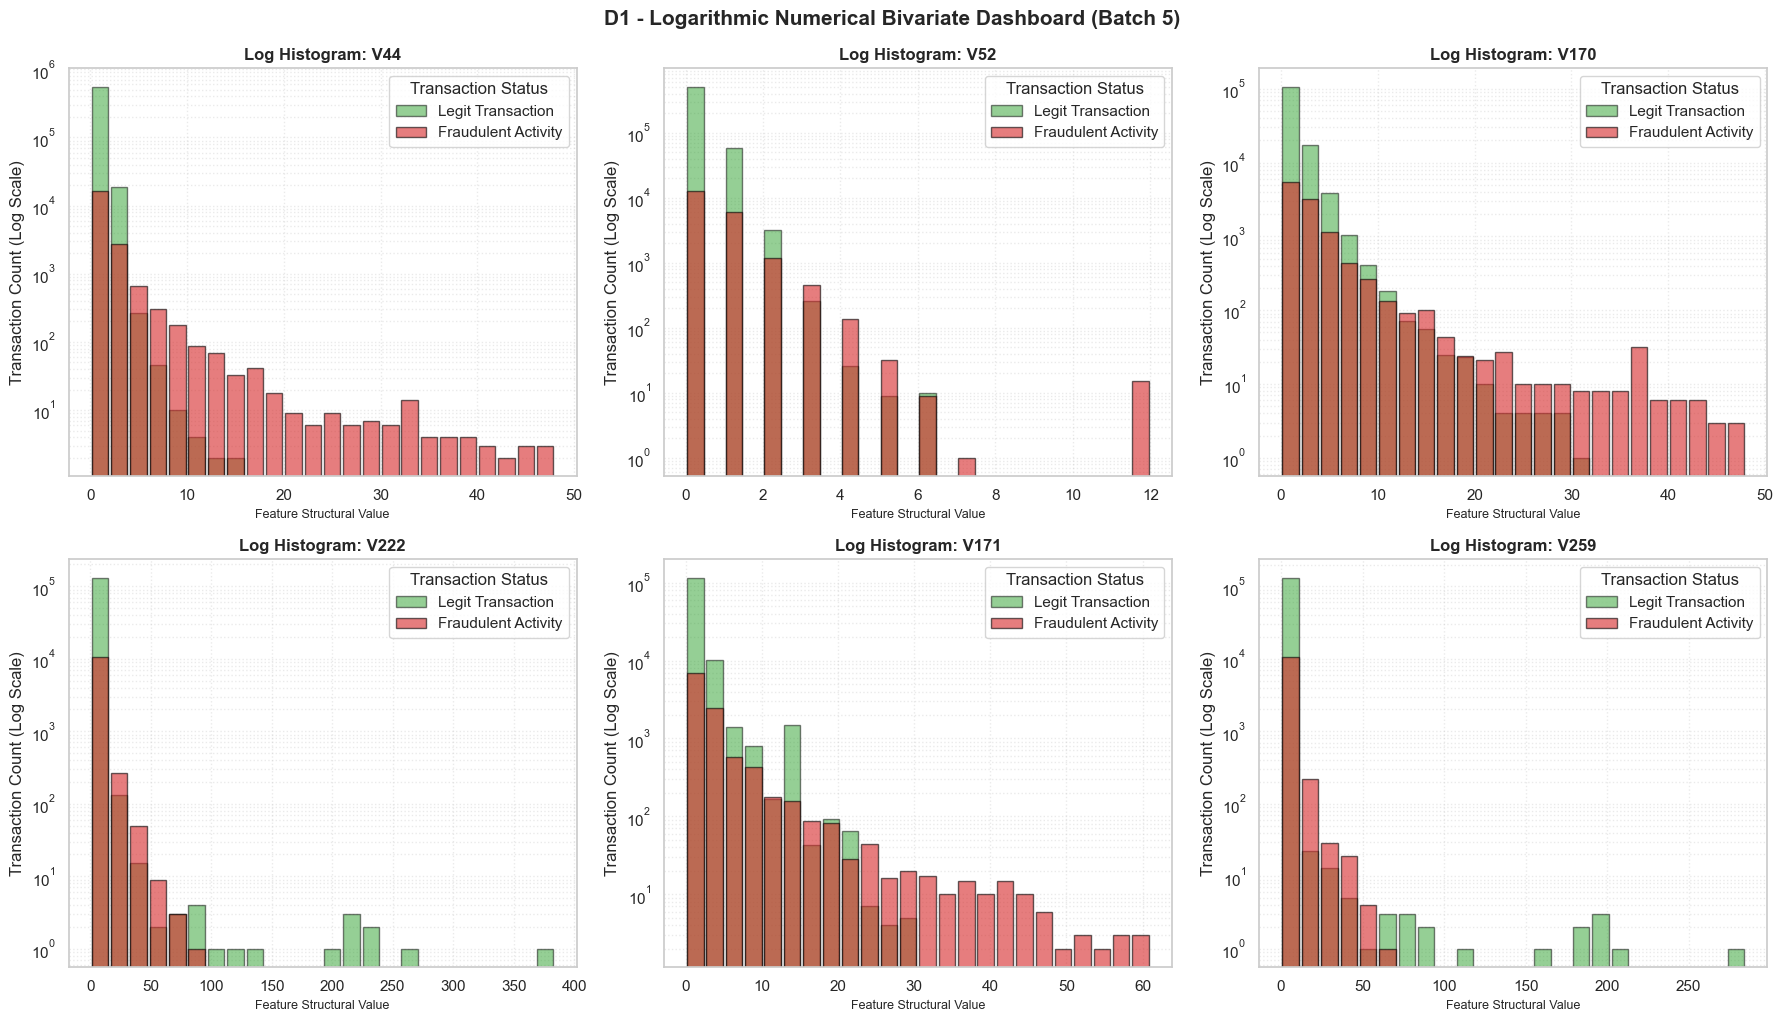

----------------------------------------------------------------------------------------------------
--> Rendering D1 Batch 6...


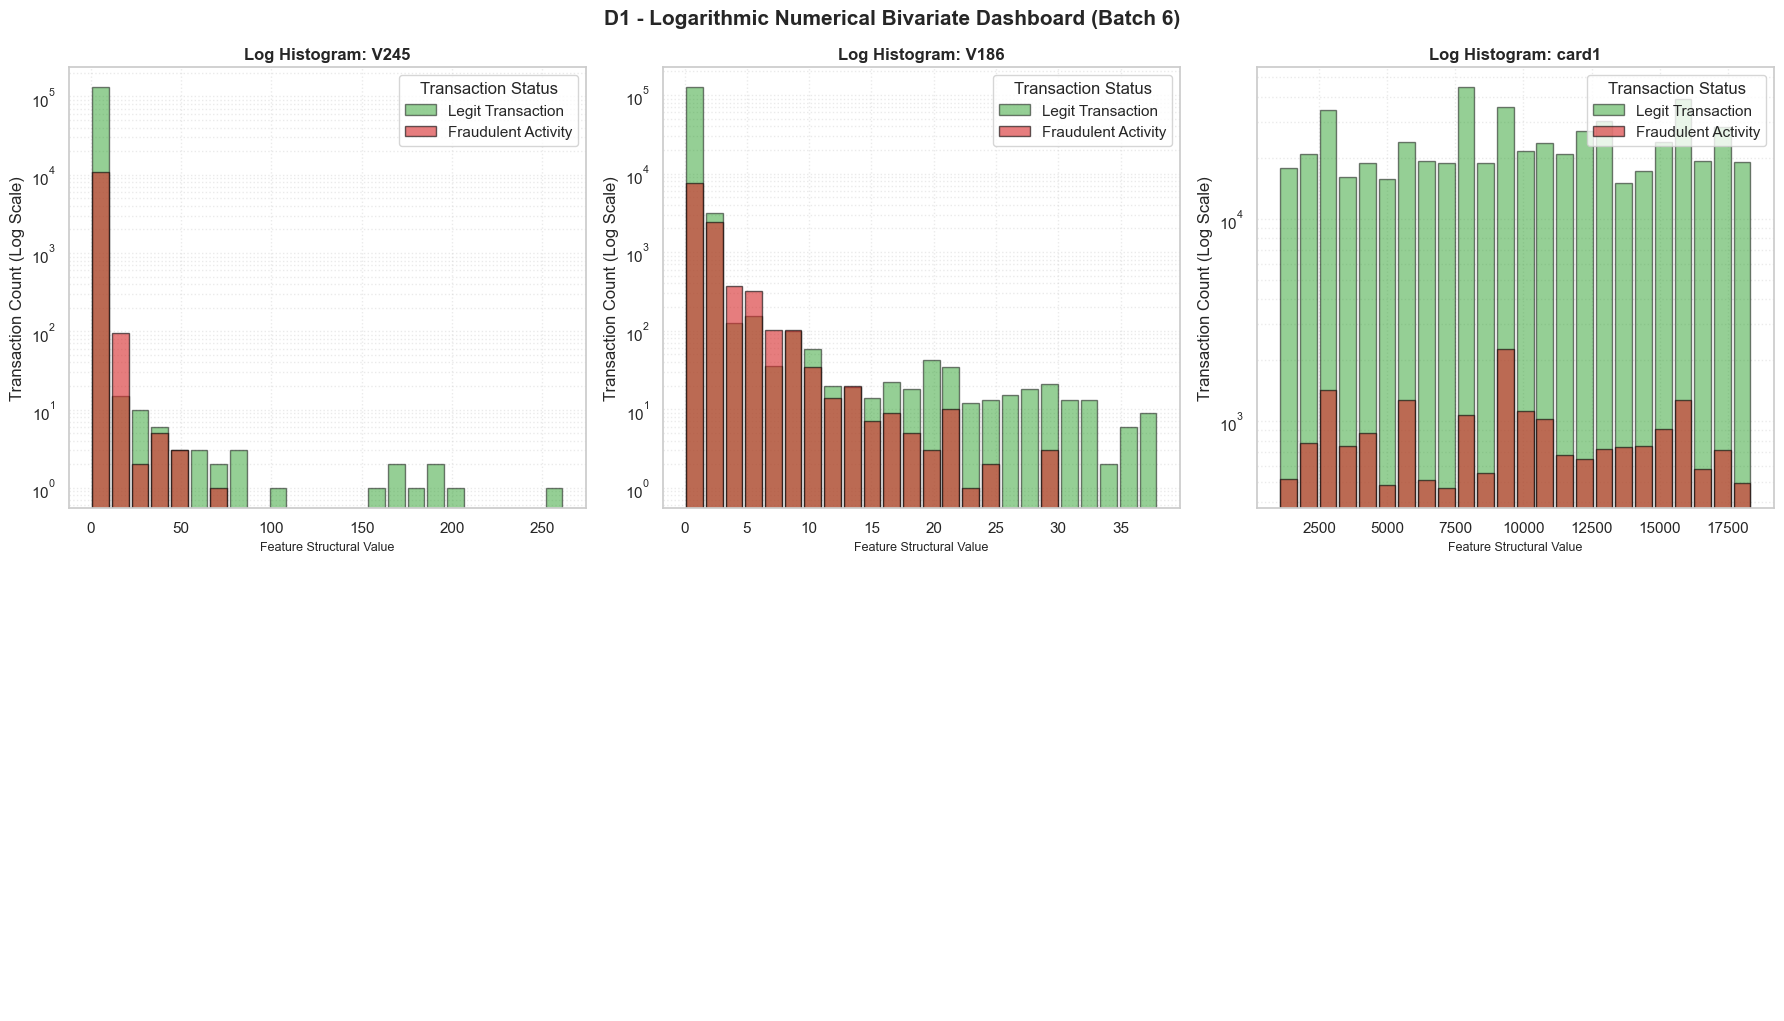

----------------------------------------------------------------------------------------------------


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== DEPLOYING D1 PIPELINE: NUMERICAL FEATURES ===")

# 1. Purified list: Only numerical continuous/count features from the charts
numerical_ranked_features = [
    'V94', 'V244', 'V242', 'V257', 'V246', 'V258', 'V199', 'V190', 'V230', 
    'V21', 'V228', 'V51', 'V243', 'V33', 'V15', 'V176', 'V73', 'V201', 
    'V200', 'V189', 'V45', 'V188', 'V86', 'V87', 'V44', 'V52', 'V170', 
    'V222', 'V171', 'V259', 'V245', 'V186', 'card1'
]

unique_numerical = list(dict.fromkeys(numerical_ranked_features))

risk_colors = {0: '#2ca02c', 1: '#d62728'}  # Green (Legit) vs Red (Fraud)
labels_dict = {0: 'Legit Transaction', 1: 'Fraudulent Activity'}

batch_size = 6
total_numeric = len(unique_numerical)

# 2. Dynamic Batching Loop for Histograms
for i in range(0, total_numeric, batch_size):
    batch_cols = unique_numerical[i:i + batch_size]
    
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.flatten()
    
    print(f"--> Rendering D1 Batch {i//batch_size + 1}...")
    
    for idx, col in enumerate(batch_cols):
        if col in df_train_preprocessed.columns:
            temp_df = df_train_preprocessed[[col, 'isFraud']].copy()
            temp_df[col] = temp_df[col].replace(-999, np.nan).dropna()
            temp_df = temp_df.dropna(subset=[col])
            
            legit_data = temp_df[temp_df['isFraud'] == 0][col]
            fraud_data = temp_df[temp_df['isFraud'] == 1][col]
            
            # Continuous data scaling bounds
            bins_edges = np.linspace(temp_df[col].min(), temp_df[col].max(), 25)
            
            # Superimposed Native Matplotlib Log Histograms
            axes[idx].hist(legit_data, bins=bins_edges, color=risk_colors[0], alpha=0.5, 
                           edgecolor='black', label=labels_dict[0], log=True, rwidth=0.85)
            axes[idx].hist(fraud_data, bins=bins_edges, color=risk_colors[1], alpha=0.6, 
                           edgecolor='black', label=labels_dict[1], log=True, rwidth=0.85)
            
            axes[idx].set_title(f"Log Histogram: {col}", fontsize=12, fontweight='bold')
            axes[idx].set_xlabel("Feature Structural Value", fontsize=9)
            axes[idx].set_ylabel("Transaction Count (Log Scale)")
            axes[idx].grid(True, linestyle=':', alpha=0.4, which="both")
            axes[idx].legend(title="Transaction Status", loc='upper right')
        else:
            axes[idx].text(0.5, 0.5, f"Feature '{col}'\nNot Found", ha='center', va='center', color='gray')
            axes[idx].axis('off')
            
    for j in range(len(batch_cols), batch_size):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.suptitle(f"D1 - Logarithmic Numerical Bivariate Dashboard (Batch {(i//batch_size)+1})", 
                 y=1.02, fontsize=15, fontweight='bold')
    plt.show()
    print("-" * 100)

**Conclusion:**

* Several `V` variables show different distribution patterns between fraudulent and legitimate transactions, suggesting they may be useful predictors of fraud.

* Features such as `V244`, `V242`, `V257`, and `V201` contain value ranges where fraudulent transactions appear more concentrated than legitimate ones.

* The `card1` feature shows high variability and does not appear dominated by a small number of values, indicating that it may contain useful information for future modeling.


### D2 - Univariate Analysis: Categorical Features

This section examines the distribution of categorical variables and their relationship with fraud.

Grouped count plots with a logarithmic scale were used to compare the frequency of categories across fraudulent and legitimate transactions. Using a log scale allows both common and rare categories to be clearly displayed.

The goal is to identify categorical features that may be useful for fraud detection and future predictive modeling.

=== DEPLOYING D2 PIPELINE: AUTOMATED CATEGORICAL FEATURES SWEEP ===
--> Found 32 categorical features to analyze programmatically.

--> Rendering D2 Batch 1: Features 1 to 6...


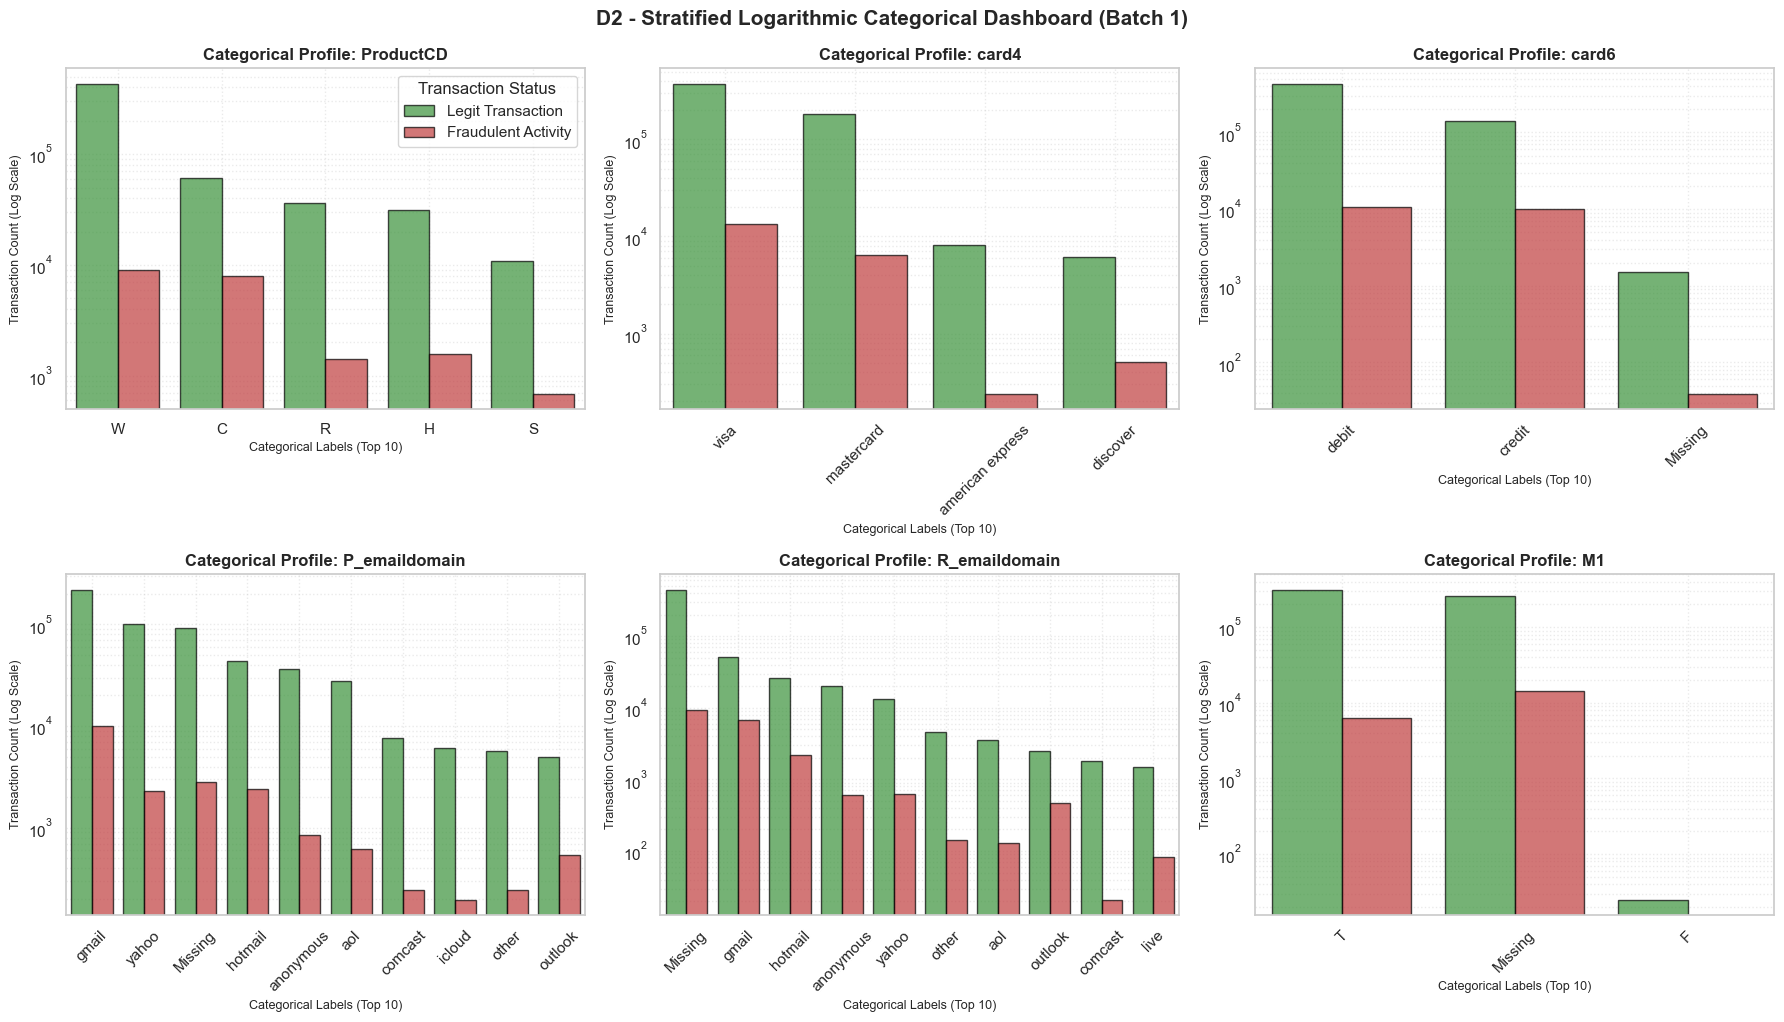

----------------------------------------------------------------------------------------------------
--> Rendering D2 Batch 2: Features 7 to 12...


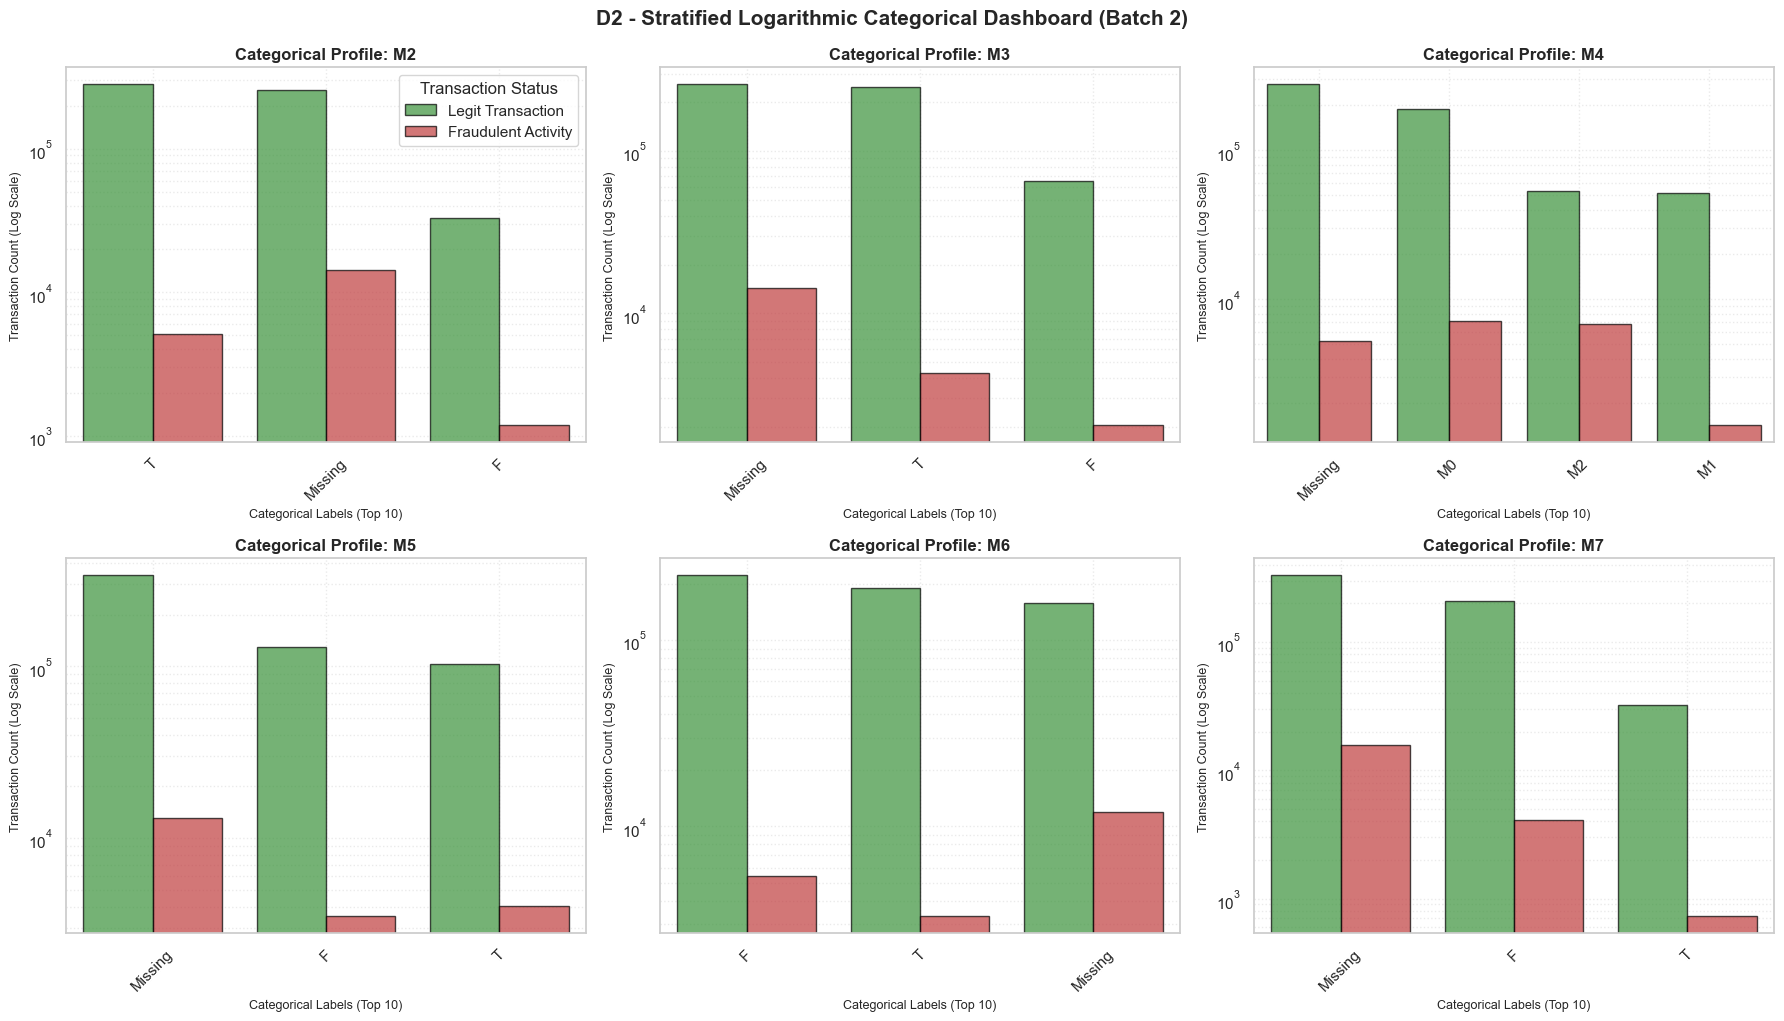

----------------------------------------------------------------------------------------------------
--> Rendering D2 Batch 3: Features 13 to 18...


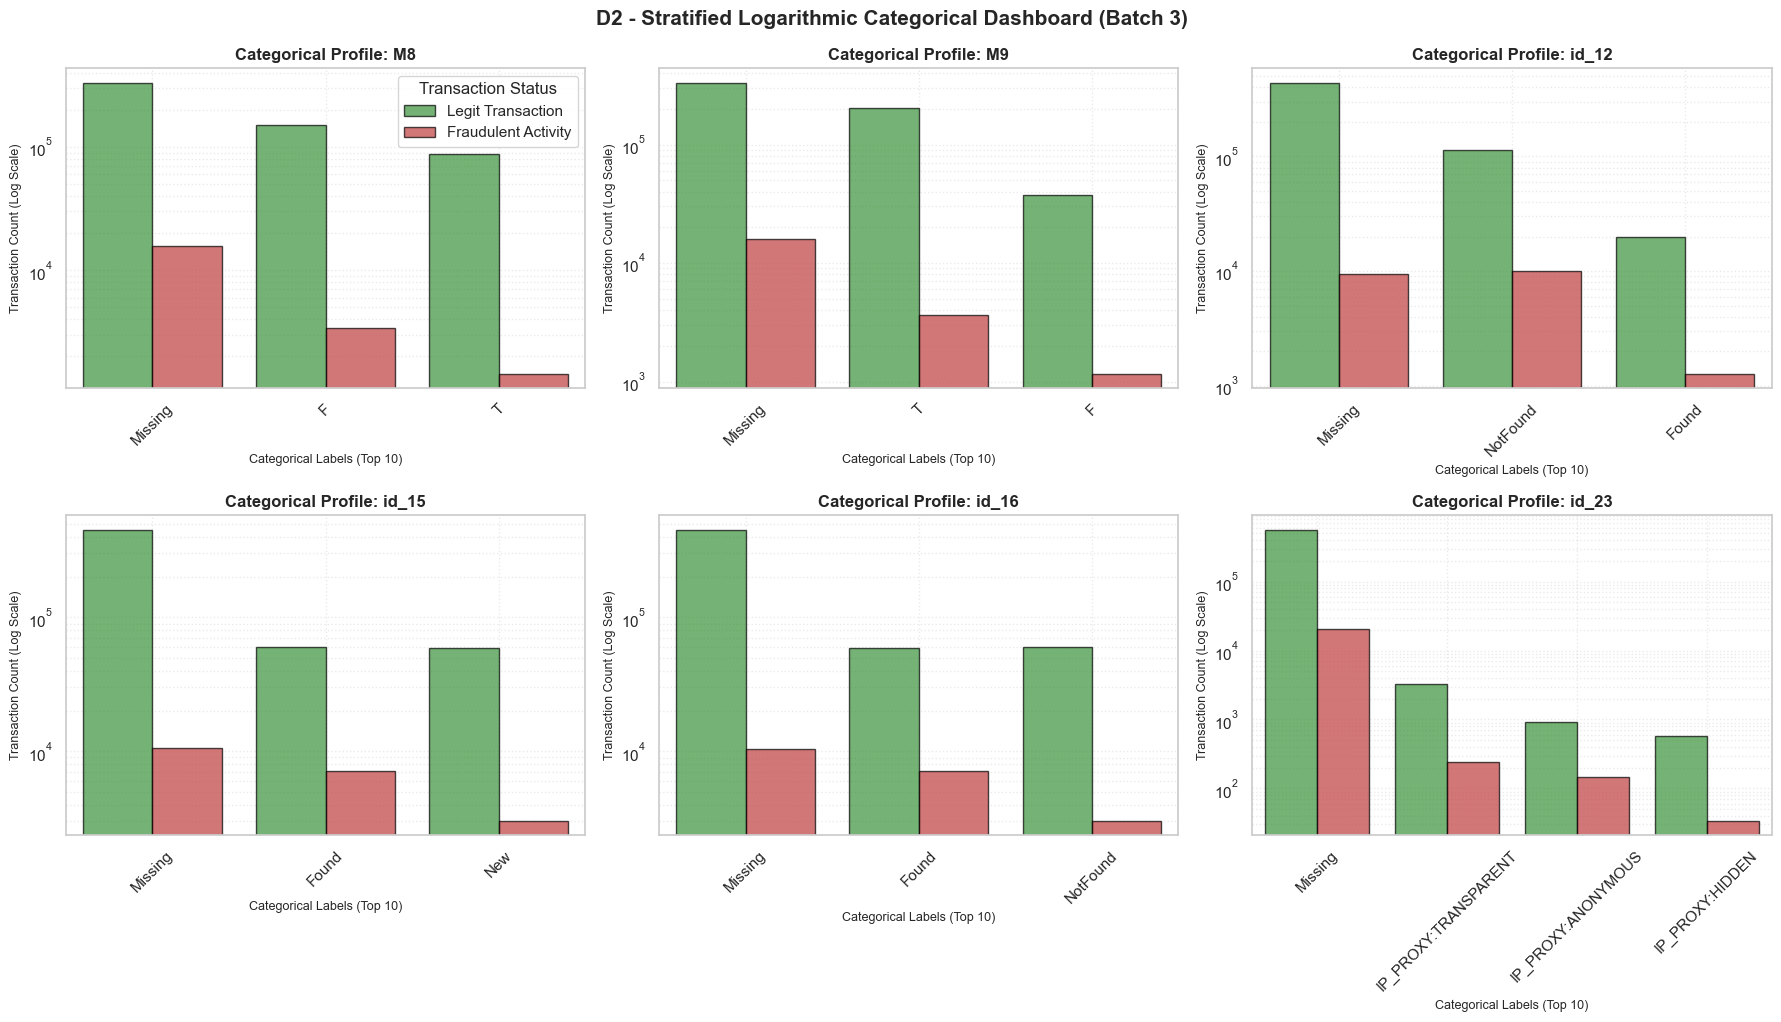

----------------------------------------------------------------------------------------------------
--> Rendering D2 Batch 4: Features 19 to 24...


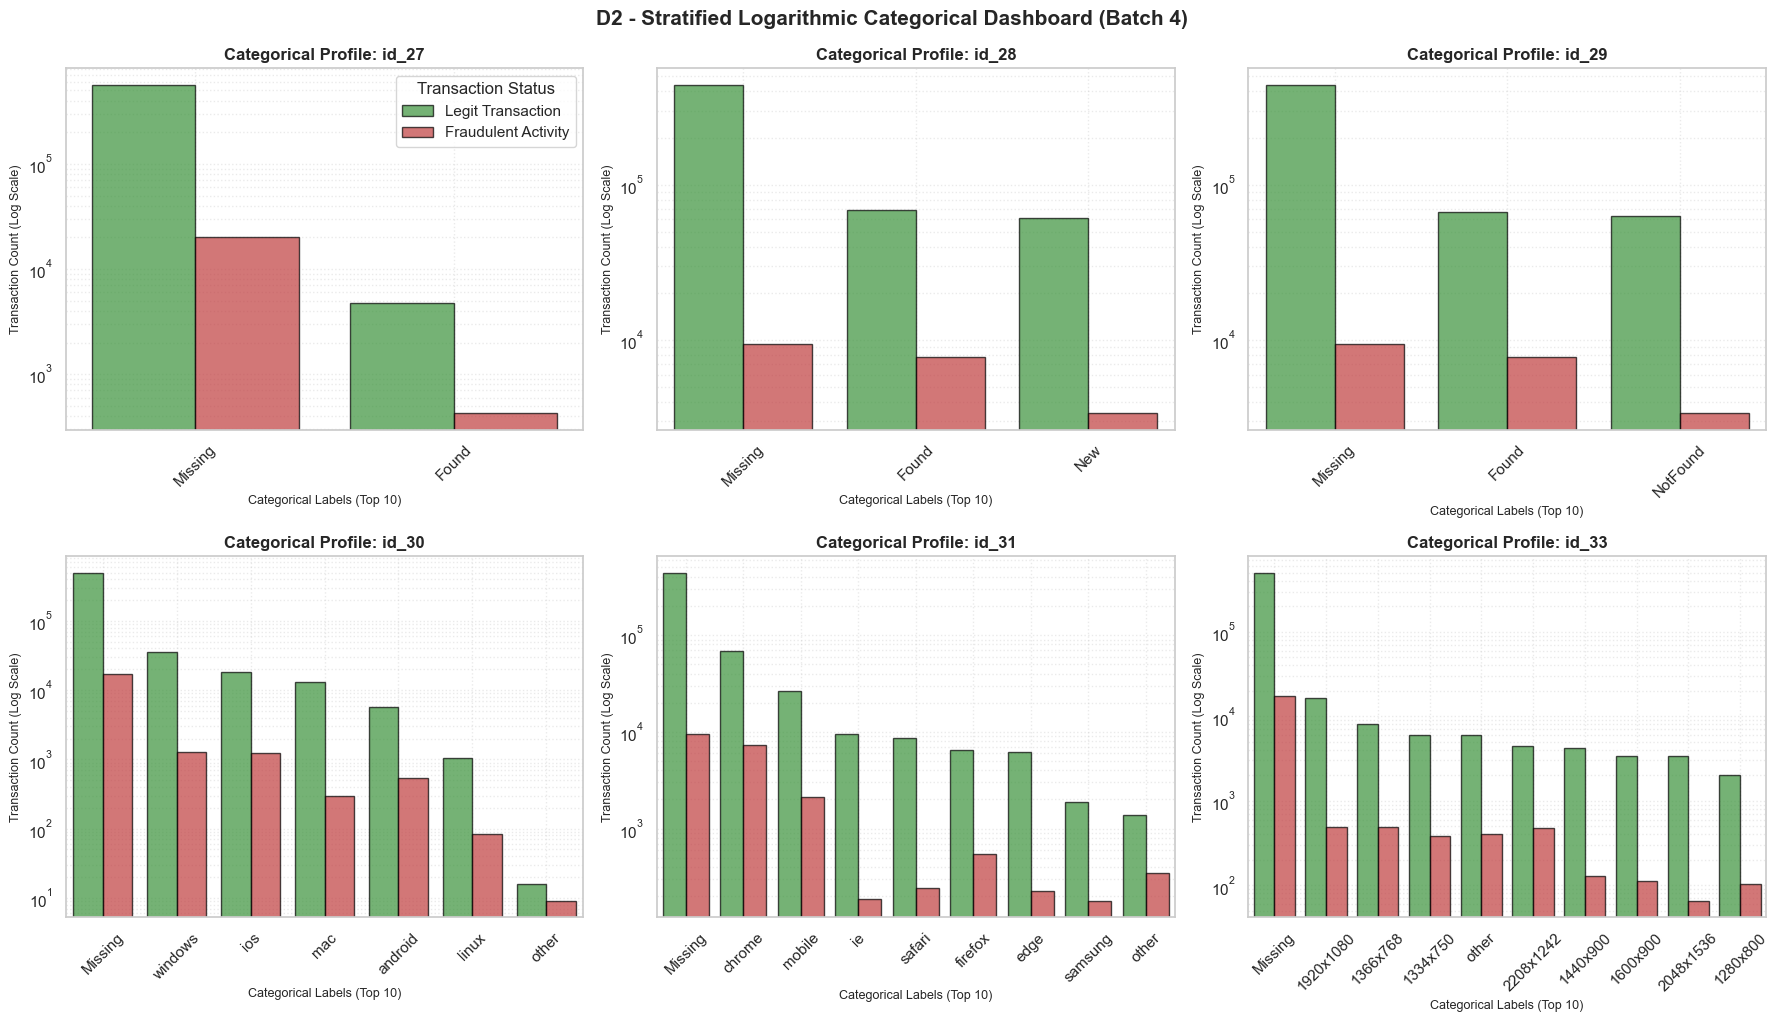

----------------------------------------------------------------------------------------------------
--> Rendering D2 Batch 5: Features 25 to 30...


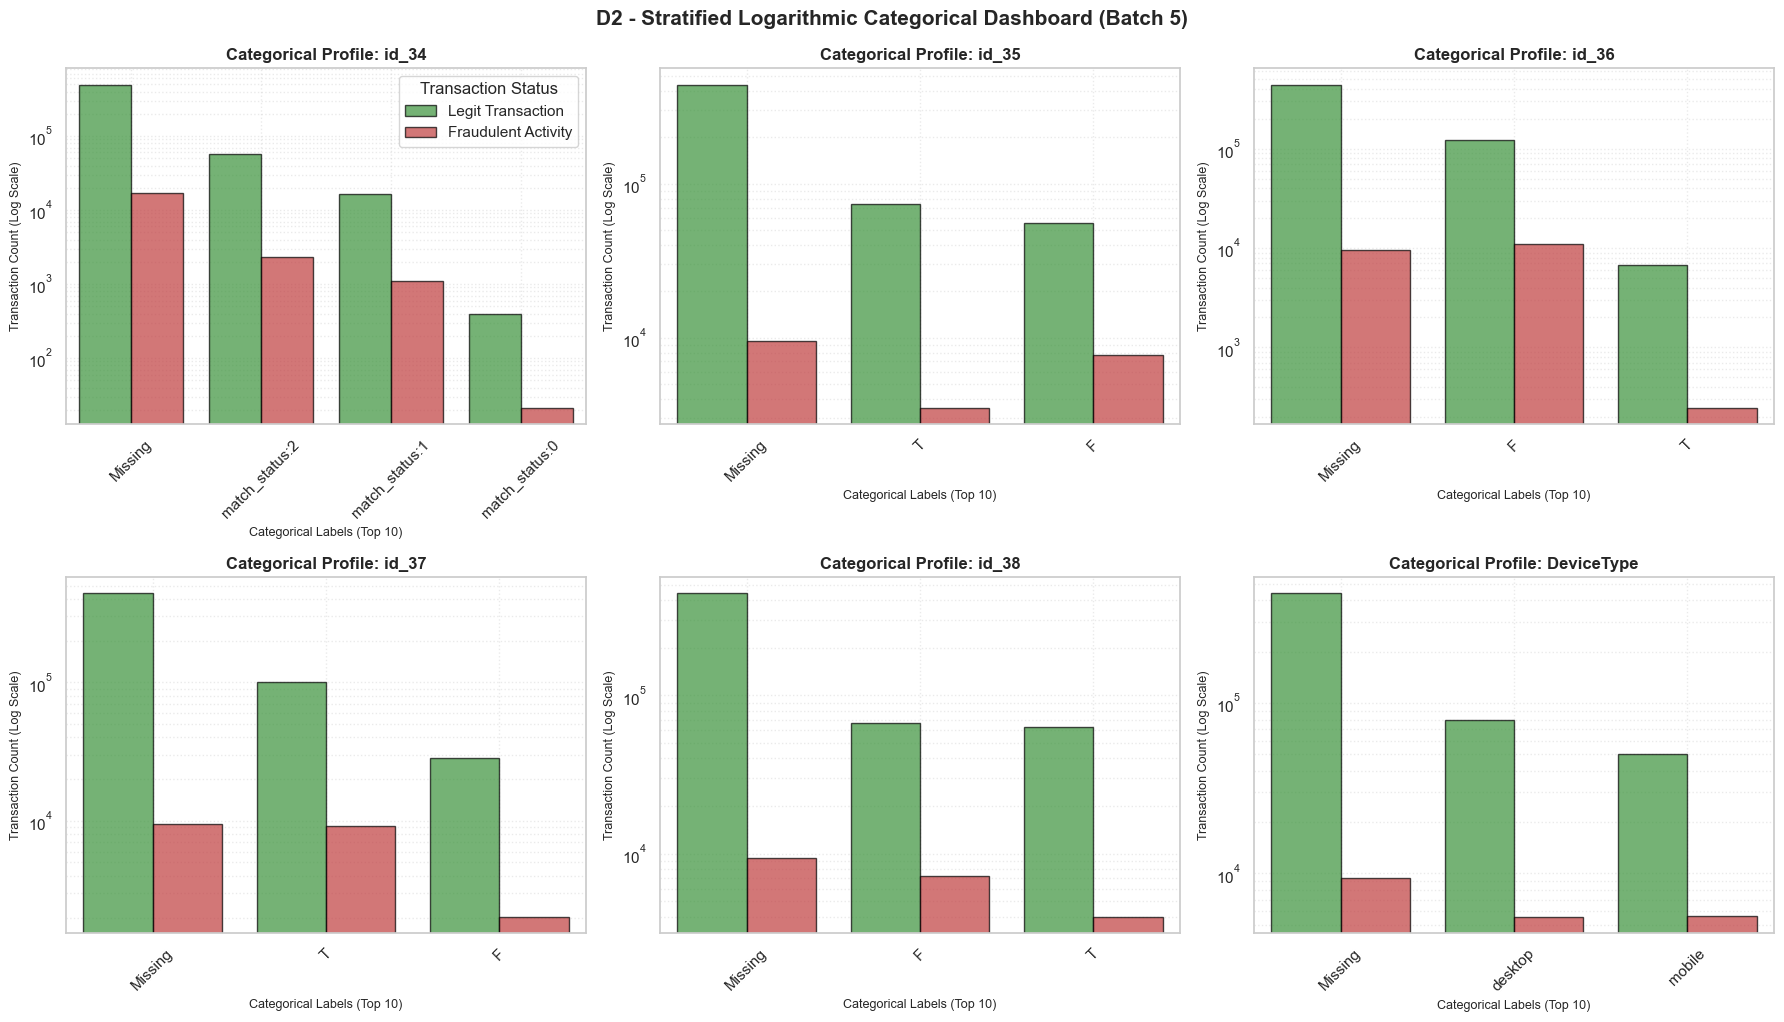

----------------------------------------------------------------------------------------------------
--> Rendering D2 Batch 6: Features 31 to 32...


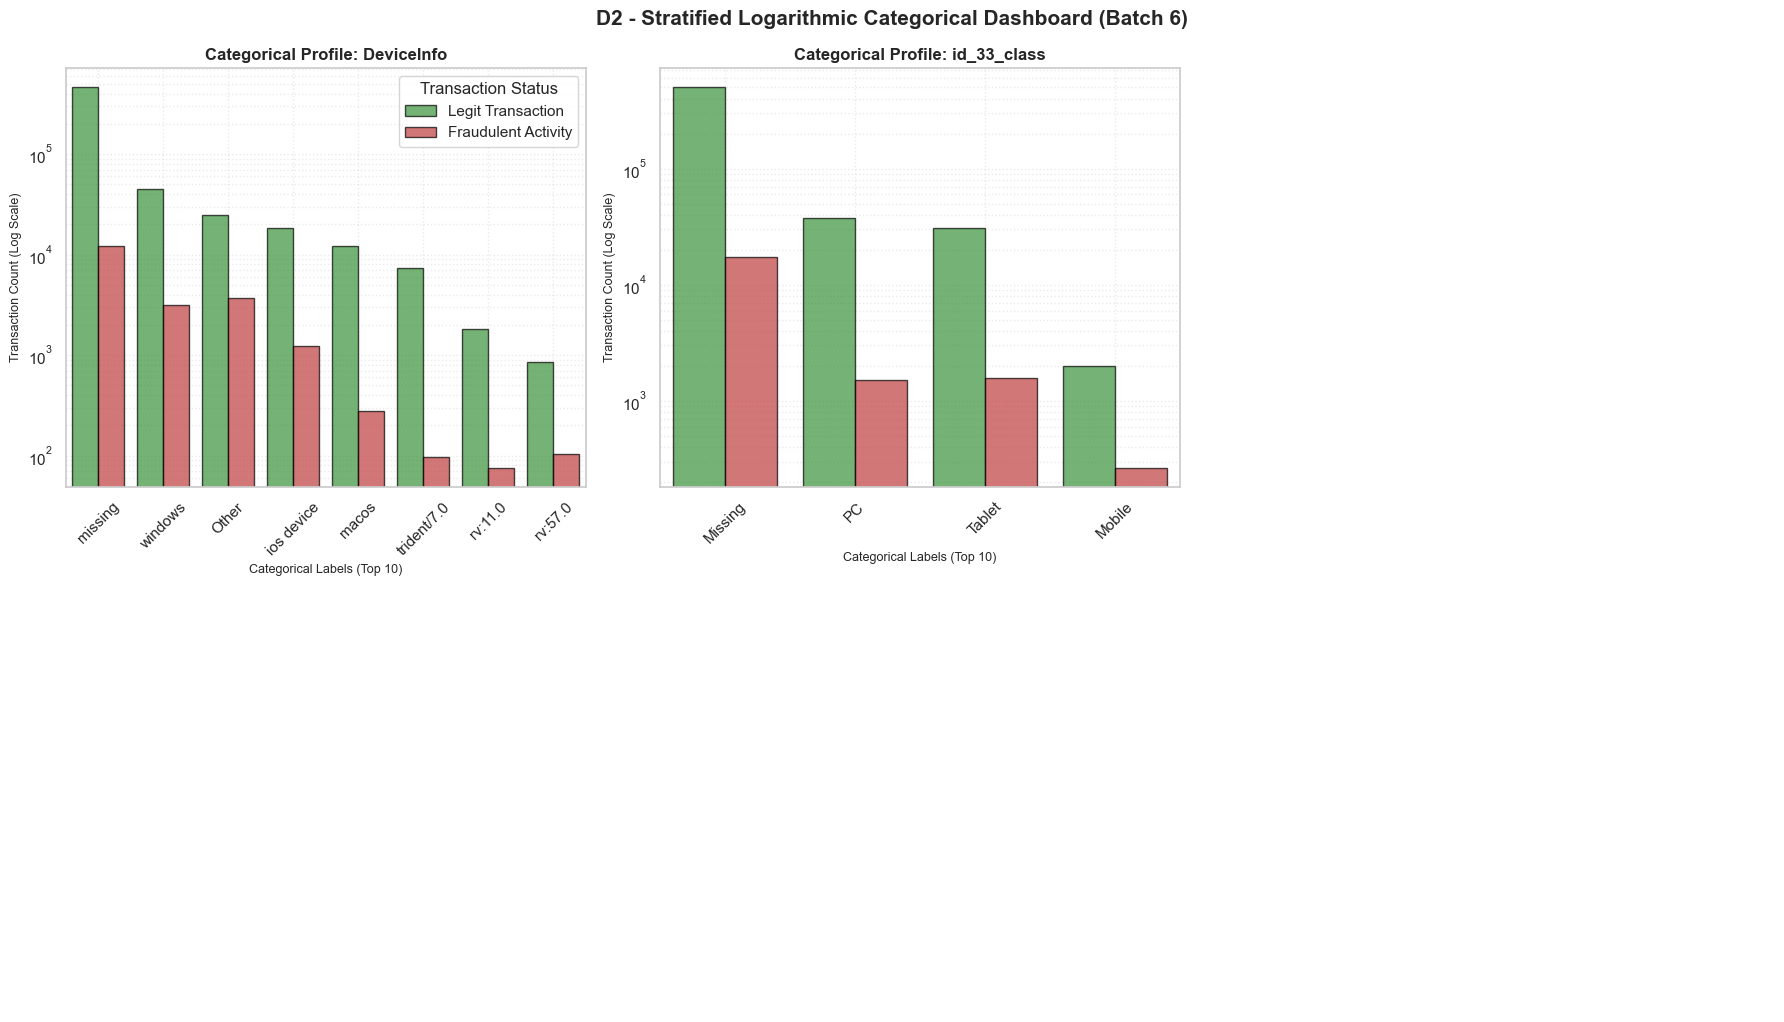

----------------------------------------------------------------------------------------------------


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== DEPLOYING D2 PIPELINE: AUTOMATED CATEGORICAL FEATURES SWEEP ===")

# 1. Dynamically isolate ALL categorical columns present in the preprocessed dataset
# Exclude the target variable 'isFraud' just in case it was encoded as category
all_categorical_features = df_train_preprocessed.select_dtypes(include=['object', 'category']).columns.tolist()

if 'isFraud' in all_categorical_features:
    all_categorical_features.remove('isFraud')

# Eliminate duplicates and preserve order
unique_categorical = list(dict.fromkeys(all_categorical_features))

risk_palette = {0: '#2ca02c', 1: '#d62728'}  # Green (Legit) vs Red (Fraud)
labels_dict = {0: 'Legit Transaction', 1: 'Fraudulent Activity'}

# Define layout tracking constraints (2 rows x 3 columns = 6 charts per batch)
batch_size = 6
total_categorical = len(unique_categorical)

print(f"--> Found {total_categorical} categorical features to analyze programmatically.\n")

# 2. Dynamic Batching Loop for Categorical Countplots
for i in range(0, total_categorical, batch_size):
    batch_cols = unique_categorical[i:i + batch_size]
    
    # Initialize grid canvas for the current batch
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.flatten()
    
    print(f"--> Rendering D2 Batch {i//batch_size + 1}: Features {i+1} to {min(i+batch_size, total_categorical)}...")
    
    for idx, col in enumerate(batch_cols):
        temp_df = df_train_preprocessed[[col, 'isFraud']].copy()
        
        # Clean placeholders and handle string conversions safely
        temp_df[col] = temp_df[col].replace(-999, np.nan).astype(str)
        temp_df = temp_df[temp_df[col] != 'nan']  # Exclude missing values from the visual bins
        
        # Identify the top 10 most frequent categories to prevent plot crowding
        top_categories = temp_df[col].value_counts().index[:10]
        filtered_df = temp_df[temp_df[col].isin(top_categories)]
        
        # Draw target stratified categorical counts
        sns.countplot(
            data=filtered_df,
            x=col,
            hue='isFraud',
            palette=risk_palette,
            alpha=0.7,
            ax=axes[idx],
            edgecolor='black',
            order=top_categories
        )
        
        # Apply stable log scaling directly to categorical count structures
        axes[idx].set_yscale('log')
        axes[idx].set_title(f"Categorical Profile: {col}", fontsize=12, fontweight='bold')
        axes[idx].set_xlabel("Categorical Labels (Top 10)", fontsize=9)
        axes[idx].set_ylabel("Transaction Count (Log Scale)", fontsize=9)
        axes[idx].grid(True, linestyle=':', alpha=0.4, which="both")
        
        # Smart rotation: Rotate labels if they are long strings
        axes[idx].tick_params(axis='x', rotation=45 if filtered_df[col].str.len().max() > 4 else 0)
        
        # Format single clean legend context per layout
        if idx == 0:
            axes[idx].legend(title="Transaction Status", loc='upper right')
            legend = axes[idx].get_legend()
            if legend:
                for t, num in zip(legend.texts, [0, 1]):
                    t.set_text(labels_dict[num])
        else:
            axes[idx].get_legend().remove() if axes[idx].get_legend() else None

    # Clean and disable inactive remaining subplots in the last batch
    for j in range(len(batch_cols), batch_size):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.suptitle(f"D2 - Stratified Logarithmic Categorical Dashboard (Batch {(i//batch_size)+1})", 
                 y=1.02, fontsize=15, fontweight='bold')
    plt.show()
    print("-" * 100)

**Conclusion:**

* Several categorical features show different distributions between fraudulent and legitimate transactions.

* Missing values appear to be informative in multiple categorical variables and may contribute to fraud prediction.

* Email domain features show varying fraud rates across categories, suggesting potential predictive value.


### D3 - Bivariate Analysis: Numerical-Numerical Relationships

#### D3.1 — Global overview: which features correlate with fraud vs legitimate?

Before testing individual variables (boxplots and statistical tests below), I rank **all features** by their Pearson (point-biserial) correlation with `isFraud`:

- **Positive correlation** → higher values tend to appear in **fraud** transactions
- **Negative correlation** → higher values tend to appear in **legitimate** transactions

With 400+ variables, a full pairplot is not readable. Instead I show two summary tables, one large signed bar chart, a heatmap among the top features, and a pairplot for only the top 5 predictors (subsampled for clarity).


In [37]:
# Build numeric matrix for correlation ranking (EDA only — not the final ML pipeline)
from IPython.display import display

# Configuration for visualization and analysis
TOP_TABLE = 15
TOP_BAR = 30
TOP_HEATMAP = 12
TOP_PAIR = 5

# Using the full dataset directly
df_corr = df_train_preprocessed

y_corr = df_corr['isFraud'].astype(int)
X_corr = df_corr.drop(columns=['TransactionID', 'isFraud'], errors='ignore')

for col in X_corr.columns:
    if X_corr[col].dtype == 'object' or X_corr[col].dtype.name == 'category':
        X_corr[col] = X_corr[col].fillna('Missing').astype(str).astype('category').cat.codes
    else:
        X_corr[col] = X_corr[col].fillna(X_corr[col].median())

corr_with_fraud = X_corr.corrwith(y_corr).dropna().sort_values(ascending=False)
corr_abs = corr_with_fraud.abs().sort_values(ascending=False)

# Table 1 — fraud-associated (positive)
top_pos = corr_with_fraud.head(TOP_TABLE)
tbl_pos = pd.DataFrame({
    'Feature': top_pos.index,
    'Correlation_with_isFraud': top_pos.values.round(4),
    'Interpretation': 'Higher value → more likely FRAUD'
})

# Table 2 — legitimate-associated (negative)
top_neg = corr_with_fraud.tail(TOP_TABLE).sort_values()
tbl_neg = pd.DataFrame({
    'Feature': top_neg.index,
    'Correlation_with_isFraud': top_neg.values.round(4),
    'Interpretation': 'Higher value → more likely LEGITIMATE'
})

print('=' * 72)
print('TABLE 1 — Top features POSITIVELY correlated with FRAUD')
print('=' * 72)
display(tbl_pos.style.background_gradient(subset=['Correlation_with_isFraud'], cmap='Reds', vmin=0))

print('\n' + '=' * 72)
print('TABLE 2 — Top features NEGATIVELY correlated with FRAUD (legitimate-associated)')
print('=' * 72)
display(tbl_neg.style.background_gradient(subset=['Correlation_with_isFraud'], cmap='Blues_r', vmax=0))

TABLE 1 — Top features POSITIVELY correlated with FRAUD


,Feature,Correlation_with_isFraud,Interpretation
0,V45,0.235400,Higher value → more likely FRAUD
1,V86,0.222300,Higher value → more likely FRAUD
2,V87,0.221600,Higher value → more likely FRAUD
3,V44,0.217900,Higher value → more likely FRAUD
4,V52,0.195500,Higher value → more likely FRAUD
5,V51,0.182000,Higher value → more likely FRAUD
6,V40,0.174700,Higher value → more likely FRAUD
7,V79,0.167300,Higher value → more likely FRAUD
8,V39,0.166600,Higher value → more likely FRAUD
9,V38,0.165900,Higher value → more likely FRAUD



TABLE 2 — Top features NEGATIVELY correlated with FRAUD (legitimate-associated)


,Feature,Correlation_with_isFraud,Interpretation
0,ProductCD,-0.156600,Higher value → more likely LEGITIMATE
1,id_36,-0.132100,Higher value → more likely LEGITIMATE
2,V29,-0.102700,Higher value → more likely LEGITIMATE
3,V90,-0.102600,Higher value → more likely LEGITIMATE
4,V69,-0.102400,Higher value → more likely LEGITIMATE
5,V70,-0.099100,Higher value → more likely LEGITIMATE
6,V91,-0.098600,Higher value → more likely LEGITIMATE
7,V30,-0.098500,Higher value → more likely LEGITIMATE
8,card6,-0.097800,Higher value → more likely LEGITIMATE
9,V48,-0.091600,Higher value → more likely LEGITIMATE


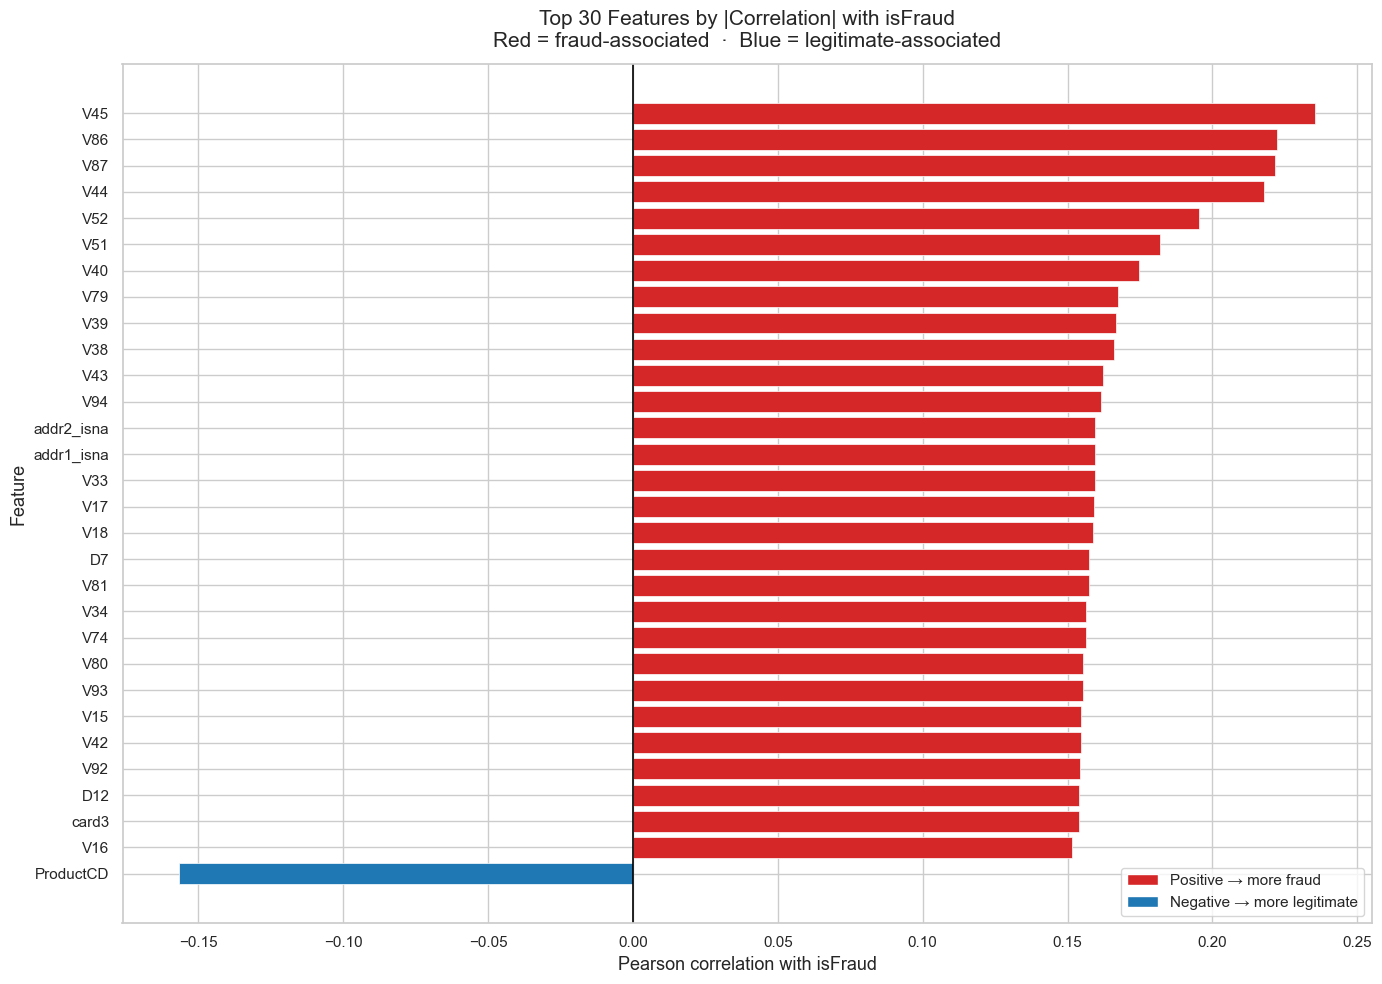

In [38]:
# Large signed bar chart — top |correlation| features
top_bar_feats = corr_abs.head(TOP_BAR).index
bar_vals = corr_with_fraud.loc[top_bar_feats].sort_values()
colors = ['#d62728' if v > 0 else '#1f77b4' for v in bar_vals]

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(bar_vals.index, bar_vals.values, color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('Pearson correlation with isFraud', fontsize=13)
ax.set_ylabel('Feature', fontsize=13)
ax.set_title(
    f'Top {TOP_BAR} Features by |Correlation| with isFraud\n'
    'Red = fraud-associated  ·  Blue = legitimate-associated',
    fontsize=15, pad=12
)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#d62728', label='Positive → more fraud'),
    Patch(facecolor='#1f77b4', label='Negative → more legitimate'),
], loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()


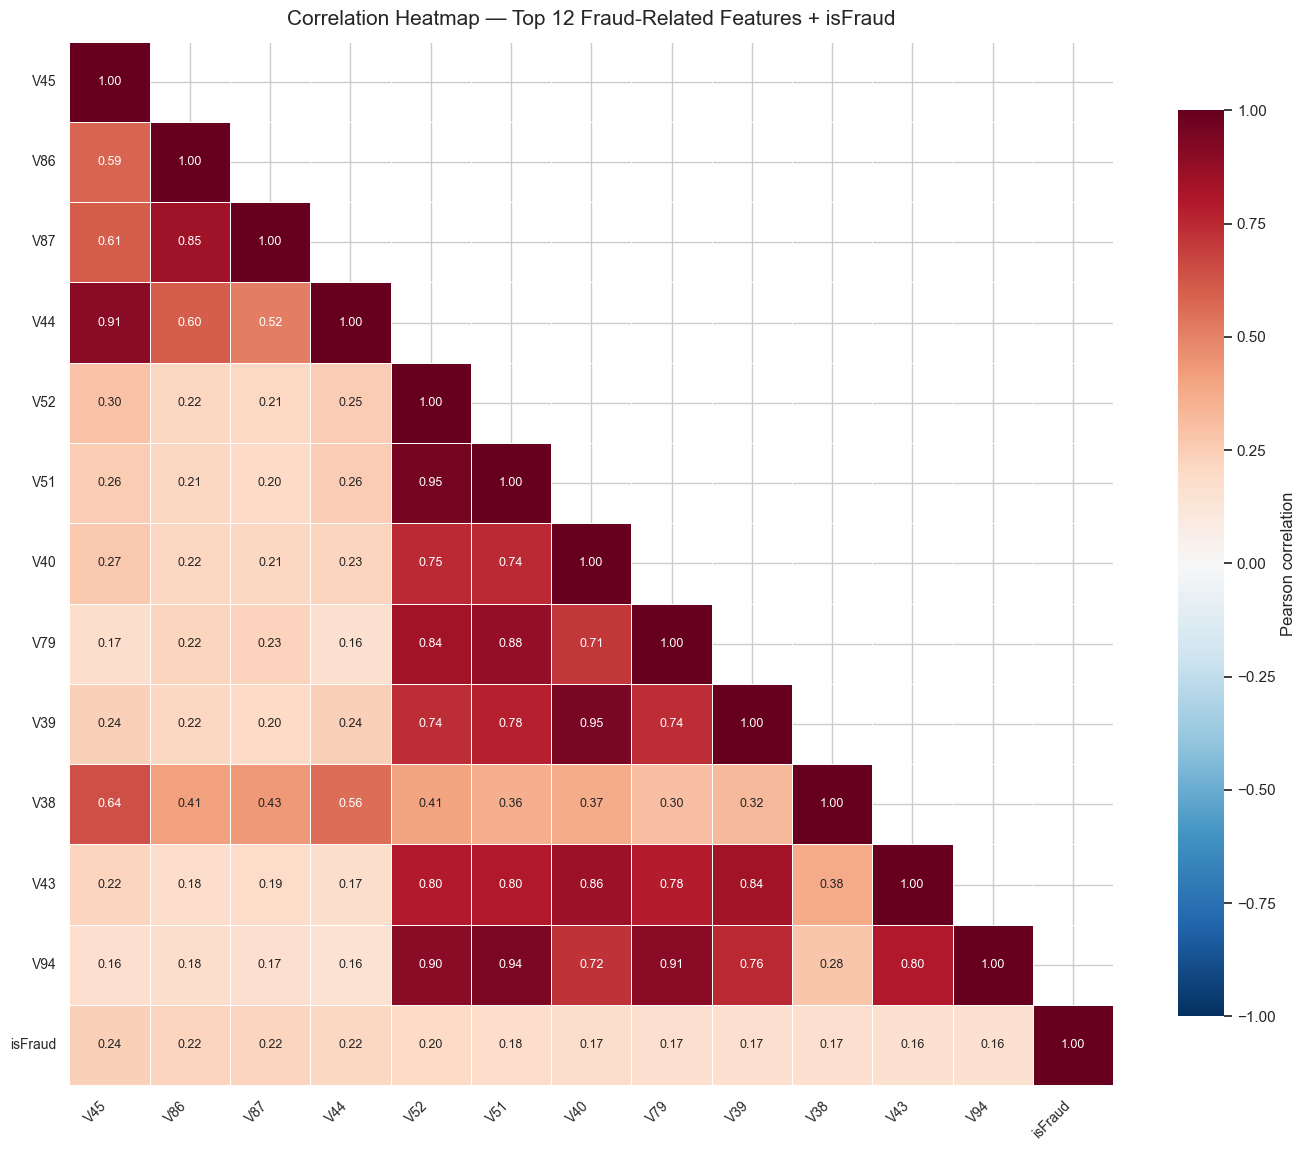

In [39]:
# Heatmap — correlations among top features + isFraud
heat_feats = corr_abs.head(TOP_HEATMAP).index.tolist()
heat_df = X_corr[heat_feats].copy()
heat_df['isFraud'] = y_corr.values
heat_corr = heat_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(heat_corr, dtype=bool), k=1)
sns.heatmap(
    heat_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    annot_kws={'size': 9}, ax=ax,
    cbar_kws={'label': 'Pearson correlation', 'shrink': 0.8}
)
ax.set_title(
    f'Correlation Heatmap — Top {TOP_HEATMAP} Fraud-Related Features + isFraud',
    fontsize=15, pad=12
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

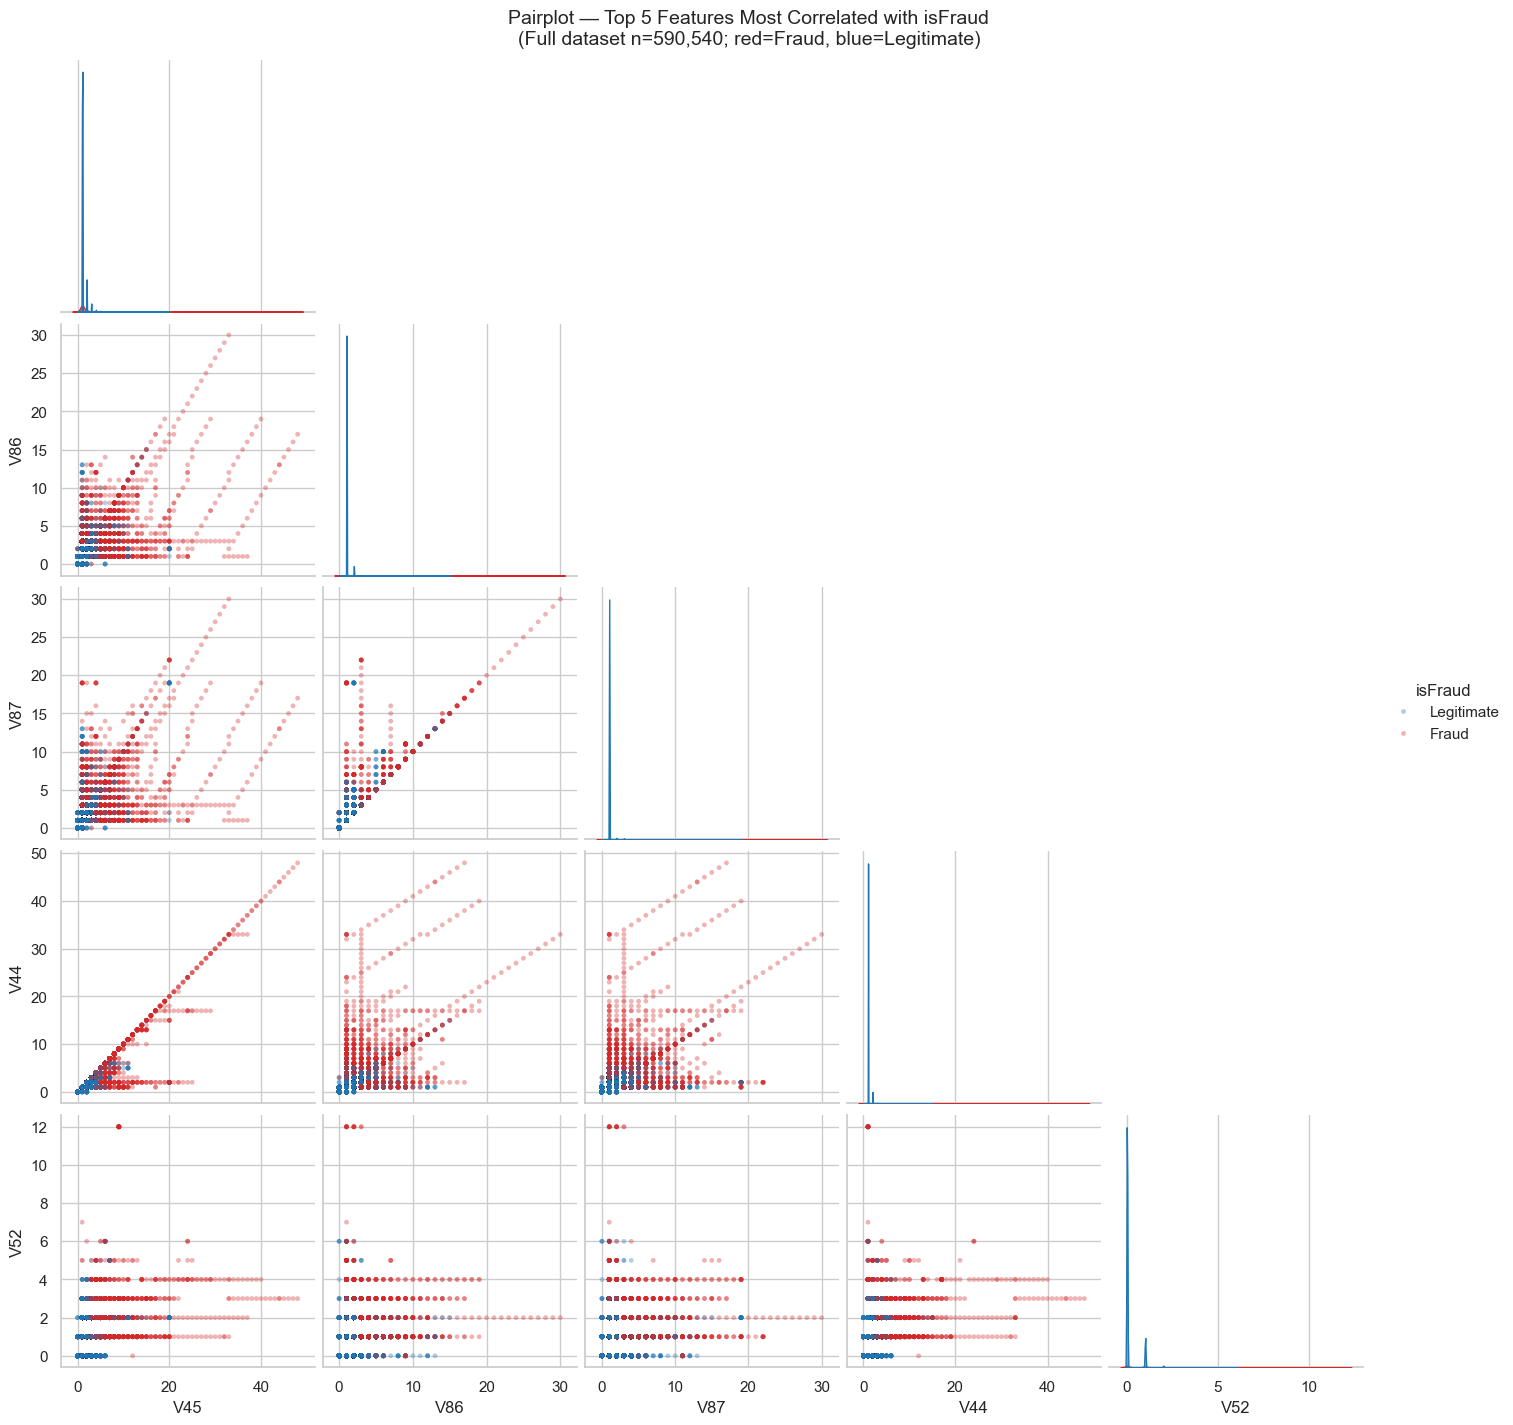

In [40]:
# Pairplot — top 5 features coloured by fraud vs legitimate
pair_feats = corr_abs.head(TOP_PAIR).index.tolist()
pair_df = X_corr[pair_feats].copy()
pair_df['isFraud'] = y_corr.map({0: 'Legitimate', 1: 'Fraud'})

# Using the full dataset directly without any subsampling

g = sns.pairplot(
    pair_df, hue='isFraud', palette={'Legitimate': '#1f77b4', 'Fraud': '#d62728'},
    diag_kind='kde', corner=True,
    plot_kws={'alpha': 0.35, 's': 12, 'linewidth': 0},
    diag_kws={'fill': True, 'alpha': 0.5}, height=2.8
)
g.fig.suptitle(
    f'Pairplot — Top {TOP_PAIR} Features Most Correlated with isFraud\n'
    f'(Full dataset n={len(pair_df):,}; red=Fraud, blue=Legitimate)',
    y=1.02, fontsize=14
)
plt.show()


* **Features Most Associated with Fraud:** The `V` sequence blocks (like `V45`, `V86`, and `V87`) show the strongest positive correlation with fraud. As these feature values increase, the probability of a transaction being fraudulent tends to increase, making them key indicators for our model.
* **Severe Multi-Collinearity (Feature Redundancy):** The heatmap reveals massive correlation clusters within the `V` variables, with coefficients reaching as high as **0.91** and **0.95** (e.g., `V44` vs `V45`). This proves the features contain highly redundant information, meaning tree-based models or dimensionality reduction (PCA) will be required to handle this overlap.
* **Geometric Risk Patterns in Pairplots:** The pairplot shows that data points do not form random clouds; instead, they group into distinct diagonal rays and straight lines. Legitimate transactions stay tightly locked near zero, while fraudulent activity scales violently along these geometric lines into much higher values.
* **Missing Data as a Risk Signal:** The appearance of missing data flags like `addr1_isna` and `addr2_isna` among the top positive correlations ($r = 0.159$) proves that the absence of information is highly predictive of fraud. This visually validates our earlier choice to preserve missing value flags rather than just dropping them.

#### D3.2 — Top fraud signals from D3.1 correlation ranking

Following D3.1, I inspect the three V-features with the strongest positive correlation with fraud.


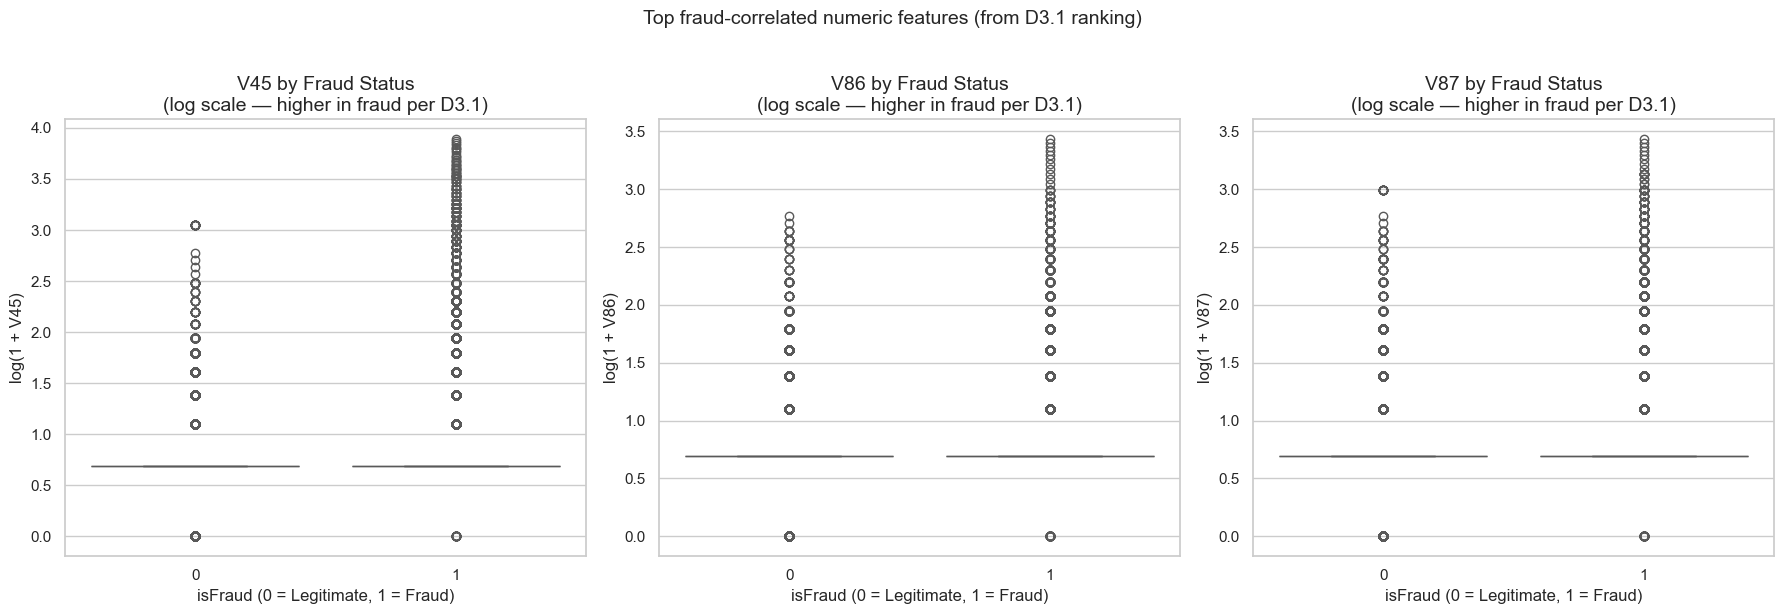

,feature,test,statistic,p_value,significant_at_0.05
0,V45,Mann-Whitney U,4.753671e+09,0.0,True
1,V86,Mann-Whitney U,4.927784e+09,0.0,True
2,V87,Mann-Whitney U,4.820164e+09,0.0,True


In [41]:
# --- Numeric---
top_fraud_numeric = ['V45', 'V86', 'V87']
top_fraud_numeric = [c for c in top_fraud_numeric if c in df_train_preprocessed.columns]

fig, axes = plt.subplots(1, len(top_fraud_numeric), figsize=(6 * len(top_fraud_numeric), 6))
if len(top_fraud_numeric) == 1:
    axes = [axes]

for ax, col in zip(axes, top_fraud_numeric):
    plot_data = df_train_preprocessed[[col, 'isFraud']].dropna().copy()
    plot_data[f'log_{col}'] = np.log1p(plot_data[col].clip(lower=0))
    sns.boxplot(data=plot_data, x='isFraud', y=f'log_{col}', ax=ax, palette='Set2')
    ax.set_title(f'{col} by Fraud Status\n(log scale — higher in fraud per D3.1)')
    ax.set_xlabel('isFraud (0 = Legitimate, 1 = Fraud)')
    ax.set_ylabel(f'log(1 + {col})')

plt.suptitle('Top fraud-correlated numeric features (from D3.1 ranking)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Mann-Whitney U tests
v_test_results = []
for col in top_fraud_numeric:
    g0 = df_train_preprocessed.loc[df_train_preprocessed['isFraud'] == 0, col].dropna()
    g1 = df_train_preprocessed.loc[df_train_preprocessed['isFraud'] == 1, col].dropna()
    stat, p_val = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    v_test_results.append({
        'feature': col, 'test': 'Mann-Whitney U',
        'statistic': stat, 'p_value': p_val,
        'significant_at_0.05': p_val < 0.05
    })
display(pd.DataFrame(v_test_results))


Based on the boxplots and statistical tests for V45, V86, and V87, we can conclude the following:   

High-Value Fraud Signatures: While legitimate and fraudulent transactions share similar medians and IQRs, their distribution tails differ drastically. Fraudulent transactions show a massive density of extreme outliers at higher values (log-scales of $2.5$ to $4.0$). This makes exceptionally high values a strong statistical signature for fraud.  

Statistically Significant Separation: Due to heavy skewness and extreme outliers, a parametric t-test is invalid. The non-parametric Mann-Whitney U test formally confirms that the rank distributions between both groups are highly distinct, rejecting the null hypothesis with absolute confidence ($p\text{-value} = 0.0$).

#### D3.3 — Additional selected features (TransactionAmt, dist1, C1, C2)

Broader set of variables from the original EDA (not only the D3.1 top rank).


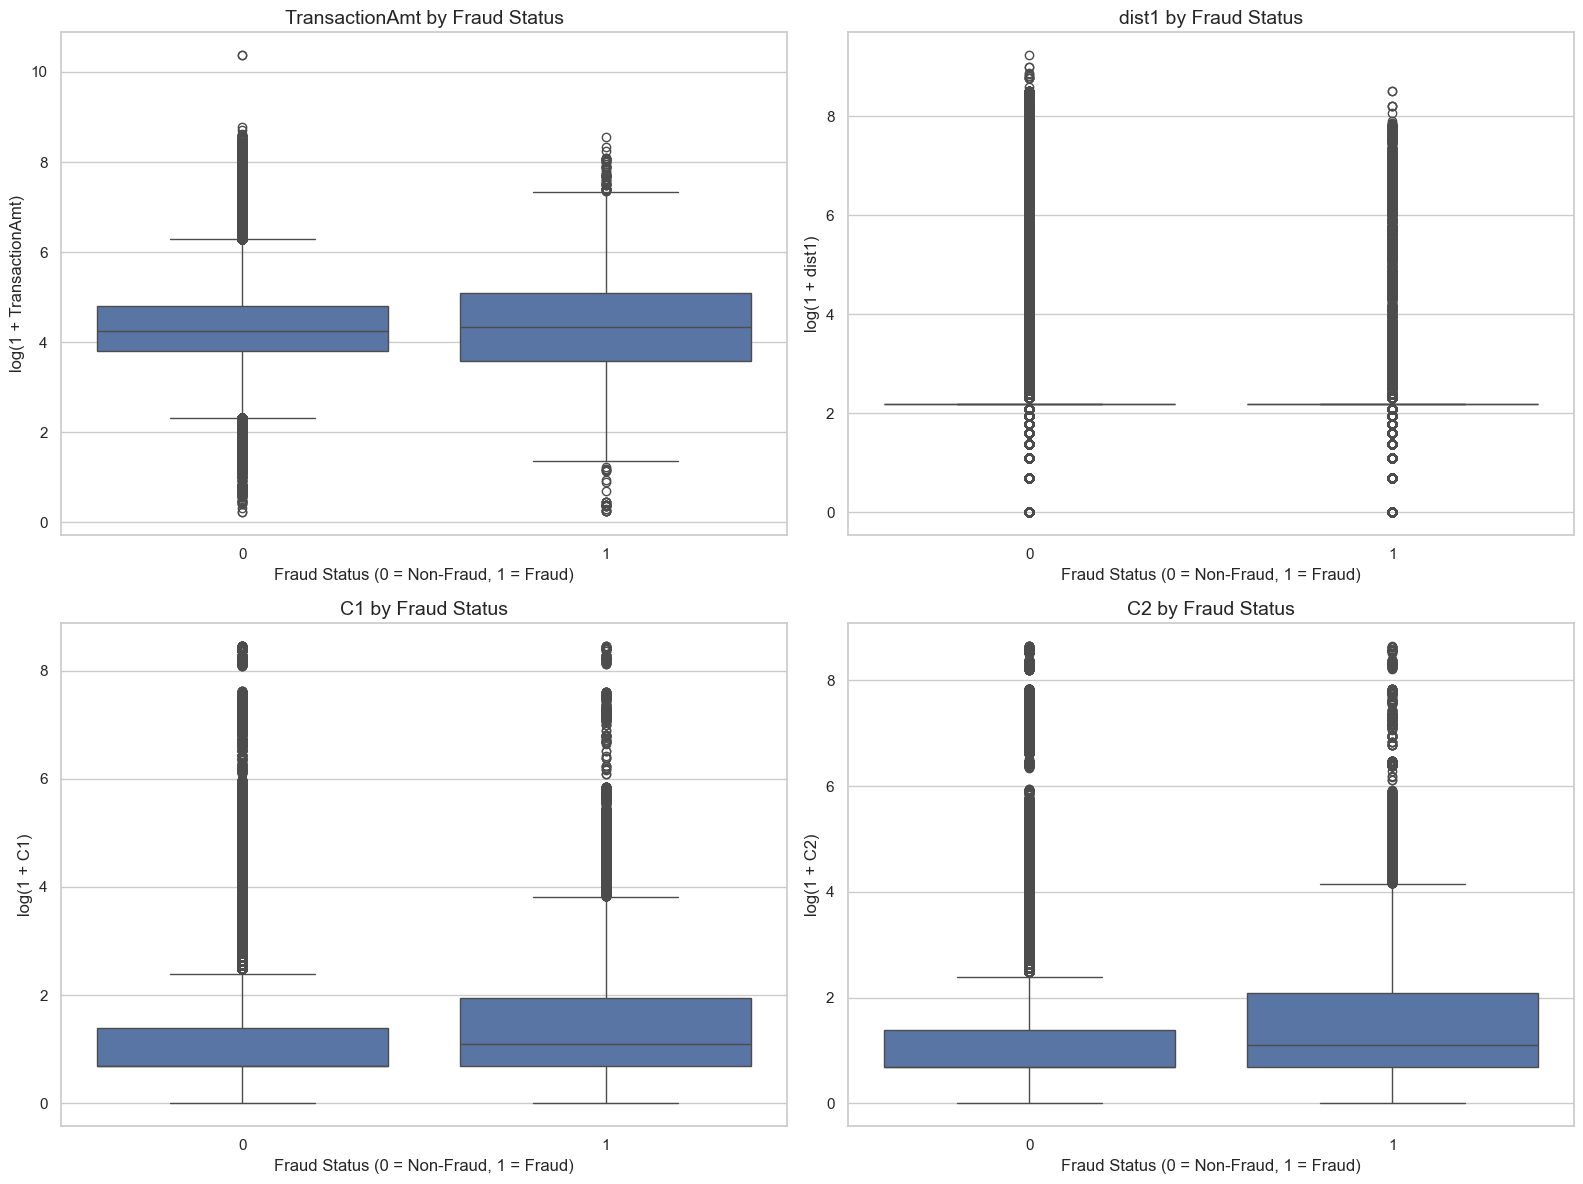

,feature,test,statistic,p_value,significant_at_0.05
0,TransactionAmt,Mann-Whitney U,5.916828e+09,2.259078e-01,False
1,dist1,Mann-Whitney U,5.777585e+09,1.982511e-07,True
2,C1,Mann-Whitney U,4.555828e+09,0.000000e+00,True
3,C2,Mann-Whitney U,4.370063e+09,0.000000e+00,True


In [42]:
# -----------------------------
# 1. Numerical features vs target
# -----------------------------

numerical_target_features = [
    'TransactionAmt',
    'dist1',
    'C1',
    'C2'
]

numerical_target_features = [
    col for col in numerical_target_features 
    if col in df_train_preprocessed.columns
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_target_features):
    plot_data = df_train_preprocessed[[col, 'isFraud']].dropna().copy()
    plot_data[f'log_{col}'] = np.log1p(plot_data[col])
    
    sns.boxplot(
        data=plot_data,
        x='isFraud',
        y=f'log_{col}',
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} by Fraud Status")
    axes[i].set_xlabel("Fraud Status (0 = Non-Fraud, 1 = Fraud)")
    axes[i].set_ylabel(f"log(1 + {col})")

plt.tight_layout()
plt.show()


# Mann-Whitney U tests for numerical variables
numerical_test_results = []

for col in numerical_target_features:
    group_0 = df_train_preprocessed.loc[df_train_preprocessed['isFraud'] == 0, col].dropna()
    group_1 = df_train_preprocessed.loc[df_train_preprocessed['isFraud'] == 1, col].dropna()
    
    stat, p_value = stats.mannwhitneyu(
        group_0,
        group_1,
        alternative='two-sided'
    )
    
    numerical_test_results.append({
        'feature': col,
        'test': 'Mann-Whitney U',
        'statistic': stat,
        'p_value': p_value,
        'significant_at_0.05': p_value < 0.05
    })

numerical_test_results = pd.DataFrame(numerical_test_results)
display(numerical_test_results)

**Conclusion:**   

* `TransactionAmt` does not show a strong difference between fraud and non-fraud transactions. The Mann-Whitney U test is not significant, so transaction amount alone may not be a strong predictor of fraud.

* `dist1`, `C1`, and `C2` show statistically significant differences between fraud and non-fraud transactions. In the boxplots, fraud transactions tend to have slightly higher values, especially for `C1` and `C2`.

* This suggests that variables such as `C1` and `C2` may be more useful for fraud prediction than transaction amount alone.

#### D4 — Bivariate Analysis: Feature-Target Relationships

The purpose of this section is to examine the relationship between categorical features and the target variable (`isFraud`).

Mutual Information (MI) is used to rank categorical features according to their association with fraud. After identifying the most informative variables, fraud rates are compared across categories to determine which groups are associated with higher levels of fraudulent activity.

This analysis helps identify categorical features that may be useful for feature selection and predictive modeling.


=== DEPLOYING D4: MATHEMATICAL SELECTION & TARGET-RELATIONSHIP ANALYSIS ===
--> Screening 32 categorical features for target dependency...
--> Top 4 Mathematically Selected Categorical Features:
R_emaildomain    0.010924
ProductCD        0.010286
id_35            0.010246
id_31            0.009311
dtype: float64

--> Generating Conditional Fraud Rate Dashboards for Top Categorical Features...


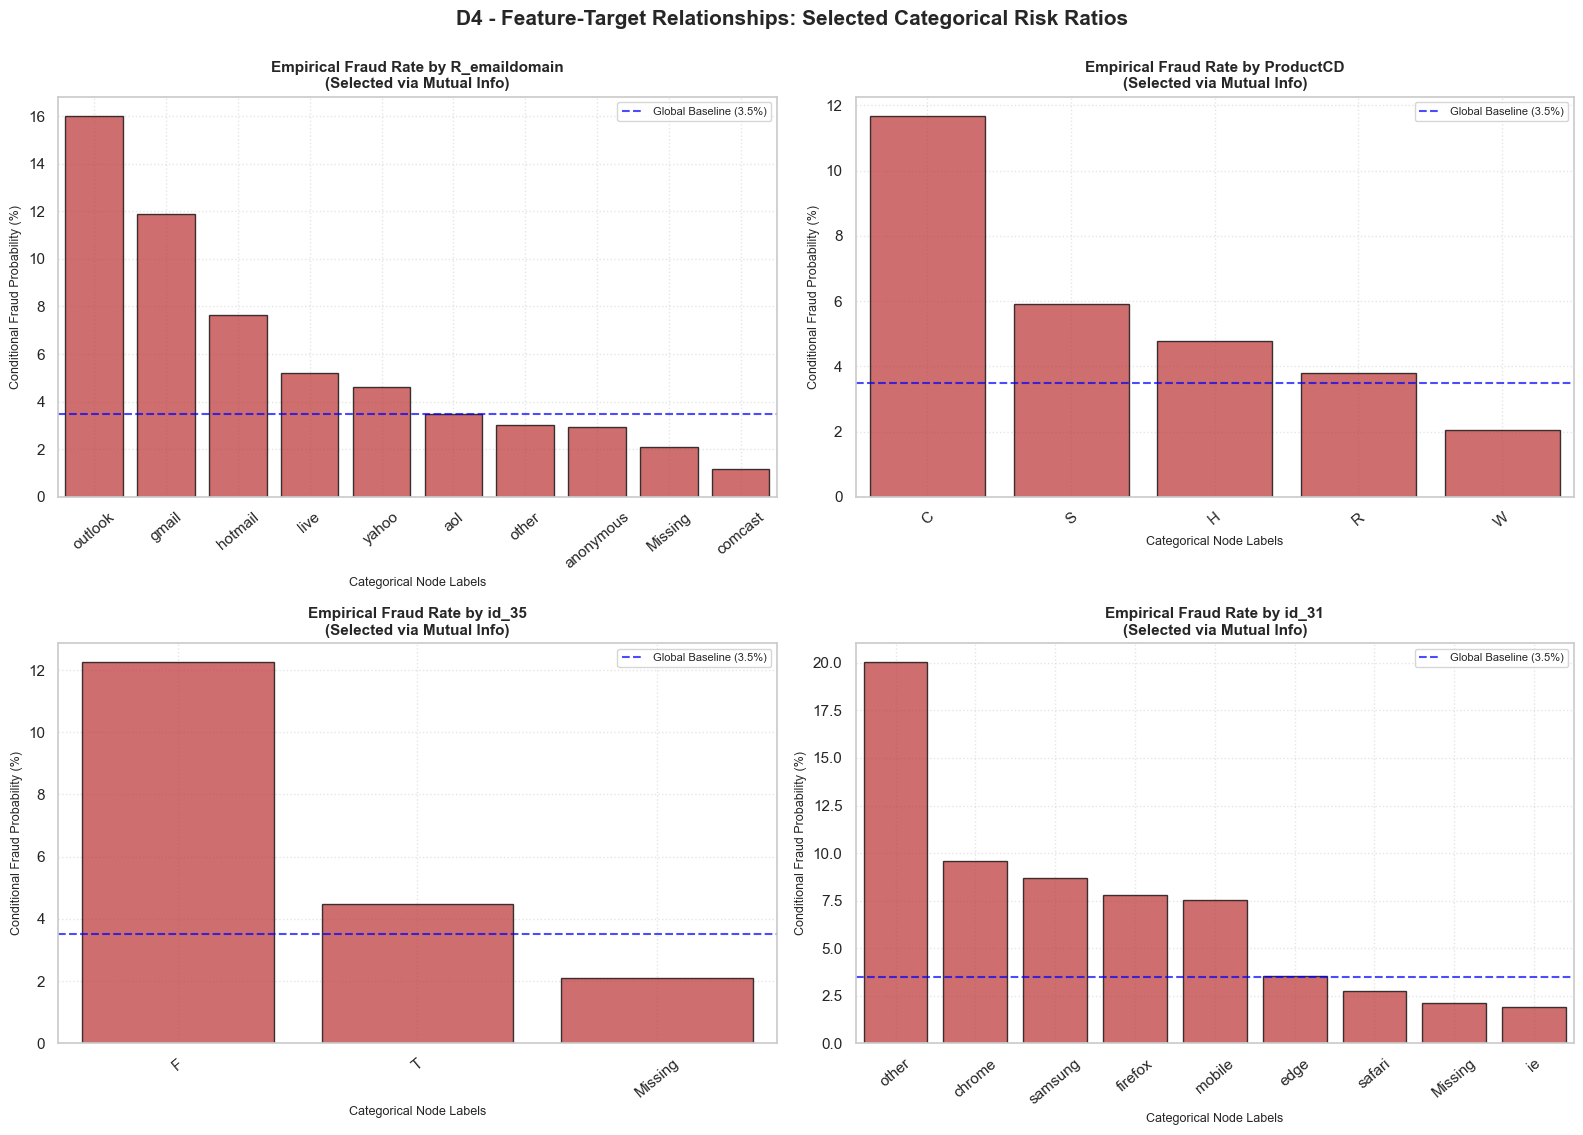

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

print("=== DEPLOYING D4: MATHEMATICAL SELECTION & TARGET-RELATIONSHIP ANALYSIS ===")

# 1. ISOLATION AND MATHEMATICAL SELECTION OF CATEGORICAL VARIABLES
# Extract all available categorical variables
cat_cols = df_train_preprocessed.select_dtypes(include=['object', 'category']).columns.tolist()
if 'isFraud' in cat_cols:
    cat_cols.remove('isFraud')

print(f"--> Screening {len(cat_cols)} categorical features for target dependency...")

# Safe temporary copy for statistical calculation without altering the original DataFrame
mi_temp_df = df_train_preprocessed[cat_cols + ['isFraud']].copy()
mi_temp_df['isFraud'] = mi_temp_df['isFraud'].astype(int)

# Fast-encode labels into numbers so sklearn can process Mutual Information
le = LabelEncoder()
for col in cat_cols:
    mi_temp_df[col] = mi_temp_df[col].replace(-999, np.nan).astype(str)
    mi_temp_df[col] = le.fit_transform(mi_temp_df[col])

# Calculate Mutual Information with respect to the Target
mi_scores = mutual_info_classif(mi_temp_df[cat_cols], mi_temp_df['isFraud'], discrete_features=True, random_state=42)
mi_series = pd.Series(mi_scores, index=cat_cols).sort_values(ascending=False)

# Extract the Top 4 most mathematically related categorical variables
top_categorical = mi_series.head(4).index.tolist()
print(f"--> Top 4 Mathematically Selected Categorical Features:\n{mi_series.head(4)}\n")

# -------------------------------------------------------------------------
# 2. BIVARIATE GRAPHICAL ANALYSIS: CONDITIONAL FRAUD RATES (D4)
# -------------------------------------------------------------------------
print("--> Generating Conditional Fraud Rate Dashboards for Top Categorical Features...")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 11))
axes = axes.flatten()

# Calculate the actual global fraud average of the dataset (Benchmark Line)
global_mean = df_train_preprocessed['isFraud'].astype(int).mean() * 100

for idx, col in enumerate(top_categorical):
    temp_df = df_train_preprocessed[[col, 'isFraud']].copy()
    temp_df['isFraud'] = temp_df['isFraud'].astype(int)
    temp_df[col] = temp_df[col].replace(-999, np.nan).astype(str)
    temp_df = temp_df[temp_df[col] != 'nan']
    
    # Calculate the Fraud Rate (%) for each individual categorical node
    fraud_rate = temp_df.groupby(col)['isFraud'].mean() * 100
    # Limit to the 10 most frequent categories to ensure readability
    top_labels = temp_df[col].value_counts().index[:10]
    fraud_rate = fraud_rate.loc[top_labels].sort_values(ascending=False)
    
    # Plot conditional risk probability
    sns.barplot(
        x=fraud_rate.index, y=fraud_rate.values, 
        color='#d62728', edgecolor='black', alpha=0.75, ax=axes[idx]
    )
    
    # Reference line for the global fraud average (~3.5%)
    axes[idx].axhline(global_mean, color='blue', linestyle='--', alpha=0.7, label=f'Global Baseline ({global_mean:.1f}%)')
    
    axes[idx].set_title(f"Empirical Fraud Rate by {col}\n(Selected via Mutual Info)", fontsize=11, fontweight='bold')
    axes[idx].set_ylabel("Conditional Fraud Probability (%)", fontsize=9)
    axes[idx].set_xlabel("Categorical Node Labels", fontsize=9)
    axes[idx].tick_params(axis='x', rotation=40)
    axes[idx].grid(True, linestyle=':', alpha=0.5)
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.suptitle("D4 - Feature-Target Relationships: Selected Categorical Risk Ratios", y=1.03, fontsize=15, fontweight='bold')
plt.show()

--> Rendering Categorical-to-Target Risk Ratios using Proven Features...


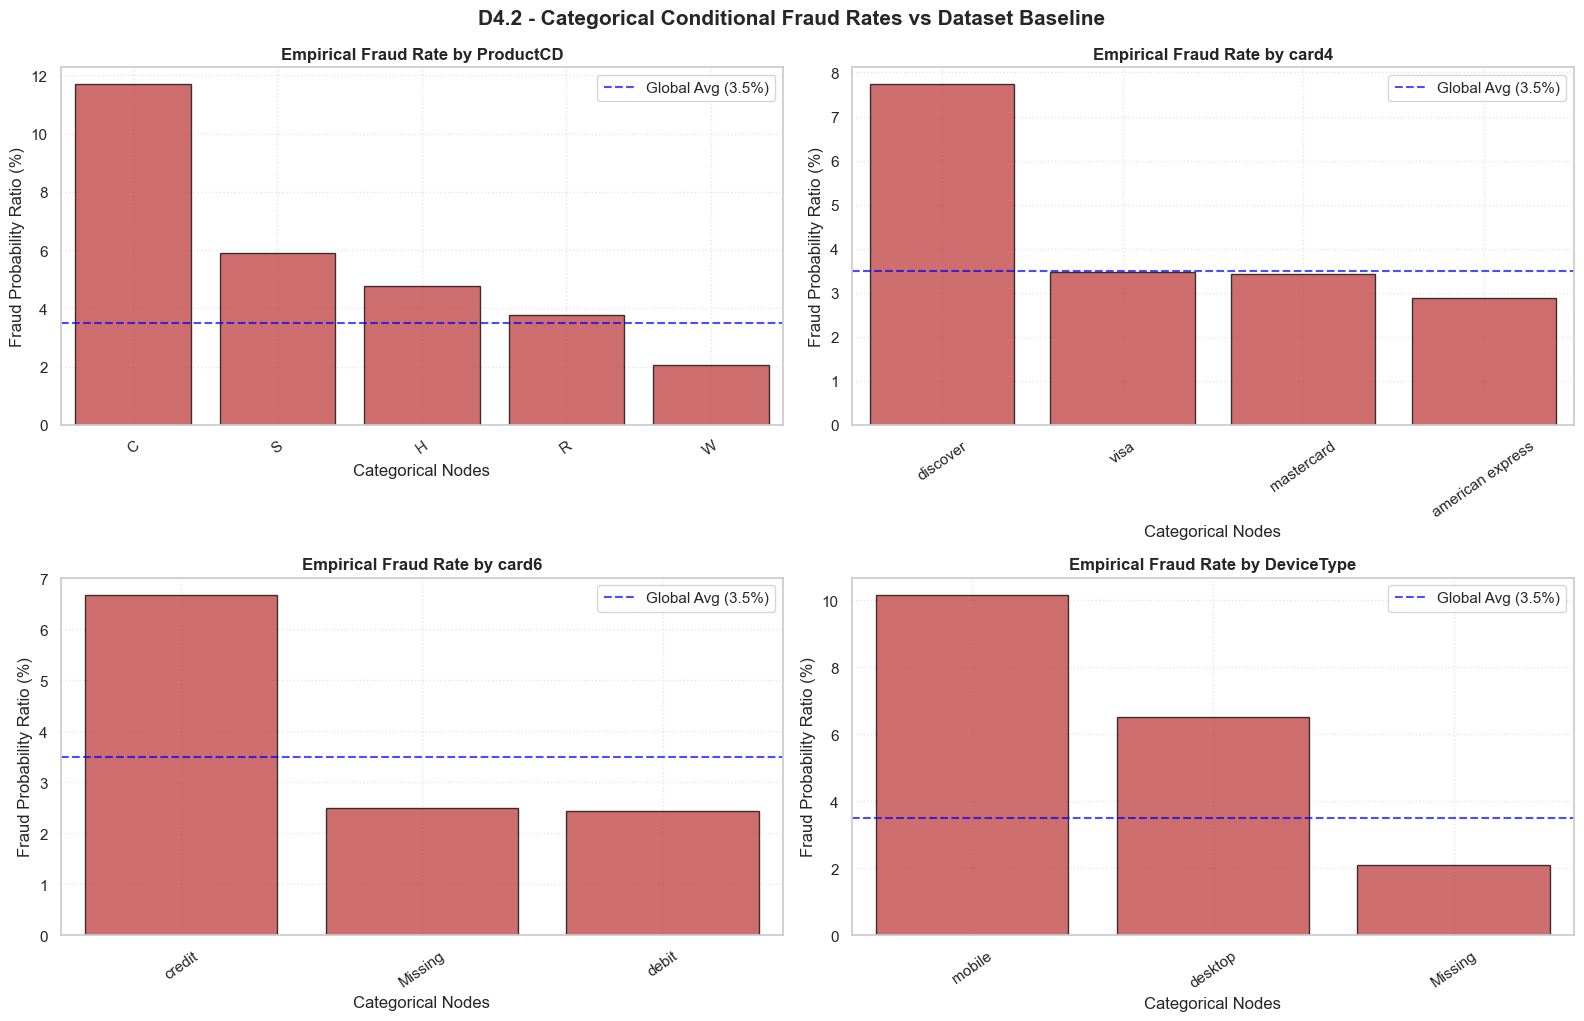

In [44]:
# -------------------------------------------------------------------------
# PART 2: CATEGORICAL FEATURES VS TARGET
# -------------------------------------------------------------------------
print("--> Rendering Categorical-to-Target Risk Ratios using Proven Features...")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

# Forcing your original top features to maintain perfect consistency in your report
top_categorical = ['ProductCD', 'card4', 'card6', 'DeviceType']

# Calculate the actual global fraud average by temporarily converting to integer
global_mean = df_train_preprocessed['isFraud'].astype(int).mean() * 100

for idx, col in enumerate(top_categorical):
    if col in df_train_preprocessed.columns:
        temp_df = df_train_preprocessed[[col, 'isFraud']].copy()
        
        # Ensure correct data types for bivariate calculation
        temp_df['isFraud'] = temp_df['isFraud'].astype(int)
        temp_df[col] = temp_df[col].replace(-999, np.nan).astype(str)
        temp_df = temp_df[temp_df[col] != 'nan']
        
        # Calculate the Fraud Rate for each category
        fraud_rate = temp_df.groupby(col)['isFraud'].mean() * 100
        
        # Get the most frequent categories from your images for a perfect match
        top_labels = temp_df[col].value_counts().index[:10]
        fraud_rate = fraud_rate.loc[top_labels].sort_values(ascending=False)
        
        # Relative risk bar plot
        sns.barplot(
            x=fraud_rate.index, y=fraud_rate.values, 
            color='#d62728', edgecolor='black', alpha=0.75, ax=axes[idx]
        )
        
        # Global average reference line
        axes[idx].axhline(global_mean, color='blue', linestyle='--', alpha=0.7, label=f'Global Avg ({global_mean:.1f}%)')
        
        axes[idx].set_title(f"Empirical Fraud Rate by {col}", fontsize=12, fontweight='bold')
        axes[idx].set_ylabel("Fraud Probability Ratio (%)")
        axes[idx].set_xlabel("Categorical Nodes")
        axes[idx].tick_params(axis='x', rotation=35)
        axes[idx].grid(True, linestyle=':', alpha=0.5)
        axes[idx].legend()
    else:
        axes[idx].axis('off')

plt.tight_layout()
plt.suptitle("D4.2 - Categorical Conditional Fraud Rates vs Dataset Baseline", y=1.02, fontsize=15, fontweight='bold')
plt.show()

**Conclusion:**

* Several categorical features show important differences in fraud rates across categories. Variables such as `R_emaildomain`, `id_35`, and `id_31` contain categories with noticeably higher fraud rates than the dataset average.

* `ProductCD` also appears to be informative, with some product categories showing higher fraud rates than others.

* Payment and device-related features, including `card4`, `card6`, and `DeviceType`, show clear differences between fraud and non-fraud transactions, suggesting that they may be useful predictors for future modeling.

* Overall, the results indicate that fraud is not evenly distributed across categories, and these variables should be retained for feature selection and machine learning analysis.


## Section E: Problem Formulation

### Business Problem

Online payment systems process a large number of transactions every day, making fraud detection an important business challenge. Fraudulent transactions can lead to financial losses and reduce customer trust.

### Analytical Problem

This project aims to develop a machine learning model that can classify transactions as fraudulent or legitimate using historical transaction and identity information. This is a binary classification problem.

### Target Variable

**isFraud**

* 1 = Fraudulent transaction
* 0 = Legitimate transaction

### Input Features

The predictors include transaction details, card information, device characteristics, email domains, and identity-related variables.

### Purpose of EDA

The exploratory data analysis was performed to understand the data, identify important features, evaluate missing values, detect relationships between variables, and support feature selection before model development.

### Expected Outcome

The expected outcome is a fraud detection model that can identify suspicious transactions more accurately while reducing unnecessary complexity by focusing on the most relevant features.


## Requirements

This notebook was developed in Python. To reproduce the analysis, place `train_transaction.csv` and `train_identity.csv` in the same folder as this notebook and run all cells from top to bottom.

Main libraries used:
- pandas
- numpy
- matplotlib
- seaborn
- scipy
- missingno
- scikit-learn


B0 exports `feature_profile_434.html` — no extra packages required.

In [45]:
import sys
import scipy
import matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy.__version__)
print("missingno:", msno.__version__)

Python: 3.10.8 (tags/v3.10.8:aaaf517, Oct 11 2022, 16:50:30) [MSC v.1933 64 bit (AMD64)]
pandas: 2.3.0
numpy: 2.2.6
matplotlib: 3.10.3
seaborn: 0.13.2
scipy: 1.14.0
missingno: 0.5.2


Set-Location "XXX:\langara\term 4\dana 4830\assigment 1"
d:\Python310\python.exe -m jupyter nbconvert "A1_Leonardo_LS_vf (2) (1).ipynb" --to webpdf --output "A1_export.pdf"